Compute mean connectivity from HCP7T dataset -- GP-EXCLUDED tractography

Copy of connectivity_statistics_gpexcl.ipynb that additionally defines a Visual cortex ROI group (occipital/calcarine regions already present in the 54-region atlas but excluded from the primary analysis) and adds it as a third section to the striatal schematic figure and the atlas surface render. The auditory-vs-prefrontal statistical tests (ANOVAs/posthocs) are unchanged -- visual is descriptive/visualization-only here. Outputs go to stats_exports/gpexcl_visual/ and figures/gpexcl_visual/ so they don't overwrite the primary gpexcl results.

In [128]:
import os

import numpy as np
import pandas as pd
import seaborn as sns
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from glob import glob

In [129]:
tian_scale = 'S2'

lut_fpath = os.path.join('/Users/dsj3886/data_local/derivatives/',
                         f'atlas-custom_subcort-tian{tian_scale}_cort-aud-vis-prefrontal',
                         f'atlas-custom_subcort-tian{tian_scale}_cort-aud-vis-prefrontal_lut.tsv')

region_list = list(pd.read_csv(lut_fpath, sep='\t', header=None).iloc[:,1])

In [130]:
# Data preparation (all cortical ROIs to keep) 
AUDITORY_ROIS   = ['STGa', 'PP', 'HG', 'PT', 'STGp']
PREFRONTAL_ROIS = ['OFC', 'ACC', 'FMC', 'IFGt', 'IFGo']
VISUAL_ROIS     = ['LOCsup', 'LOCinf', 'IntraCalc', 'TempOccFus', 'OccFus', 'SupraCalc', 'OccPole']
CORTEX_ROIS     = AUDITORY_ROIS + PREFRONTAL_ROIS + VISUAL_ROIS

# Display-only relabeling: the codes above stay unchanged (they must match the
# external atlas LUT / connectivity data); this is applied only when rendering
# text (plot titles, tick labels, annotations).
ROI_DISPLAY_NAMES = {'IFGo': 'ParsOp', 'IFGt': 'ParsTri'}

def _display_label(name):
    if len(name) > 2 and name[:2] in ('L-', 'R-'):
        return name[:2] + ROI_DISPLAY_NAMES.get(name[2:], name[2:])
    return ROI_DISPLAY_NAMES.get(name, name)


In [131]:
data_dir = os.path.join('/Users/dsj3886/data_local/derivatives/',
                        'HCP_7T_diffusion/msmt_csd_nthreads-1/')


STATS_OUT_DIR = 'stats_exports/gpexcl_visual'
os.makedirs(STATS_OUT_DIR, exist_ok=True)

FIGURES_DIR = 'figures/gpexcl_visual'
os.makedirs(FIGURES_DIR, exist_ok=True)

## Read in participant connectivity matrices

In [132]:
print(data_dir + 
      '/*/connectome_streamlines_alg-iFOD2_nsl-10mil_gpexcl/'+
                         'atlas-custom_subcort-tian{tian_scale}_cort-carpet_sift2-noscaling/'+
                         'streamlines_alg-iFOD2_nsl-10mil_gpexcl_connectome_sift2-noscaling.csv')

/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/msmt_csd_nthreads-1//*/connectome_streamlines_alg-iFOD2_nsl-10mil_gpexcl/atlas-custom_subcort-tian{tian_scale}_cort-carpet_sift2-noscaling/streamlines_alg-iFOD2_nsl-10mil_gpexcl_connectome_sift2-noscaling.csv


In [133]:
conn_files = sorted(glob(data_dir + 
                         '/*/connectome_streamlines_alg-iFOD2_nsl-10mil_gpexcl/'+
                         f'atlas-custom_subcort-tian{tian_scale}_cort-carpet_sift2-noscaling/'+
                         'streamlines_alg-iFOD2_nsl-10mil_gpexcl_connectome_sift2-noscaling.csv'))

# derive participant IDs directly from conn_files (preserves same order)
participants_with_files = sorted(list({os.path.basename(os.path.dirname(os.path.dirname(os.path.dirname(p)))) for p in conn_files}))


In [134]:
print(len(conn_files))

97


In [135]:
test_df = pd.read_csv(conn_files[0], header=None)
print(test_df)
print(len(test_df))


             0             1            2            3            4   \
0   7175.756660   3039.920731  2146.777231   791.937419    75.651302   
1   3039.920731   3517.668033   318.050253  1042.038547    76.801999   
2   2146.777231    318.050253  9058.712406  1473.946660    59.954868   
3    791.937419   1042.038547  1473.946660  3078.434948    37.495567   
4     75.651302     76.801999    59.954868    37.495567  9160.832638   
5     81.342204    203.286085    16.588406   113.384972  2754.908682   
6     16.137181      4.787414    33.060956    21.036424  3162.756287   
7     28.421462     28.708728    21.683033    40.068110   211.246920   
8     53.304725   3103.695341     3.657758    23.920431     0.434138   
9    499.525836   4327.192232    30.206676    40.103033    18.412725   
10   263.797747   1183.387257    17.327209    68.379030     0.000000   
11    10.781383    255.135920     2.239078     2.945604     0.000000   
12    83.951937    194.583416    10.260735    22.933959     0.00

In [136]:
num_regions = len(region_list)  # 54
conn_files_54 = [f for f in conn_files
                 if pd.read_csv(f, header=None).shape[0] == num_regions]

num_subjects = len(conn_files_54)
connmats_raw = np.zeros((num_subjects, num_regions, num_regions))
slcounts = np.zeros((num_regions, num_subjects))
list_df = []

for sx, matrix_fpath in enumerate(conn_files_54):
    sub_df = pd.read_csv(matrix_fpath, header=None)
    list_df.append(sub_df)
    connmats_raw[sx,:,:] = sub_df.to_numpy()
    slcounts[:,sx] = sub_df.to_numpy().sum(axis=0)

In [137]:
# --- Per-subject connectome normalisation ----------------------------------
# The connectome CSVs are RAW SIFT2-weighted streamline sums (tck2connectome
# run WITHOUT -scale_invnodevol). Each edge is normalised by:
#   (1) the subject's SIFT2 proportionality coefficient mu -> cross-subject scale
#   (2) the volume of the STRIATAL node only               -> connectivity density
#       C(striatum_i, cortex_j) = mu_s * raw_sum(i, j) / V_striatum(s, i)
# Striatal volumes come from each subject's own T1w/acpc-space parcellation
# (the same image passed to tck2connectome).

striatum_idx = np.array([i for i, r in enumerate(region_list)
                         if r.startswith(('aPUT', 'pPUT', 'aCAU', 'pCAU'))])

_subatlas_tmpl = ('/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/'
                  'atlas_space-sub/{sub}/sub-{sub}_'
                  f'atlas-custom_subcort-tian{tian_scale}_cort-carpet'
                  '_atlas_warp-standard2acpc_dc_space-T1w.nii.gz')
_mu_tmpl = ('/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/'
            'msmt_csd_nthreads-1/{sub}/'
            'sift2_mu_streamlines_alg-iFOD2_nsl-10mil_gpexcl.txt')

# subject IDs in the same order as connmats_raw (== conn_files_54)
subs_54 = [os.path.basename(os.path.dirname(os.path.dirname(os.path.dirname(f))))
           for f in conn_files_54]

mu = np.zeros(num_subjects)
striatal_vol_mm3 = np.zeros((num_subjects, num_regions))   # 0 outside striatum
for sx, sub in enumerate(subs_54):
    mu[sx] = float(np.loadtxt(_mu_tmpl.format(sub=sub)))
    seg_img = nib.load(_subatlas_tmpl.format(sub=sub))
    seg = np.asarray(seg_img.dataobj)
    vox_mm3 = float(np.prod(seg_img.header.get_zooms()[:3]))
    for idx in striatum_idx:
        striatal_vol_mm3[sx, idx] = np.count_nonzero(seg == idx + 1) * vox_mm3

print(f'mu: mean={mu.mean():.4g}  range=[{mu.min():.4g}, {mu.max():.4g}]')
print('striatal volume (mm^3), across-subject mean (SD):')
for idx in striatum_idx:
    v = striatal_vol_mm3[:, idx]
    print(f'  {region_list[idx]:9s} {v.mean():8.1f} ({v.std():6.1f})')

_sv = striatal_vol_mm3[:, striatum_idx]
if (_sv == 0).any():
    print(f'WARNING: {(_sv == 0).sum()} zero striatal volume(s) -> those edges = nan')

# scale the whole matrix by mu; divide the striatal ROWS by their own volume
inv_vol = np.ones((num_subjects, num_regions))
with np.errstate(divide='ignore'):
    inv_vol[:, striatum_idx] = np.where(_sv > 0, 1.0 / _sv, np.nan)

#connmats_corrected = connmats_raw * mu[:, None, None] * inv_vol[:, :, None]
# add a normalizing constant to get values (already a.u.) into less small decimals
connmats_corrected = 1e4 * connmats_raw * mu[:, None, None] * inv_vol[:, :, None]



mu: mean=0.001103  range=[0.0007979, 0.001508]
striatal volume (mm^3), across-subject mean (SD):
  aPUT-lh     2350.7 ( 329.3)
  pPUT-lh     2375.4 ( 291.7)
  aCAU-lh     1514.3 ( 287.1)
  pCAU-lh      845.9 ( 130.6)
  aPUT-rh     2352.1 ( 310.4)
  pPUT-rh     2659.9 ( 306.0)
  aCAU-rh     1546.5 ( 292.1)
  pCAU-rh      809.9 ( 160.8)


In [138]:
# Drop subjects with a zero-volume striatal ROI. A zero volume makes that
# subject's connectivity NaN for that ROI (cell above); AnovaRM aggregates
# cells with np.mean, which does NOT skip NaN, so a single bad cell corrupts
# that subject's entire design row (LinAlgError: SVD did not converge).
_bad = np.where((_sv == 0).any(axis=1))[0]
if len(_bad):
    _bad_subs = [subs_54[i] for i in _bad]
    print(f'Dropping {len(_bad)} subject(s) with a zero-volume striatal ROI: {_bad_subs}')
    _keep = np.array([i for i in range(num_subjects) if i not in set(_bad)])
    connmats_corrected = connmats_corrected[_keep]
    subs_54 = [subs_54[i] for i in _keep]
    mu = mu[_keep]
    striatal_vol_mm3 = striatal_vol_mm3[_keep]
    num_subjects = len(subs_54)

connmats = connmats_corrected


In [139]:
np.shape(connmats)

(97, 54, 54)

In [140]:
# check the streamline count matrix (region x subject)
slcounts

array([[ 40029.70509416,  34997.34523459,  36256.39572058, ...,
         34166.53988931,  36348.13303077,  41965.47954726],
       [ 56974.60217467,  47192.82984218,  51140.24893579, ...,
         48003.23289917,  52710.43852307,  59564.95874248],
       [ 25256.73414651,  17241.21436892,  14658.40930684, ...,
         15194.10148886,  29872.24516343,  19301.4289421 ],
       ...,
       [118656.76335813, 121735.48470521,  77857.1980543 , ...,
         78305.2629562 ,  98211.10245056,  99983.70815769],
       [ 14912.81012818,  20331.29854175,  27709.67436185, ...,
         11745.55894697,  15778.63843593,  10119.53702343],
       [179905.39642803, 126069.28356293, 128681.70265761, ...,
         96701.48571259,  73687.93375526, 106833.73973799]])

In [141]:
slcounts[0,:]

array([40029.70509416, 34997.34523459, 36256.39572058, 41319.52630202,
       36136.48809066, 31456.88381429, 34525.48017816, 35082.95639182,
       30997.7873434 , 47742.74726926, 35460.69864535, 51635.33605024,
       27717.1259812 , 38930.03632367, 27555.74363931, 40370.51218146,
       37222.81479979, 38425.93524742, 21010.03301759, 40046.57864131,
       37239.32240544, 40532.3510487 , 34924.07719615, 35741.92525806,
       36424.98123886, 44636.06141155, 41302.29894438, 45142.28935586,
       39602.55092326, 31460.18550265, 43381.22407961, 29231.74143499,
       26172.63813172, 22591.09191659, 36617.35191958, 36751.82159844,
       27590.15542585, 32212.7328312 , 33555.22562417, 40652.01692686,
       34425.96288115, 31464.05669959, 41333.97360277, 30903.64896308,
       31261.29126316, 35975.13076378, 25503.27356461, 42117.41474493,
       36103.70229146, 39600.78447938, 49688.43076626, 29214.65016972,
       25422.5688189 , 40888.69819112, 45112.17226383, 25610.96546365,
      

## Compute mean streamline count per ROI

In [142]:
# compute the mean streamline count per IC subdivision
mean_slcount = slcounts.mean(axis=1)
print(mean_slcount)
print(mean_slcount.shape)

[ 35642.79382013  51957.1847158   21150.29042565  18111.61905939
  29749.47200948  59755.89403349  17769.53235505  18574.20279682
  32177.01206335  48092.53689972  57175.09155496  28832.95668329
  44797.38066235  31221.1239819   42827.64893535  50261.75642887
  18239.5446493   56221.92231502 221410.15108969 249811.54727319
 174249.15823099 154652.8571906  128816.04948815 144946.16442338
  43339.33043693  46725.06312351  58384.02760479  52419.54762072
 256533.13199549 290071.29139336  10317.66476565   6268.88154408
  93885.90386201  91531.90347738  61659.14731509  67488.7078973
  61445.1376069   60901.60544771  46509.30590466  36058.4583789
 217466.18817056 126632.53270571  58948.11071639  67431.6898519
 115954.90345952  21984.31615114 172206.85896159 190171.57258676
 119267.69918579  62099.69041381  72346.5284082  104004.11072308
  17467.68266217 122509.14862464]
(54,)


In [143]:
mean_connmat = connmats.mean(axis=0)

print(mean_connmat)
print(mean_connmat.shape)

[[1.58436115e+01 9.15240814e+00 6.36234253e+00 ... 2.87675585e-05
  4.03075255e-04 8.20088201e-05]
 [9.03759868e+00 1.60981254e+01 7.74869083e-01 ... 4.37946326e-04
  1.69082969e-02 1.31715422e-02]
 [1.00882600e+01 1.23566652e+00 3.44353800e+01 ... 3.90518902e-03
  1.36708761e-03 0.00000000e+00]
 ...
 [5.66874800e-02 9.83727922e-01 5.12053768e+00 ... 5.16175442e+05
  1.14013083e+03 1.50564033e+05]
 [8.97666186e-01 3.71270007e+01 2.05865714e+00 ... 1.14013083e+03
  2.08190687e+04 2.52967663e+04]
 [1.77766841e-01 3.09074801e+01 0.00000000e+00 ... 1.50564033e+05
  2.52967663e+04 6.55791484e+05]]
(54, 54)


In [144]:

# add ROI names to df
mean_df = pd.DataFrame(mean_connmat, columns=region_list)
mean_df.insert(0, 'seed', region_list)
mean_df.insert(0, 'mean_slcount', mean_slcount)


In [145]:
mean_df

,mean_slcount,seed,aPUT-lh,pPUT-lh,aCAU-lh,pCAU-lh,aPUT-rh,pPUT-rh,aCAU-rh,pCAU-rh,...,L-OccFus,L-SupraCalc,L-OccPole,R-LOCsup,R-LOCinf,R-IntraCalc,R-TempOccFus,R-OccFus,R-SupraCalc,R-OccPole
0,35642.793820,aPUT-lh,15.843611,9.152408,6.362343,1.521729,0.099018,0.064089,0.109835,0.083469,...,3.400822,0.103699,8.091405e-01,0.000000e+00,0.000000,0.004171,0.000546,0.000029,0.000403,0.000082
1,51957.184716,pPUT-lh,9.037599,16.098125,0.774869,3.767562,0.052356,0.190501,0.040169,0.112483,...,4.628557,0.293851,1.289548e+01,2.043976e-02,0.000000,0.022401,0.003029,0.000438,0.016908,0.013172
2,21150.290426,aCAU-lh,10.088260,1.235667,34.435380,10.523139,0.146888,0.081119,0.628385,0.222952,...,0.215260,0.042310,1.687352e-04,1.713069e-03,0.000000,0.013216,0.007635,0.003905,0.001367,0.000000
3,18111.619059,pCAU-lh,4.304238,10.753248,18.649805,30.134651,0.224386,0.576500,0.471823,1.167472,...,0.081952,0.032795,1.208763e-01,1.429726e-02,0.000563,0.003180,0.009578,0.000134,0.002305,0.000000
4,29749.472009,aPUT-rh,0.098797,0.052302,0.097265,0.084601,22.320111,9.985507,5.646596,1.064910,...,0.004782,0.000187,5.945285e-05,3.784700e+00,1.073099,1.622408,0.379248,4.401973,0.065600,1.153665
5,59755.894033,pPUT-rh,0.056805,0.169194,0.047417,0.186166,8.827196,16.132108,0.809720,3.703547,...,0.000487,0.037604,1.844454e-03,2.441507e+01,2.753023,1.737819,0.842843,5.179266,0.149808,11.953228
6,17769.532355,aCAU-rh,0.162948,0.059047,0.612046,0.257784,8.754904,1.414361,32.280662,17.019171,...,0.002191,0.000352,0.000000e+00,2.101150e-01,0.031657,0.087886,0.077459,0.224840,0.012038,0.000666
7,18574.202797,pCAU-rh,0.228056,0.301591,0.411615,1.226971,3.179294,12.457784,32.499415,42.090692,...,0.000030,0.000798,0.000000e+00,2.891621e+00,0.239378,0.070085,0.064967,0.055025,0.009328,0.070746
8,32177.012063,L-HG,970.390583,33755.756955,57.537249,81.138147,0.269865,32.324981,1.744965,4.201265,...,94.631302,90.185606,2.737349e+02,2.975083e+01,0.024015,10.854033,0.902458,0.111290,10.923143,0.172373
9,48092.536900,L-PP,7145.624210,40355.323595,500.155320,609.197830,35.189621,13.381431,24.323349,20.078423,...,9084.433101,626.237484,1.634747e+04,2.167125e+00,0.000000,26.256602,3.916008,0.000000,12.487710,18.637080


In [146]:

# save the mean data
out_dir = os.path.join(data_dir, 'group_plots_prefrontal_gpexcl')
out_fpath = os.path.join(out_dir, 'pd_mean_connectivity_scale-mu-strivol.txt')
os.makedirs(out_dir, exist_ok=True)
mean_df.to_csv(out_fpath, sep='\t', index=False)


#### Value distribution

No low-value threshold is applied. See the *Plot distributions* section for the distribution of the striatum×cortex edges that enter the statistics.

### Plot distributions

In [147]:
connmats.shape

(97, 54, 54)

35696 striatum x cortex edges  |  22.2% exactly zero  |  0.0% nan

all edges:
count    35696.000000
mean         3.152335
std          9.405734
min          0.000000
5%           0.000000
25%          0.002756
50%          0.115335
75%          1.549870
95%         17.941061
99%         50.877331
max        143.554806
dtype: float64

non-zero edges:
count    27758.000000
mean         4.053813
std         10.493497
min          0.000627
5%           0.003570
25%          0.043419
50%          0.387980
75%          2.641653
95%         22.146874
99%         57.501662
max        143.554806
dtype: float64


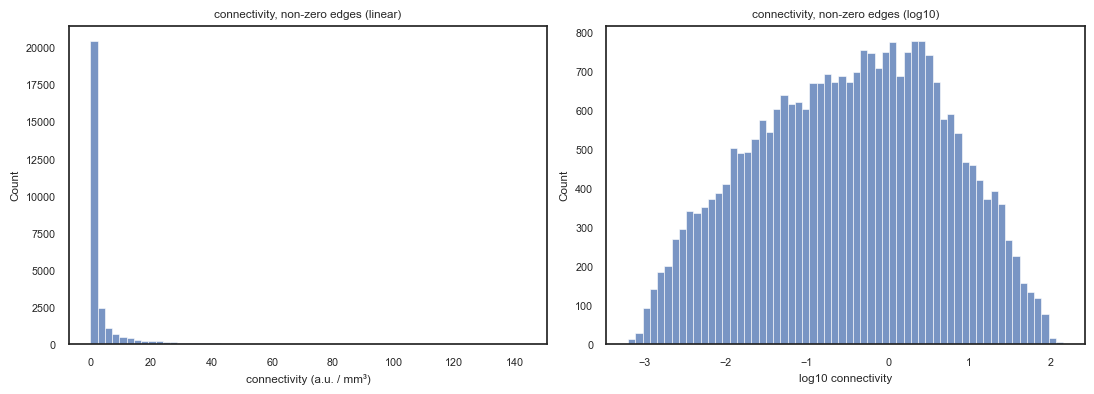

In [148]:
# Distribution of the striatum x cortex connectivity values that enter the stats
_ctx = [i for i, r in enumerate(region_list) if r.startswith(('L-', 'R-'))]
block = connmats[:, striatum_idx][:, :, _ctx].ravel()   # subjects x striatum x cortex
block_nz = block[np.isfinite(block) & (block > 0)]

print(f'{block.size} striatum x cortex edges  |  '
      f'{np.mean(block == 0) * 100:.1f}% exactly zero  |  '
      f'{np.mean(~np.isfinite(block)) * 100:.1f}% nan')
print('\nall edges:')
print(pd.Series(block).describe(percentiles=[.05, .25, .5, .75, .95, .99]))
print('\nnon-zero edges:')
print(pd.Series(block_nz).describe(percentiles=[.05, .25, .5, .75, .95, .99]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(block_nz, bins=60, ax=axes[0])
axes[0].set(title='connectivity, non-zero edges (linear)',
            xlabel='connectivity (a.u. / mm³)')
sns.histplot(np.log10(block_nz), bins=60, ax=axes[1])
axes[1].set(title='connectivity, non-zero edges (log10)', xlabel='log10 connectivity')
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'distribution_connectivity_striatum-cortex.svg'))


## Connectivity plots

In [149]:
num_participants = len(connmats)
print(f'Participants entering analysis: N = {num_participants}')

# Account for subjects not in the analysis. run_subject.sh skips any subject
# whose subject-space atlas has < 54 regions (warped before the prefrontal ROIs
# were added), so those have no _sift2-noscaling connectome. Check the atlas
# files directly for a complete picture.
_atlas_dir = '/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/atlas_space-sub'
_atlas_tail = (f'_atlas-custom_subcort-tian{tian_scale}_cort-carpet'
               '_atlas_warp-standard2acpc_dc_space-T1w.nii.gz')
_atlas_files = sorted(glob(os.path.join(_atlas_dir, '*', f'sub-*{_atlas_tail}')))
_by_regions = {}
for _a in _atlas_files:
    _sub = os.path.basename(_a).split('_')[0].replace('sub-', '')
    _n = int(np.asarray(nib.load(_a).dataobj).max())
    _by_regions.setdefault(_n, []).append(_sub)

print(f'\nsubject-space atlases found: {len(_atlas_files)}')
for _n, _subs in sorted(_by_regions.items()):
    _flag = 'analysed' if _n == num_regions else 'EXCLUDED (re-warp with 54-region atlas)'
    print(f'  {_n:>2}-region: {len(_subs):>3} subjects   <- {_flag}')
_excluded = sorted(s for n, ss in _by_regions.items() if n != num_regions for s in ss)
if _excluded:
    print(f'\nexcluded: {" ".join(_excluded)}')


Participants entering analysis: N = 97

subject-space atlases found: 175
  32-region:  75 subjects   <- EXCLUDED (re-warp with 54-region atlas)
  54-region: 100 subjects   <- analysed

excluded: 318637 320826 330324 346137 352738 360030 365343 380036 381038 385046 389357 393247 395756 397760 401422 406836 412528 429040 436845 463040 467351 525541 541943 547046 562345 572045 573249 581450 585256 601127 617748 627549 638049 644246 654552 671855 680957 690152 706040 724446 725751 732243 745555 751550 757764 765864 770352 771354 782561 783462 789373 814649 818859 825048 826353 833249 861456 871762 872764 878776 878877 898176 899885 901139 901442 905147 910241 926862 927359 942658 943862 951457 958976 966975 971160


In [150]:
plot_df = mean_df.iloc[:, 2:]


In [151]:
plot_df

,aPUT-lh,pPUT-lh,aCAU-lh,pCAU-lh,aPUT-rh,pPUT-rh,aCAU-rh,pCAU-rh,L-HG,L-PP,...,L-OccFus,L-SupraCalc,L-OccPole,R-LOCsup,R-LOCinf,R-IntraCalc,R-TempOccFus,R-OccFus,R-SupraCalc,R-OccPole
0,15.843611,9.152408,6.362343,1.521729,0.099018,0.064089,0.109835,0.083469,0.411824,3.024251,...,3.400822,0.103699,8.091405e-01,0.000000e+00,0.000000,0.004171,0.000546,0.000029,0.000403,0.000082
1,9.037599,16.098125,0.774869,3.767562,0.052356,0.190501,0.040169,0.112483,14.316424,17.110161,...,4.628557,0.293851,1.289548e+01,2.043976e-02,0.000000,0.022401,0.003029,0.000438,0.016908,0.013172
2,10.088260,1.235667,34.435380,10.523139,0.146888,0.081119,0.628385,0.222952,0.037202,0.342886,...,0.215260,0.042310,1.687352e-04,1.713069e-03,0.000000,0.013216,0.007635,0.003905,0.001367,0.000000
3,4.304238,10.753248,18.649805,30.134651,0.224386,0.576500,0.471823,1.167472,0.098391,0.764131,...,0.081952,0.032795,1.208763e-01,1.429726e-02,0.000563,0.003180,0.009578,0.000134,0.002305,0.000000
4,0.098797,0.052302,0.097265,0.084601,22.320111,9.985507,5.646596,1.064910,0.000115,0.014501,...,0.004782,0.000187,5.945285e-05,3.784700e+00,1.073099,1.622408,0.379248,4.401973,0.065600,1.153665
5,0.056805,0.169194,0.047417,0.186166,8.827196,16.132108,0.809720,3.703547,0.012657,0.005154,...,0.000487,0.037604,1.844454e-03,2.441507e+01,2.753023,1.737819,0.842843,5.179266,0.149808,11.953228
6,0.162948,0.059047,0.612046,0.257784,8.754904,1.414361,32.280662,17.019171,0.001225,0.015016,...,0.002191,0.000352,0.000000e+00,2.101150e-01,0.031657,0.087886,0.077459,0.224840,0.012038,0.000666
7,0.228056,0.301591,0.411615,1.226971,3.179294,12.457784,32.499415,42.090692,0.005306,0.022795,...,0.000030,0.000798,0.000000e+00,2.891621e+00,0.239378,0.070085,0.064967,0.055025,0.009328,0.070746
8,970.390583,33755.756955,57.537249,81.138147,0.269865,32.324981,1.744965,4.201265,105515.149369,51001.776037,...,94.631302,90.185606,2.737349e+02,2.975083e+01,0.024015,10.854033,0.902458,0.111290,10.923143,0.172373
9,7145.624210,40355.323595,500.155320,609.197830,35.189621,13.381431,24.323349,20.078423,51001.776037,107113.938298,...,9084.433101,626.237484,1.634747e+04,2.167125e+00,0.000000,26.256602,3.916008,0.000000,12.487710,18.637080


In [152]:
roi_dir = os.path.join('/Users/dsj3886/data_local/derivatives/',
                       'atlas-custom_subcort-tians2_cort-aud-vis-prefrontal')

In [153]:
print(roi_dir)

/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-prefrontal


In [154]:
cau_lh_list = sorted(glob(roi_dir+'/*CAU*lh.nii.gz'))
put_lh_list = sorted(glob(roi_dir+'/*PUT*lh.nii.gz'))
cau_rh_list = sorted(glob(roi_dir+'/*CAU*rh.nii.gz'))
put_rh_list = sorted(glob(roi_dir+'/*PUT*rh.nii.gz'))

cp_list = cau_lh_list + put_lh_list + cau_rh_list + put_rh_list

In [155]:
cp_list

['/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-prefrontal/atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal_aCAU-lh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-prefrontal/atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal_pCAU-lh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-prefrontal/atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal_aPUT-lh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-prefrontal/atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal_pPUT-lh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-prefrontal/atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal_aCAU-rh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-prefrontal/atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal_pCAU-rh.nii.gz',
 '/Users/dsj3886/data_local/deriva

In [156]:
cp_roi_list = [os.path.basename(x).split('.')[0].split('prefrontal_')[1] for x in cp_list]

print(cp_roi_list)


['aCAU-lh', 'pCAU-lh', 'aPUT-lh', 'pPUT-lh', 'aCAU-rh', 'pCAU-rh', 'aPUT-rh', 'pPUT-rh']


In [157]:
cp_sl_list = []
for rx, roi_name in enumerate(cp_roi_list):
    print(roi_name)
    roi_row = mean_df[mean_df.seed==roi_name]
    print(roi_row)

    roi_row_corrected = roi_row.iloc[0,2:].to_numpy() 
    print(roi_row_corrected)

    cp_sl_list.append(roi_row_corrected)

aCAU-lh
   mean_slcount     seed   aPUT-lh   pPUT-lh   aCAU-lh    pCAU-lh   aPUT-rh  \
2  21150.290426  aCAU-lh  10.08826  1.235667  34.43538  10.523139  0.146888   

    pPUT-rh   aCAU-rh   pCAU-rh  ...  L-OccFus  L-SupraCalc  L-OccPole  \
2  0.081119  0.628385  0.222952  ...   0.21526      0.04231   0.000169   

   R-LOCsup  R-LOCinf  R-IntraCalc  R-TempOccFus  R-OccFus  R-SupraCalc  \
2  0.001713       0.0     0.013216      0.007635  0.003905     0.001367   

   R-OccPole  
2        0.0  

[1 rows x 56 columns]
[10.088260032576324 1.2356665193343859 34.43538000709797
 10.523138597766955 0.14688819208330245 0.08111948045580836
 0.6283850354354508 0.22295178812098948 0.0372015221008986
 0.3428860245031043 0.10948102672501753 0.019756243487607572
 0.016705712803051664 0.002240423682150928 0.01193800812874288
 0.0045245366190372295 4.3457192512762676e-05 0.0005576810432308967
 52.613436215513154 4.285697360106514 7.785690764406377 1.8310800990410696
 7.995632021067542 0.3921027535523494

In [158]:
cs_df = pd.DataFrame(data=cp_sl_list, 
                          columns=region_list,
                          index=cp_roi_list)
print(cs_df)

           aPUT-lh    pPUT-lh    aCAU-lh    pCAU-lh    aPUT-rh    pPUT-rh  \
aCAU-lh  10.088260   1.235667  34.435380  10.523139   0.146888   0.081119   
pCAU-lh   4.304238  10.753248  18.649805  30.134651   0.224386   0.576500   
aPUT-lh  15.843611   9.152408   6.362343   1.521729   0.099018   0.064089   
pPUT-lh   9.037599  16.098125   0.774869   3.767562   0.052356   0.190501   
aCAU-rh   0.162948   0.059047   0.612046   0.257784   8.754904   1.414361   
pCAU-rh   0.228056   0.301591   0.411615   1.226971   3.179294  12.457784   
aPUT-rh   0.098797   0.052302   0.097265   0.084601  22.320111   9.985507   
pPUT-rh   0.056805   0.169194   0.047417   0.186166   8.827196  16.132108   

           aCAU-rh    pCAU-rh       L-HG       L-PP  ...  L-OccFus  \
aCAU-lh   0.628385   0.222952   0.037202   0.342886  ...  0.215260   
pCAU-lh   0.471823   1.167472   0.098391   0.764131  ...  0.081952   
aPUT-lh   0.109835   0.083469   0.411824   3.024251  ...  3.400822   
pPUT-lh   0.040169   0.112

In [159]:
region_list

['aPUT-lh',
 'pPUT-lh',
 'aCAU-lh',
 'pCAU-lh',
 'aPUT-rh',
 'pPUT-rh',
 'aCAU-rh',
 'pCAU-rh',
 'L-HG',
 'L-PP',
 'L-PT',
 'L-STGa',
 'L-STGp',
 'R-HG',
 'R-PP',
 'R-PT',
 'R-STGa',
 'R-STGp',
 'L-FP',
 'R-FP',
 'L-SFG',
 'R-SFG',
 'L-MFG',
 'R-MFG',
 'L-IFGt',
 'R-IFGt',
 'L-IFGo',
 'R-IFGo',
 'L-PreCG',
 'R-PreCG',
 'L-FMC',
 'R-FMC',
 'L-PCG',
 'R-PCG',
 'L-ACC',
 'R-ACC',
 'L-OFC',
 'R-OFC',
 'L-FO',
 'R-FO',
 'L-LOCsup',
 'L-LOCinf',
 'L-IntraCalc',
 'L-TempOccFus',
 'L-OccFus',
 'L-SupraCalc',
 'L-OccPole',
 'R-LOCsup',
 'R-LOCinf',
 'R-IntraCalc',
 'R-TempOccFus',
 'R-OccFus',
 'R-SupraCalc',
 'R-OccPole']

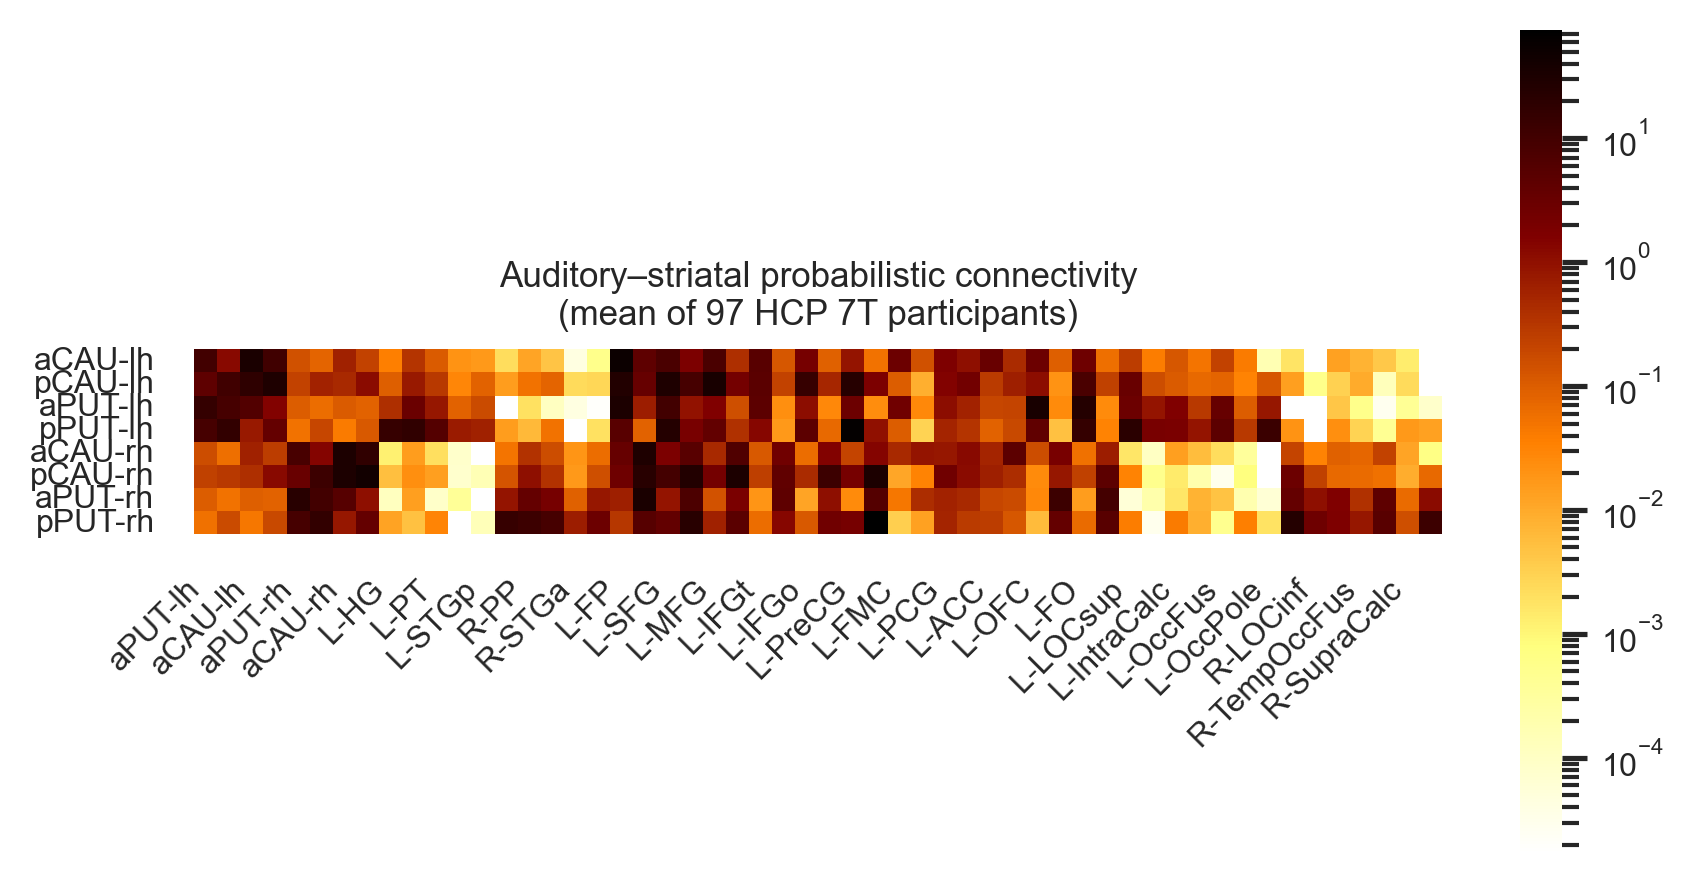

In [160]:
df_max = cs_df.to_numpy().max()

sns.set(font_scale=.7)
sns.set_style("white")

f, ax = plt.subplots(1,1,figsize=(6,3), dpi=300)

sns.heatmap(cs_df, ax=ax, cmap="afmhot_r",
            norm=colors.LogNorm(vmin=np.nanmin(cs_df.values[cs_df.values > 0]), vmax=df_max),
            square=True)
ax.set_title(f'Auditory–striatal probabilistic connectivity\n(mean of {num_participants} HCP 7T participants)');
#ax.tick_params(rotation=45, ha='right');
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

#sns.heatmap(right_cs_df, ax=ax[1], cmap="afmhot_r",
#            norm=colors.LogNorm(vmin=np.nanmin(cs_df.values[cs_df.values > 0]), vmax=df_max),)
#ax[1].tick_params(rotation=45);
#ax[1].set_title('Right hemisphere auditory–striatal probabilistic connectivity');
f.tight_layout()

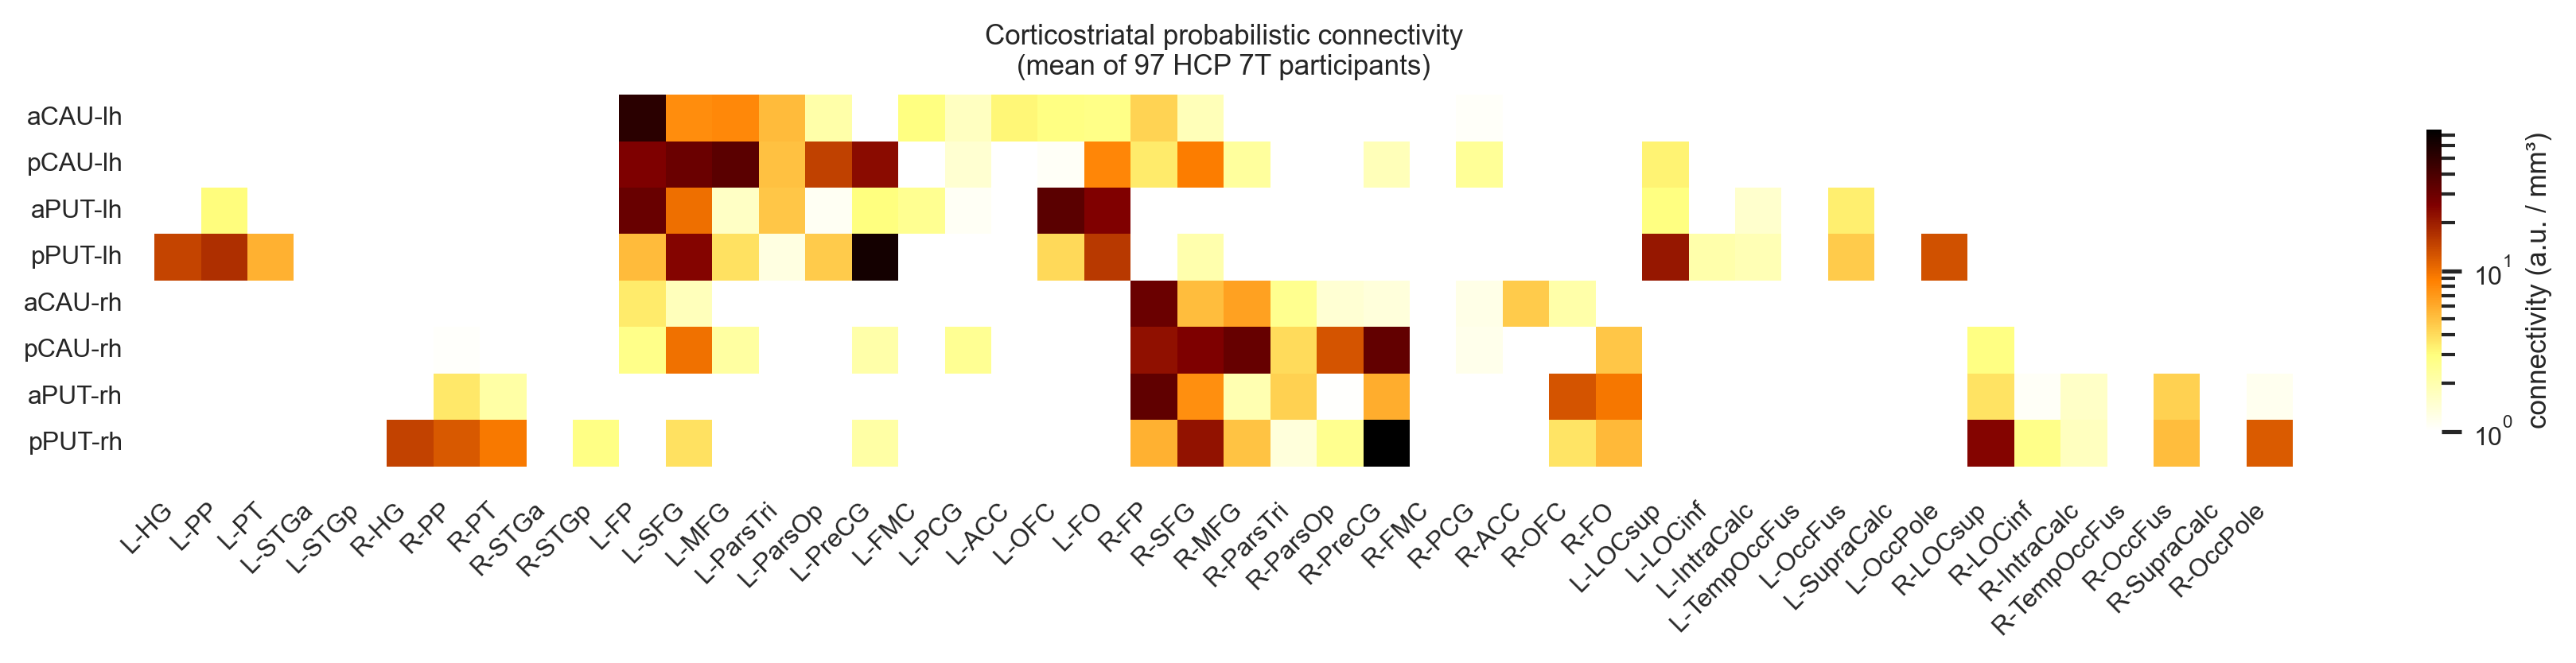

In [161]:
cortical_cols = [r for r in cs_df.columns if r.startswith(('L-', 'R-'))]

# Prefrontal ROIs were added with alternating L/R pairs; regroup to L-all then R-all
_pfc_base = {'FP', 'SFG', 'MFG', 'IFGt', 'IFGo', 'PreCG', 'FMC', 'PCG', 'ACC', 'OFC', 'FO'}
pfc_cols  = [c for c in cortical_cols if c[2:] in _pfc_base]
pfc_start = cortical_cols.index(pfc_cols[0])
pfc_end   = cortical_cols.index(pfc_cols[-1]) + 1

reordered = (cortical_cols[:pfc_start]
             + [c for c in pfc_cols if c.startswith('L-')]
             + [c for c in pfc_cols if c.startswith('R-')]
             + cortical_cols[pfc_end:])

cs_df_cortical = cs_df[reordered]
cs_df_cortical_display = cs_df_cortical.copy()
cs_df_cortical_display.columns = [_display_label(c) for c in cs_df_cortical_display.columns]

df_max = cs_df_cortical.to_numpy().max()

sns.set(font_scale=.7)
sns.set_style("white")

f, ax = plt.subplots(1, 1, figsize=(12, 3), dpi=300)

sns.heatmap(cs_df_cortical_display, ax=ax, cmap="afmhot_r",
            cbar_kws={'label': 'connectivity (a.u. / mm³)', 'shrink': 0.5},
            norm=colors.LogNorm(vmin=1, vmax=df_max),
            square=True)
ax.set_title(f'Corticostriatal probabilistic connectivity\n(mean of {num_participants} HCP 7T participants)')
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

f.savefig(os.path.join(FIGURES_DIR, 'heatmap_mean-streamlines_all-regions.svg'))
f.tight_layout()


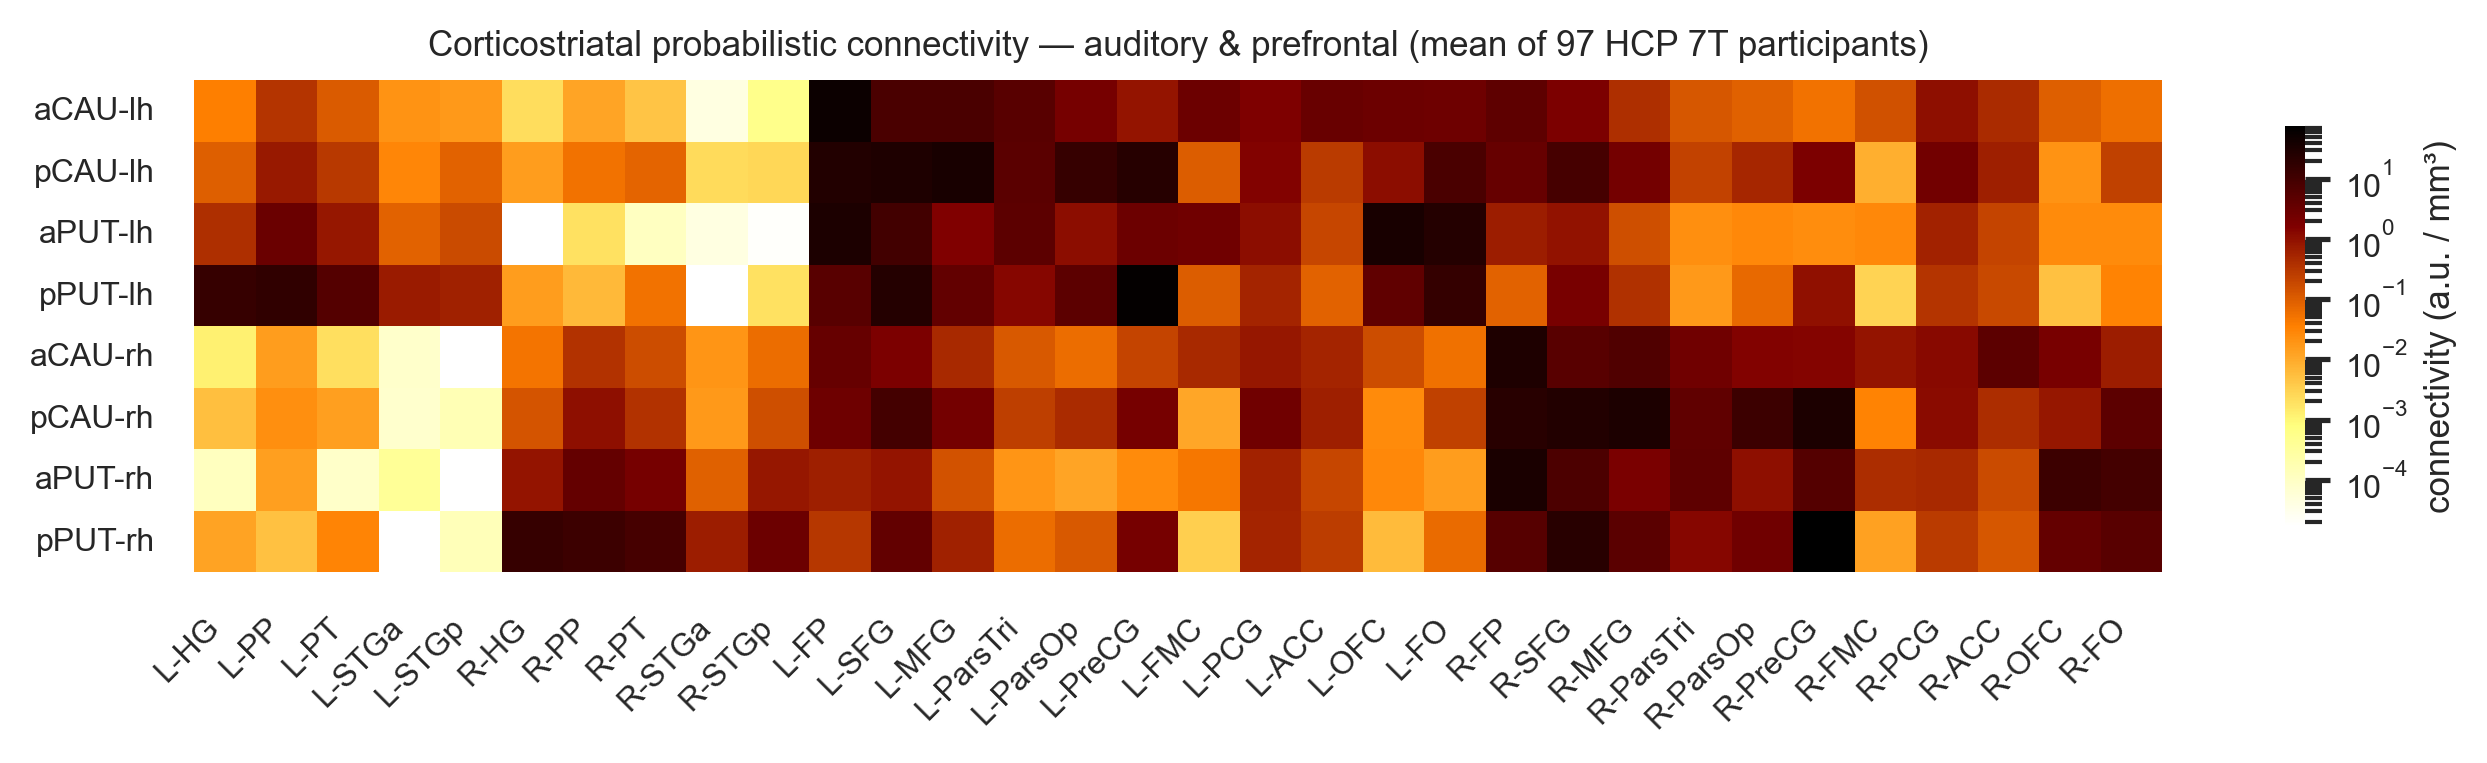

In [162]:
_aud_base = {'HG', 'PP', 'PT', 'STGa', 'STGp'}
no_vis_cols = [c for c in reordered if c[2:] in (_aud_base | _pfc_base)]
cs_df_no_vis = cs_df[no_vis_cols]
cs_df_no_vis_display = cs_df_no_vis.copy()
cs_df_no_vis_display.columns = [_display_label(c) for c in cs_df_no_vis_display.columns]

df_max_nov = cs_df_no_vis.to_numpy().max()

f2, ax2 = plt.subplots(1, 1, figsize=(9, 3), dpi=300)

sns.heatmap(cs_df_no_vis_display, ax=ax2, cmap="afmhot_r",
            cbar_kws={'label': 'connectivity (a.u. / mm³)', 'shrink': 0.5},
            norm=colors.LogNorm(vmin=np.nanmin(cs_df_no_vis.values[cs_df_no_vis.values > 0]), vmax=df_max_nov),
            square=True)
ax2.set_title(f'Corticostriatal probabilistic connectivity — auditory & prefrontal (mean of {num_participants} HCP 7T participants)')
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")

f.savefig(os.path.join(FIGURES_DIR, 'heatmap_mean-streamlines_auditory-prefrontal-regions.svg'))
f2.tight_layout()


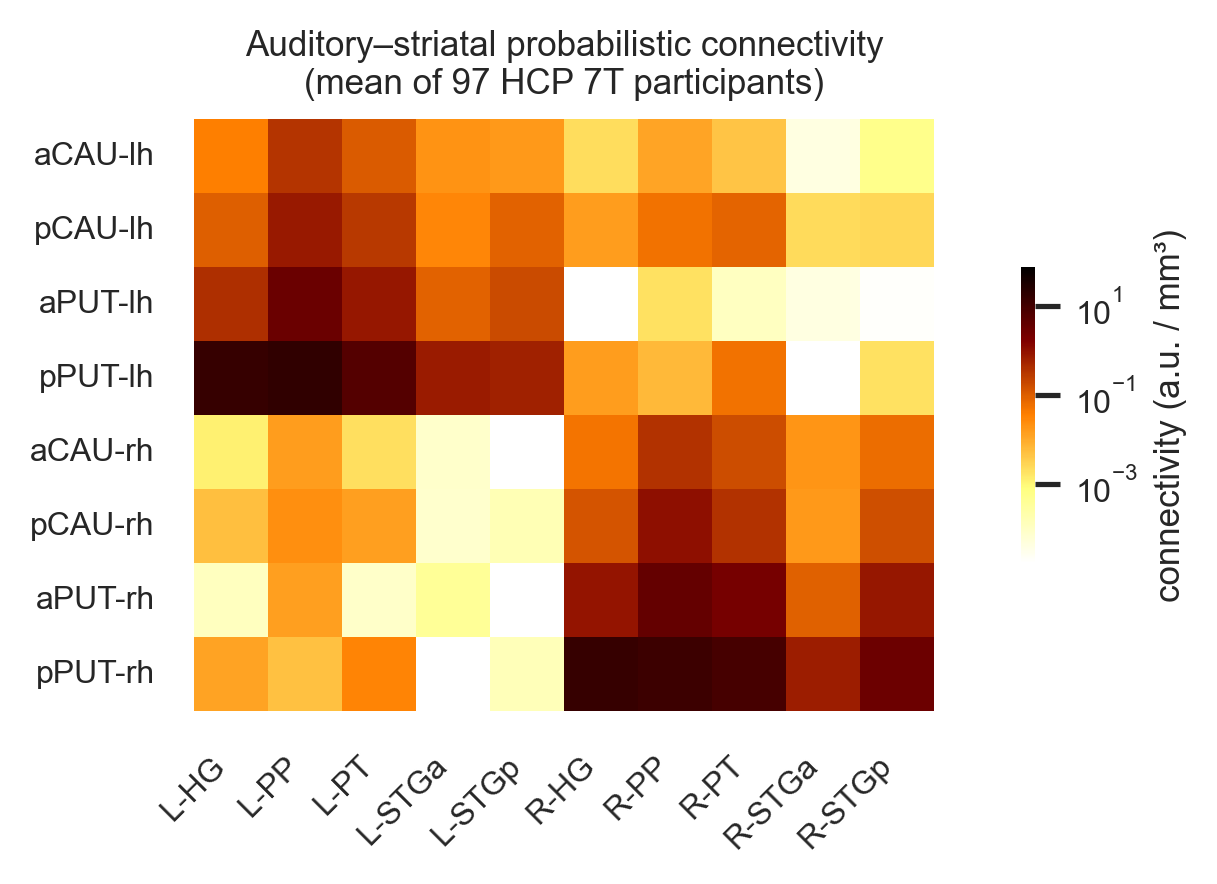

In [163]:
df_max = cs_df.to_numpy().max()
cs_df_aud_display = cs_df.iloc[:,8:18].copy()
cs_df_aud_display.columns = [_display_label(c) for c in cs_df_aud_display.columns]

sns.set(font_scale=.7)
sns.set_style("white")

f, ax = plt.subplots(1,1,figsize=(6,3), dpi=300)

sns.heatmap(cs_df_aud_display, ax=ax, cmap="afmhot_r",
            norm=colors.LogNorm(vmin=np.nanmin(cs_df.iloc[:, 8:18].values[cs_df.iloc[:, 8:18].values > 0]), vmax=df_max),
            cbar_kws={'label': 'connectivity (a.u. / mm³)', 'shrink': 0.5},
            square=True)
ax.set_title(f'Auditory–striatal probabilistic connectivity\n(mean of {num_participants} HCP 7T participants)');
#ax.tick_params(rotation=45, ha='right');
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

#sns.heatmap(right_cs_df, ax=ax[1], cmap="afmhot_r",
#            norm=colors.LogNorm(vmin=np.nanmin(cs_df.iloc[:, 8:18].values[cs_df.iloc[:, 8:18].values > 0]), vmax=df_max),)
#ax[1].tick_params(rotation=45);
#ax[1].set_title('Right hemisphere auditory–striatal probabilistic connectivity');

f.savefig(os.path.join(FIGURES_DIR, 'heatmap_mean-streamlines_auditory-regions.svg'))

f.tight_layout()

## Combine separate participants into single dataframe

In [164]:
participant_df_list = []
for i in range(connmats.shape[0]):
    df = pd.DataFrame(connmats[i], index=region_list, columns=region_list)
    df['participant_id'] = i
    participant_df_list.append(df)

In [165]:
striatum_rois = [r for r in region_list if r.startswith(('aPUT', 'pPUT', 'aCAU', 'pCAU'))]
cortex_rois = [r for r in region_list if r.startswith(('L-', 'R-'))]

filtered_df_list = []
for df in participant_df_list:
    sub_df = df.loc[striatum_rois, cortex_rois]
    sub_df['participant_id'] = df['participant_id'].iloc[0]
    filtered_df_list.append(sub_df)

In [166]:
rostral_caudal_map = {
    'aPUT-lh': 'Rostral', 'aCAU-lh': 'Rostral',
    'pPUT-lh': 'Caudal', 'pCAU-lh': 'Caudal',
    'aPUT-rh': 'Rostral', 'aCAU-rh': 'Rostral',
    'pPUT-rh': 'Caudal', 'pCAU-rh': 'Caudal'
}

for df in filtered_df_list:
    df['Rostral_Caudal'] = df.index.map(rostral_caudal_map)

In [167]:
caudate_putamen_map = {
    'aPUT-lh': 'Putamen', 'aCAU-lh': 'Caudate',
    'pPUT-lh': 'Putamen', 'pCAU-lh': 'Caudate',
    'aPUT-rh': 'Putamen', 'aCAU-rh': 'Caudate',
    'pPUT-rh': 'Putamen', 'pCAU-rh': 'Caudate'
}

for df in filtered_df_list:
    df['Caudate_Putamen'] = df.index.map(caudate_putamen_map)

In [168]:
all_df = pd.concat(filtered_df_list)
all_df = all_df.reset_index().rename(columns={'index': 'Striatum_ROI'})

In [169]:

# Melt to long format
all_long_df = all_df.melt(id_vars=['participant_id', 'Striatum_ROI', 'Rostral_Caudal', 'Caudate_Putamen'], 
                      value_vars=cortex_rois, 
                      var_name='Cortex_ROI', value_name='Connectivity')


In [170]:
all_long_df.head()

,participant_id,Striatum_ROI,Rostral_Caudal,Caudate_Putamen,Cortex_ROI,Connectivity
0,0,aPUT-lh,Rostral,Putamen,L-HG,0.233406
1,0,pPUT-lh,Caudal,Putamen,L-HG,13.765694
2,0,aCAU-lh,Rostral,Caudate,L-HG,0.027923
3,0,pCAU-lh,Caudal,Caudate,L-HG,0.317246
4,0,aPUT-rh,Rostral,Putamen,L-HG,0.001907


In [171]:
# Add hemisphere info before stripping labels
def get_striatum_hemisphere(roi):
    if roi.endswith('-lh'):
        return 'Left'
    elif roi.endswith('-rh'):
        return 'Right'
    else:
        return None

def get_cortex_hemisphere(roi):
    if roi.startswith('L-'):
        return 'Left'
    elif roi.startswith('R-'):
        return 'Right'
    else:
        return None

all_long_df['striatum_hemisphere'] = all_long_df['Striatum_ROI'].apply(get_striatum_hemisphere)
all_long_df['cortex_hemisphere'] = all_long_df['Cortex_ROI'].apply(get_cortex_hemisphere)

# Keep only rows where hemispheres match
all_long_df = all_long_df[all_long_df['striatum_hemisphere'] == all_long_df['cortex_hemisphere']]

# Optionally, create a single 'hemisphere' column and strip hemisphere labels
all_long_df['hemisphere'] = all_long_df['striatum_hemisphere']
all_long_df['Striatum_ROI'] = all_long_df['Striatum_ROI'].apply(lambda x: x[:-3] if x.endswith(('-lh', '-rh')) else x)
all_long_df['Cortex_ROI'] = all_long_df['Cortex_ROI'].apply(lambda x: x[2:] if x.startswith(('L-', 'R-')) else x)

In [172]:
all_long_df.shape

(17848, 9)

In [173]:
all_long_df.head()

,participant_id,Striatum_ROI,Rostral_Caudal,Caudate_Putamen,Cortex_ROI,Connectivity,striatum_hemisphere,cortex_hemisphere,hemisphere
0,0,aPUT,Rostral,Putamen,HG,0.233406,Left,Left,Left
1,0,pPUT,Caudal,Putamen,HG,13.765694,Left,Left,Left
2,0,aCAU,Rostral,Caudate,HG,0.027923,Left,Left,Left
3,0,pCAU,Caudal,Caudate,HG,0.317246,Left,Left,Left
8,1,aPUT,Rostral,Putamen,HG,0.270936,Left,Left,Left


In [174]:
all_long_df.Cortex_ROI.unique()

array(['HG', 'PP', 'PT', 'STGa', 'STGp', 'FP', 'SFG', 'MFG', 'IFGt',
       'IFGo', 'PreCG', 'FMC', 'PCG', 'ACC', 'OFC', 'FO', 'LOCsup',
       'LOCinf', 'IntraCalc', 'TempOccFus', 'OccFus', 'SupraCalc',
       'OccPole'], dtype=object)

In [175]:
auditory_rois = ['HG', 'PP', 'PT', 'STGp', 'STGa']
aud_long_df = all_long_df[all_long_df['Cortex_ROI'].isin(auditory_rois)]


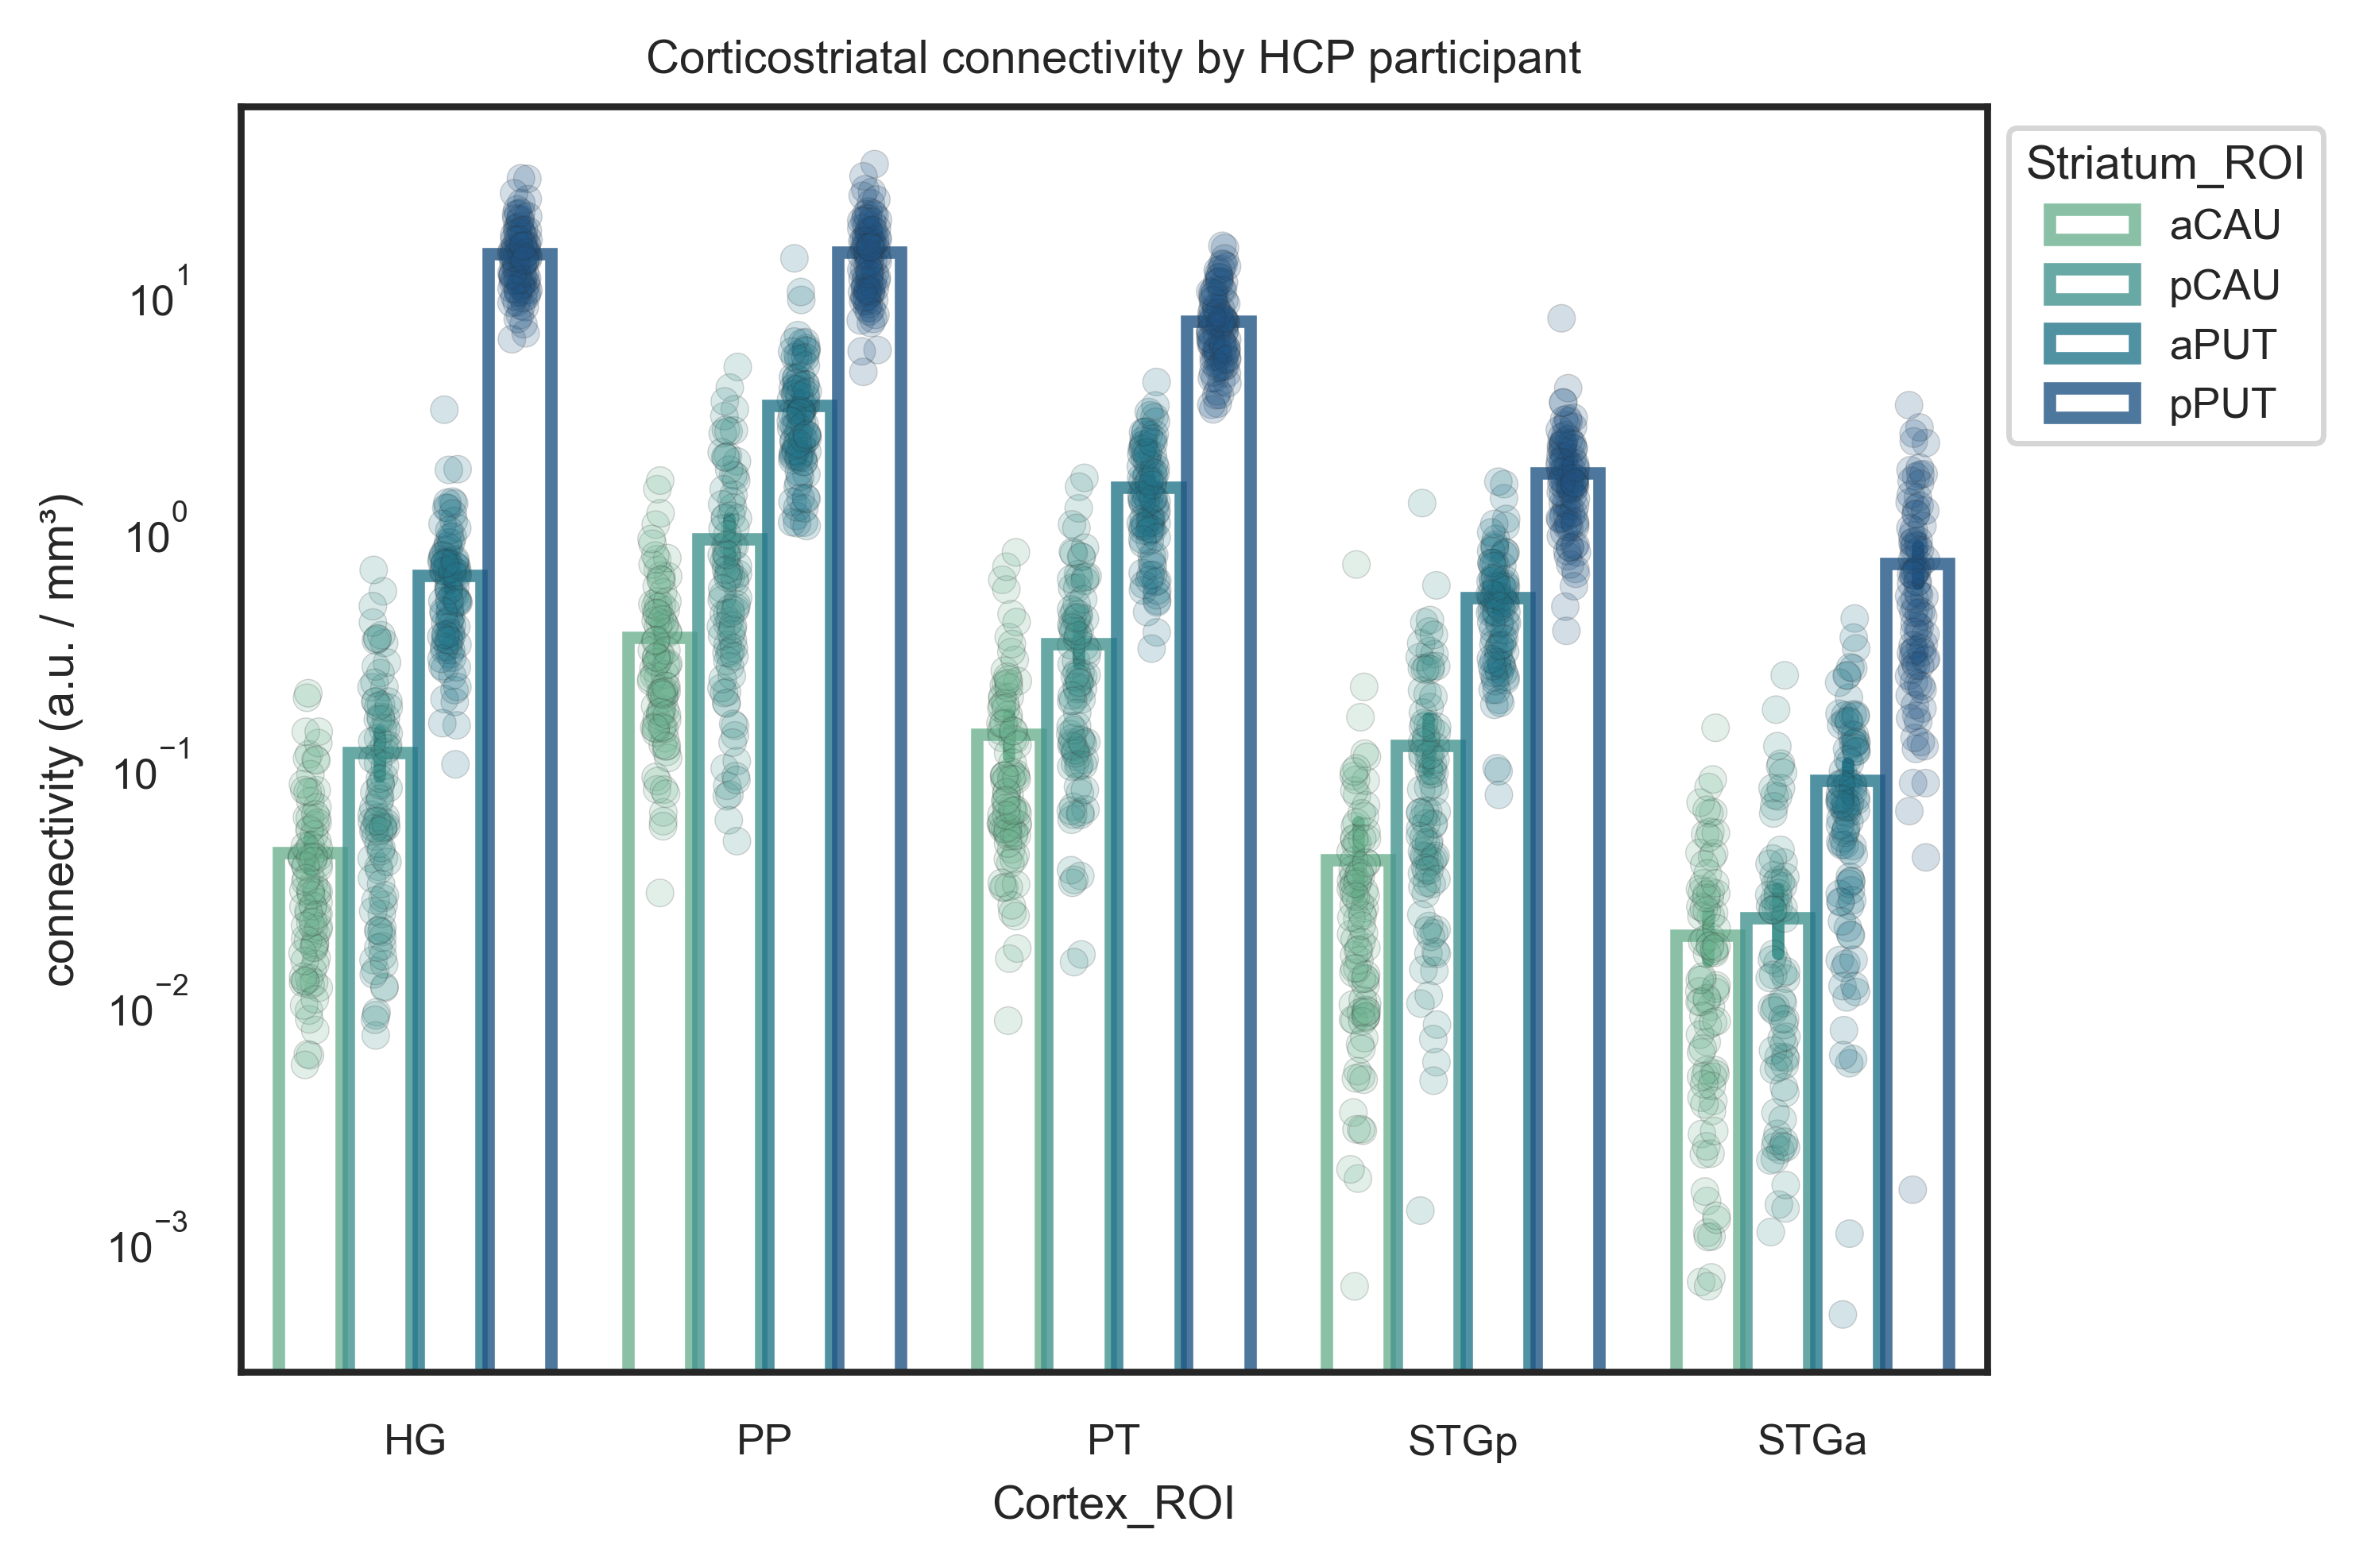

In [176]:
df_collapsed = aud_long_df.groupby(["participant_id", 'Cortex_ROI', 'Striatum_ROI',], 
                                       as_index=False).agg({"Connectivity": "mean"})

fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=500)

sns.barplot(data=df_collapsed, 
              x='Cortex_ROI', y='Connectivity', 
              order=auditory_rois,
              hue='Striatum_ROI', hue_order=['aCAU', 'pCAU', 'aPUT', 'pPUT'],
              palette='crest',  
              #fliersize=0, whis=(8, 92),
              #linewidth=1.5,
              alpha=0.8, gap=0.1, fill=False,
              #legend=None,
              ax=ax)
sns.stripplot(data=df_collapsed, 
              x='Cortex_ROI', y='Connectivity', 
              order=auditory_rois,
              hue='Striatum_ROI', hue_order=['aCAU', 'pCAU', 'aPUT', 'pPUT'],
              palette='crest',
              dodge=True,
              jitter=True,
              linewidth=0.2,
              alpha=0.2,
              legend=None,
              ax=ax)

#ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'Corticostriatal connectivity by HCP participant');
plt.yscale('log')
ax.set_ylabel('connectivity (a.u. / mm³)')
#ax.set_ylim([-5, 5])

fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'streamline-count_x-cortex_hue-striatum.svg'))

## Across-participant statistics

**Omnibus ANOVAs** are repeated-measures ANOVAs on the untransformed connectivity
values: `statsmodels` `AnovaRM` for the 3- and 4-factor designs, and `pingouin`
`rm_anova` (Greenhouse–Geisser correction + partial η²) for the 2-factor designs.

**Pairwise post-hoc comparisons** use the **Wilcoxon signed-rank test**
(`pg.pairwise_tests(..., parametric=False)`, Benjamini–Hochberg FDR). The
connectivity values are strongly right-skewed with a spike at zero (region pairs
with no streamlines), which breaks the normality assumption of the paired
*t*-test; the rank-based Wilcoxon test is robust to it. The omnibus ANOVAs have
**not** yet been adapted (log-transform or non-parametric) — a known limitation.


In [177]:
from statsmodels.stats.anova import AnovaRM
import pingouin as pg

In [178]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
from stats_fmt import export_anova, export_posthoc

STATS_OUT_DIR = 'stats_exports/gpexcl_visual'
os.makedirs(STATS_OUT_DIR, exist_ok=True)

FIGURES_DIR = 'figures/gpexcl_visual'
os.makedirs(FIGURES_DIR, exist_ok=True)


### All factors

In [179]:
# Mixed-Effects ANOVA with all factors and interactions
aov = AnovaRM(aud_long_df, 
              aggregate_func='mean',
              depvar='Connectivity', 
              subject='participant_id', 
              within=['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI', 'hemisphere',]).fit()

# Display results
aov.summary()
export_anova(aov, 'aud_full', STATS_OUT_DIR)


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Caudate_Putamen,1148.51,1.0,96.0,p < .001,,,,"F(1, 96) = 1148.51, p < .001"
1,Rostral_Caudal,928.83,1.0,96.0,p < .001,,,,"F(1, 96) = 928.83, p < .001"
2,Cortex_ROI,568.60,4.0,384.0,p < .001,,,,"F(4, 384) = 568.60, p < .001"
3,hemisphere,7.68,1.0,96.0,p = .007,,,,"F(1, 96) = 7.68, p = .007"
4,Caudate_Putamen:Rostral_Caudal,896.48,1.0,96.0,p < .001,,,,"F(1, 96) = 896.48, p < .001"
5,Caudate_Putamen:Cortex_ROI,500.81,4.0,384.0,p < .001,,,,"F(4, 384) = 500.81, p < .001"
6,Rostral_Caudal:Cortex_ROI,357.35,4.0,384.0,p < .001,,,,"F(4, 384) = 357.35, p < .001"
7,Caudate_Putamen:hemisphere,5.85,1.0,96.0,p = .017,,,,"F(1, 96) = 5.85, p = .017"
8,Rostral_Caudal:hemisphere,1.50,1.0,96.0,p = .223,,,,"F(1, 96) = 1.50, p = .223"
9,Cortex_ROI:hemisphere,53.05,4.0,384.0,p < .001,,,,"F(4, 384) = 53.05, p < .001"


### No hemisphere

In [180]:
# Mixed-Effects ANOVA with all factors and interactions
aov = AnovaRM(aud_long_df, 
              aggregate_func='mean',
              depvar='Connectivity', 
              subject='participant_id', 
              within=['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI']).fit()

# Display results
aov.summary()
export_anova(aov, 'aud_cau_rostral_roi', STATS_OUT_DIR)


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Caudate_Putamen,1148.51,1.0,96.0,p < .001,,,,"F(1, 96) = 1148.51, p < .001"
1,Rostral_Caudal,928.83,1.0,96.0,p < .001,,,,"F(1, 96) = 928.83, p < .001"
2,Cortex_ROI,568.60,4.0,384.0,p < .001,,,,"F(4, 384) = 568.60, p < .001"
3,Caudate_Putamen:Rostral_Caudal,896.48,1.0,96.0,p < .001,,,,"F(1, 96) = 896.48, p < .001"
4,Caudate_Putamen:Cortex_ROI,500.81,4.0,384.0,p < .001,,,,"F(4, 384) = 500.81, p < .001"
5,Rostral_Caudal:Cortex_ROI,357.35,4.0,384.0,p < .001,,,,"F(4, 384) = 357.35, p < .001"
6,Caudate_Putamen:Rostral_Caudal:Cortex_ROI,357.37,4.0,384.0,p < .001,,,,"F(4, 384) = 357.37, p < .001"


### Caudate–Putamen

In [181]:
# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(aud_long_df, 
              aggregate_func='mean',
              depvar='Connectivity', 
              subject='participant_id', 
              within=['Caudate_Putamen', 'Cortex_ROI', 'hemisphere',]).fit()

# Display results
aov.summary()
export_anova(aov, 'aud_cau_roi_hemi', STATS_OUT_DIR)


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Caudate_Putamen,1148.51,1.0,96.0,p < .001,,,,"F(1, 96) = 1148.51, p < .001"
1,Cortex_ROI,568.60,4.0,384.0,p < .001,,,,"F(4, 384) = 568.60, p < .001"
2,hemisphere,7.68,1.0,96.0,p = .007,,,,"F(1, 96) = 7.68, p = .007"
3,Caudate_Putamen:Cortex_ROI,500.81,4.0,384.0,p < .001,,,,"F(4, 384) = 500.81, p < .001"
4,Caudate_Putamen:hemisphere,5.85,1.0,96.0,p = .017,,,,"F(1, 96) = 5.85, p = .017"
5,Cortex_ROI:hemisphere,53.05,4.0,384.0,p < .001,,,,"F(4, 384) = 53.05, p < .001"
6,Caudate_Putamen:Cortex_ROI:hemisphere,69.90,4.0,384.0,p < .001,,,,"F(4, 384) = 69.90, p < .001"


#### 2-way: Cortex ROI x Caudate/Putamen

In [182]:
# 2-way RM-ANOVA (Greenhouse-Geisser + partial eta^2): the omnibus that the
# pairwise comparisons below follow up. Average over the other factors so
# there is one value per subject x cell.
_d = aud_long_df.groupby(['participant_id', 'Cortex_ROI', 'Caudate_Putamen'],
                     as_index=False)['Connectivity'].mean()
aov = pg.rm_anova(data=_d, dv='Connectivity',
                  within=['Cortex_ROI', 'Caudate_Putamen'],
                  subject='participant_id', detailed=True, effsize='np2')
display(aov)
export_anova(aov, 'aud_roi_cau', STATS_OUT_DIR)


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,np2,eps
0,Cortex_ROI,3067.031079,4,384,766.757770,568.600342,7.631901e-160,4.056713e-96,0.855552,0.593800
1,Caudate_Putamen,4489.375621,1,96,4489.375621,1148.509846,3.279704e-55,3.279704e-55,0.922861,1.000000
2,Cortex_ROI * Caudate_Putamen,2549.406867,4,384,637.351717,500.812301,6.999248e-151,5.333975e-89,0.839145,0.581681


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Cortex_ROI,568.60,4,384,p < .001,p < .001,0.856,0.594,"F(2.38, 228.02) = 568.60, p < .001 (GG ε=0.59)..."
1,Caudate_Putamen,1148.51,1,96,p < .001,p < .001,0.923,1.000,"F(1, 96) = 1148.51, p < .001, ηp² = .92"
2,Cortex_ROI * Caudate_Putamen,500.81,4,384,p < .001,p < .001,0.839,0.582,"F(2.33, 223.37) = 500.81, p < .001 (GG ε=0.58)..."


In [183]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=aud_long_df,
                             dv='Connectivity', 
                             within=[ 'Caudate_Putamen', 'Cortex_ROI'],
                             subject='participant_id',
                             padjust='fdr', parametric=False) 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Caudate_Putamen', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
#print(pairwise_interaction)
export_posthoc(pairwise, 'aud_cau_roi', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Caudate_Putamen', 'A', 'B', 'Paired', 'Parametric',
       'W_val', 'alternative', 'p_unc', 'p_corr', 'p_adjust', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Caudate_Putamen,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Caudate_Putamen,-,Caudate,Putamen,0.0,p < .001,n/a,"W = 0.0, p < .001",W = 0.0
1,Cortex_ROI,-,HG,PP,608.0,p < .001,p < .001,"W = 608.0, p < .001","W = 608.0, q < .001"
2,Cortex_ROI,-,HG,PT,35.0,p < .001,p < .001,"W = 35.0, p < .001","W = 35.0, q < .001"
3,Cortex_ROI,-,HG,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
4,Cortex_ROI,-,HG,STGp,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
5,Cortex_ROI,-,PP,PT,2.0,p < .001,p < .001,"W = 2.0, p < .001","W = 2.0, q < .001"
6,Cortex_ROI,-,PP,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
7,Cortex_ROI,-,PP,STGp,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
8,Cortex_ROI,-,PT,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
9,Cortex_ROI,-,PT,STGp,4.0,p < .001,p < .001,"W = 4.0, p < .001","W = 4.0, q < .001"


In [184]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=aud_long_df,
                             dv='Connectivity', 
                             within=['Cortex_ROI', 'Caudate_Putamen', ],
                             subject='participant_id',
                             padjust='fdr', parametric=False) 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Cortex_ROI', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
#print(pairwise_interaction)
export_posthoc(pairwise, 'aud_roi_cau', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'W_val',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Cortex_ROI,-,HG,PP,608.0,p < .001,p < .001,"W = 608.0, p < .001","W = 608.0, q < .001"
1,Cortex_ROI,-,HG,PT,35.0,p < .001,p < .001,"W = 35.0, p < .001","W = 35.0, q < .001"
2,Cortex_ROI,-,HG,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
3,Cortex_ROI,-,HG,STGp,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
4,Cortex_ROI,-,PP,PT,2.0,p < .001,p < .001,"W = 2.0, p < .001","W = 2.0, q < .001"
5,Cortex_ROI,-,PP,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
6,Cortex_ROI,-,PP,STGp,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
7,Cortex_ROI,-,PT,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
8,Cortex_ROI,-,PT,STGp,4.0,p < .001,p < .001,"W = 4.0, p < .001","W = 4.0, q < .001"
9,Cortex_ROI,-,STGa,STGp,9.0,p < .001,p < .001,"W = 9.0, p < .001","W = 9.0, q < .001"


In [185]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=aud_long_df,
                             dv='Connectivity', 
                             within=[ 'hemisphere', 'Cortex_ROI',],
                             subject='participant_id',
                             padjust='fdr', parametric=False) 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'hemisphere', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
#print(pairwise_interaction)
export_posthoc(pairwise, 'aud_hemi_roi', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'hemisphere', 'A', 'B', 'Paired', 'Parametric', 'W_val',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,hemisphere,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,hemisphere,-,Left,Right,1640.0,p = .008,n/a,"W = 1640.0, p = .008",W = 1640.0
1,Cortex_ROI,-,HG,PP,608.0,p < .001,p < .001,"W = 608.0, p < .001","W = 608.0, q < .001"
2,Cortex_ROI,-,HG,PT,35.0,p < .001,p < .001,"W = 35.0, p < .001","W = 35.0, q < .001"
3,Cortex_ROI,-,HG,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
4,Cortex_ROI,-,HG,STGp,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
5,Cortex_ROI,-,PP,PT,2.0,p < .001,p < .001,"W = 2.0, p < .001","W = 2.0, q < .001"
6,Cortex_ROI,-,PP,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
7,Cortex_ROI,-,PP,STGp,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
8,Cortex_ROI,-,PT,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
9,Cortex_ROI,-,PT,STGp,4.0,p < .001,p < .001,"W = 4.0, p < .001","W = 4.0, q < .001"


In [186]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=aud_long_df,
                             dv='Connectivity', 
                             within=[ 'Cortex_ROI', 'hemisphere',],
                             subject='participant_id',
                             padjust='fdr', parametric=False) 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Cortex_ROI', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
#print(pairwise_interaction)
export_posthoc(pairwise, 'aud_roi_hemi', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'W_val',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Cortex_ROI,-,HG,PP,608.0,p < .001,p < .001,"W = 608.0, p < .001","W = 608.0, q < .001"
1,Cortex_ROI,-,HG,PT,35.0,p < .001,p < .001,"W = 35.0, p < .001","W = 35.0, q < .001"
2,Cortex_ROI,-,HG,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
3,Cortex_ROI,-,HG,STGp,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
4,Cortex_ROI,-,PP,PT,2.0,p < .001,p < .001,"W = 2.0, p < .001","W = 2.0, q < .001"
5,Cortex_ROI,-,PP,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
6,Cortex_ROI,-,PP,STGp,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
7,Cortex_ROI,-,PT,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
8,Cortex_ROI,-,PT,STGp,4.0,p < .001,p < .001,"W = 4.0, p < .001","W = 4.0, q < .001"
9,Cortex_ROI,-,STGa,STGp,9.0,p < .001,p < .001,"W = 9.0, p < .001","W = 9.0, q < .001"


In [187]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=aud_long_df,
                             dv='Connectivity', 
                             within=['Striatum_ROI', 'hemisphere', ],
                             subject='participant_id',
                             padjust='fdr', parametric=False) 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast', 'Striatum_ROI', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
#print(pairwise)
export_posthoc(pairwise, 'aud_striatum_hemi', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Striatum_ROI', 'A', 'B', 'Paired', 'Parametric', 'W_val',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Striatum_ROI,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Striatum_ROI,-,aCAU,aPUT,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
1,Striatum_ROI,-,aCAU,pCAU,242.0,p < .001,p < .001,"W = 242.0, p < .001","W = 242.0, q < .001"
2,Striatum_ROI,-,aCAU,pPUT,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
3,Striatum_ROI,-,aPUT,pCAU,30.0,p < .001,p < .001,"W = 30.0, p < .001","W = 30.0, q < .001"
4,Striatum_ROI,-,aPUT,pPUT,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
5,Striatum_ROI,-,pCAU,pPUT,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
6,hemisphere,-,Left,Right,1640.0,p = .008,n/a,"W = 1640.0, p = .008",W = 1640.0
7,Striatum_ROI * hemisphere,aCAU,Left,Right,1887.0,p = .078,p = .105,"W = 1887.0, p = .078","W = 1887.0, q = .105"
8,Striatum_ROI * hemisphere,aPUT,Left,Right,401.0,p < .001,p < .001,"W = 401.0, p < .001","W = 401.0, q < .001"
9,Striatum_ROI * hemisphere,pCAU,Left,Right,1639.0,p = .008,p = .016,"W = 1639.0, p = .008","W = 1639.0, q = .016"


### Rostral–caudal

In [188]:
# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(aud_long_df, 
              aggregate_func='mean',
              depvar='Connectivity', 
              subject='participant_id', 
              within=['Rostral_Caudal', 'hemisphere', 'Cortex_ROI']).fit()

# Display results
aov.summary()
export_anova(aov, 'aud_rostral_hemi_roi', STATS_OUT_DIR)


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Rostral_Caudal,928.83,1.0,96.0,p < .001,,,,"F(1, 96) = 928.83, p < .001"
1,hemisphere,7.68,1.0,96.0,p = .007,,,,"F(1, 96) = 7.68, p = .007"
2,Cortex_ROI,568.60,4.0,384.0,p < .001,,,,"F(4, 384) = 568.60, p < .001"
3,Rostral_Caudal:hemisphere,1.50,1.0,96.0,p = .223,,,,"F(1, 96) = 1.50, p = .223"
4,Rostral_Caudal:Cortex_ROI,357.35,4.0,384.0,p < .001,,,,"F(4, 384) = 357.35, p < .001"
5,hemisphere:Cortex_ROI,53.05,4.0,384.0,p < .001,,,,"F(4, 384) = 53.05, p < .001"
6,Rostral_Caudal:hemisphere:Cortex_ROI,47.76,4.0,384.0,p < .001,,,,"F(4, 384) = 47.76, p < .001"


#### 2-way: Cortex ROI x Rostral/Caudal

In [189]:
# 2-way RM-ANOVA (Greenhouse-Geisser + partial eta^2): the omnibus that the
# pairwise comparisons below follow up. Average over the other factors so
# there is one value per subject x cell.
_d = aud_long_df.groupby(['participant_id', 'Cortex_ROI', 'Rostral_Caudal'],
                     as_index=False)['Connectivity'].mean()
aov = pg.rm_anova(data=_d, dv='Connectivity',
                  within=['Cortex_ROI', 'Rostral_Caudal'],
                  subject='participant_id', detailed=True, effsize='np2')
display(aov)
export_anova(aov, 'aud_roi_rostral', STATS_OUT_DIR)


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,np2,eps
0,Cortex_ROI,3067.031079,4,384,766.757770,568.600342,7.631901e-160,4.056713e-96,0.855552,0.593800
1,Rostral_Caudal,2792.416395,1,96,2792.416395,928.833075,3.700353e-51,3.700353e-51,0.906326,1.000000
2,Cortex_ROI * Rostral_Caudal,1760.273336,4,384,440.068334,357.353652,5.533152e-128,6.884449e-70,0.788245,0.535491


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Cortex_ROI,568.60,4,384,p < .001,p < .001,0.856,0.594,"F(2.38, 228.02) = 568.60, p < .001 (GG ε=0.59)..."
1,Rostral_Caudal,928.83,1,96,p < .001,p < .001,0.906,1.000,"F(1, 96) = 928.83, p < .001, ηp² = .91"
2,Cortex_ROI * Rostral_Caudal,357.35,4,384,p < .001,p < .001,0.788,0.535,"F(2.14, 205.63) = 357.35, p < .001 (GG ε=0.54)..."


In [190]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=aud_long_df,
                             dv='Connectivity', 
                             within=[ 'hemisphere', 'Rostral_Caudal',],
                             subject='participant_id',
                             padjust='fdr', parametric=False) 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'hemisphere', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
#print(pairwise_interaction)
export_posthoc(pairwise, 'aud_hemi_rostral', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'hemisphere', 'A', 'B', 'Paired', 'Parametric', 'W_val',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,hemisphere,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,hemisphere,-,Left,Right,1640.0,p = .008,n/a,"W = 1640.0, p = .008",W = 1640.0
1,Rostral_Caudal,-,Caudal,Rostral,0.0,p < .001,n/a,"W = 0.0, p < .001",W = 0.0
2,hemisphere * Rostral_Caudal,Left,Caudal,Rostral,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
3,hemisphere * Rostral_Caudal,Right,Caudal,Rostral,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"


In [191]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=aud_long_df,
                             dv='Connectivity', 
                             within=['Rostral_Caudal', 'hemisphere', ],
                             subject='participant_id',
                             padjust='fdr', parametric=False) 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast', 'Rostral_Caudal', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
#print(pairwise_interaction)
export_posthoc(pairwise, 'aud_rostral_hemi', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Rostral_Caudal', 'A', 'B', 'Paired', 'Parametric', 'W_val',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Rostral_Caudal,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Rostral_Caudal,-,Caudal,Rostral,0.0,p < .001,n/a,"W = 0.0, p < .001",W = 0.0
1,hemisphere,-,Left,Right,1640.0,p = .008,n/a,"W = 1640.0, p = .008",W = 1640.0
2,Rostral_Caudal * hemisphere,Caudal,Left,Right,2191.0,p = .506,p = .506,"W = 2191.0, p = .506","W = 2191.0, q = .506"
3,Rostral_Caudal * hemisphere,Rostral,Left,Right,442.0,p < .001,p < .001,"W = 442.0, p < .001","W = 442.0, q < .001"


In [192]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=aud_long_df,
                             dv='Connectivity', 
                             within=[ 'Cortex_ROI', 'Rostral_Caudal',],
                             subject='participant_id',
                             padjust='fdr', parametric=False) 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Cortex_ROI', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
#print(pairwise_interaction)
export_posthoc(pairwise, 'aud_roi_rostral', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'W_val',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Cortex_ROI,-,HG,PP,608.0,p < .001,p < .001,"W = 608.0, p < .001","W = 608.0, q < .001"
1,Cortex_ROI,-,HG,PT,35.0,p < .001,p < .001,"W = 35.0, p < .001","W = 35.0, q < .001"
2,Cortex_ROI,-,HG,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
3,Cortex_ROI,-,HG,STGp,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
4,Cortex_ROI,-,PP,PT,2.0,p < .001,p < .001,"W = 2.0, p < .001","W = 2.0, q < .001"
5,Cortex_ROI,-,PP,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
6,Cortex_ROI,-,PP,STGp,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
7,Cortex_ROI,-,PT,STGa,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
8,Cortex_ROI,-,PT,STGp,4.0,p < .001,p < .001,"W = 4.0, p < .001","W = 4.0, q < .001"
9,Cortex_ROI,-,STGa,STGp,9.0,p < .001,p < .001,"W = 9.0, p < .001","W = 9.0, q < .001"


### Auditory vs. Prefrontal vs. Visual

In [193]:
net_df = all_long_df[all_long_df['Cortex_ROI'].isin(CORTEX_ROIS)].copy()

category_map = {r: 'Auditory' for r in AUDITORY_ROIS}
category_map.update({r: 'Prefrontal' for r in PREFRONTAL_ROIS})
category_map.update({r: 'Visual' for r in VISUAL_ROIS})
net_df['Cortex_Category'] = net_df['Cortex_ROI'].map(category_map)


In [194]:
net_df.groupby(['Cortex_Category', 'Caudate_Putamen'])['Connectivity'].agg(['mean', 'median'])

mean    median
Cortex_Category Caudate_Putamen                    
Auditory        Caudate          0.206881  0.056028
                Putamen          4.509542  1.373271
Prefrontal      Caudate          3.346891  1.206261
                Putamen          4.024605  0.951919
Visual          Caudate          0.308336  0.041642
                Putamen          4.036068  1.528670

#### All factors

In [195]:
aov = AnovaRM(net_df,
              aggregate_func='mean',
              depvar='Connectivity',
              subject='participant_id',
              within=['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_Category', 'hemisphere']).fit()
aov.summary()
export_anova(aov, 'net_full', STATS_OUT_DIR)


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Caudate_Putamen,1230.08,1.0,96.0,p < .001,,,,"F(1, 96) = 1230.08, p < .001"
1,Rostral_Caudal,602.57,1.0,96.0,p < .001,,,,"F(1, 96) = 602.57, p < .001"
2,Cortex_Category,83.37,2.0,192.0,p < .001,,,,"F(2, 192) = 83.37, p < .001"
3,hemisphere,65.89,1.0,96.0,p < .001,,,,"F(1, 96) = 65.89, p < .001"
4,Caudate_Putamen:Rostral_Caudal,281.50,1.0,96.0,p < .001,,,,"F(1, 96) = 281.50, p < .001"
5,Caudate_Putamen:Cortex_Category,190.94,2.0,192.0,p < .001,,,,"F(2, 192) = 190.94, p < .001"
6,Rostral_Caudal:Cortex_Category,572.18,2.0,192.0,p < .001,,,,"F(2, 192) = 572.18, p < .001"
7,Caudate_Putamen:hemisphere,16.60,1.0,96.0,p < .001,,,,"F(1, 96) = 16.60, p < .001"
8,Rostral_Caudal:hemisphere,70.74,1.0,96.0,p < .001,,,,"F(1, 96) = 70.74, p < .001"
9,Cortex_Category:hemisphere,143.72,2.0,192.0,p < .001,,,,"F(2, 192) = 143.72, p < .001"


#### No hemisphere

In [196]:
aov = AnovaRM(net_df,
              aggregate_func='mean',
              depvar='Connectivity',
              subject='participant_id',
              within=['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_Category']).fit()
aov.summary()
export_anova(aov, 'net_cau_rostral_cat', STATS_OUT_DIR)


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Caudate_Putamen,1230.08,1.0,96.0,p < .001,,,,"F(1, 96) = 1230.08, p < .001"
1,Rostral_Caudal,602.57,1.0,96.0,p < .001,,,,"F(1, 96) = 602.57, p < .001"
2,Cortex_Category,83.37,2.0,192.0,p < .001,,,,"F(2, 192) = 83.37, p < .001"
3,Caudate_Putamen:Rostral_Caudal,281.50,1.0,96.0,p < .001,,,,"F(1, 96) = 281.50, p < .001"
4,Caudate_Putamen:Cortex_Category,190.94,2.0,192.0,p < .001,,,,"F(2, 192) = 190.94, p < .001"
5,Rostral_Caudal:Cortex_Category,572.18,2.0,192.0,p < .001,,,,"F(2, 192) = 572.18, p < .001"
6,Caudate_Putamen:Rostral_Caudal:Cortex_Category,707.45,2.0,192.0,p < .001,,,,"F(2, 192) = 707.45, p < .001"


#### Caudate–Putamen

In [197]:
aov = AnovaRM(net_df,
              aggregate_func='mean',
              depvar='Connectivity',
              subject='participant_id',
              within=['Caudate_Putamen', 'Cortex_Category', 'hemisphere']).fit()
aov.summary()
export_anova(aov, 'net_cau_cat_hemi', STATS_OUT_DIR)


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Caudate_Putamen,1230.08,1.0,96.0,p < .001,,,,"F(1, 96) = 1230.08, p < .001"
1,Cortex_Category,83.37,2.0,192.0,p < .001,,,,"F(2, 192) = 83.37, p < .001"
2,hemisphere,65.89,1.0,96.0,p < .001,,,,"F(1, 96) = 65.89, p < .001"
3,Caudate_Putamen:Cortex_Category,190.94,2.0,192.0,p < .001,,,,"F(2, 192) = 190.94, p < .001"
4,Caudate_Putamen:hemisphere,16.60,1.0,96.0,p < .001,,,,"F(1, 96) = 16.60, p < .001"
5,Cortex_Category:hemisphere,143.72,2.0,192.0,p < .001,,,,"F(2, 192) = 143.72, p < .001"
6,Caudate_Putamen:Cortex_Category:hemisphere,77.94,2.0,192.0,p < .001,,,,"F(2, 192) = 77.94, p < .001"


##### 2-way: Category x Caudate/Putamen

In [198]:
# 2-way RM-ANOVA (Greenhouse-Geisser + partial eta^2): the omnibus that the
# pairwise comparisons below follow up. Average over the other factors so
# there is one value per subject x cell.
_d = net_df.groupby(['participant_id', 'Cortex_Category', 'Caudate_Putamen'],
                     as_index=False)['Connectivity'].mean()
aov = pg.rm_anova(data=_d, dv='Connectivity',
                  within=['Cortex_Category', 'Caudate_Putamen'],
                  subject='participant_id', detailed=True, effsize='np2')
display(aov)
export_anova(aov, 'net_cat_cau', STATS_OUT_DIR)


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,np2,eps
0,Cortex_Category,264.342715,2,192,132.171357,83.367567,8.682053e-27,1.837665e-19,0.464786,0.697037
1,Caudate_Putamen,1225.936463,1,96,1225.936463,1230.075662,1.553771e-56,1.553771e-56,0.927606,1.000000
2,Cortex_Category * Caudate_Putamen,368.169631,2,192,184.084816,190.942980,2.236971e-46,2.399790e-40,0.665439,0.861689


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Cortex_Category,83.37,2,192,p < .001,p < .001,0.465,0.697,"F(1.39, 133.83) = 83.37, p < .001 (GG ε=0.70),..."
1,Caudate_Putamen,1230.08,1,96,p < .001,p < .001,0.928,1.000,"F(1, 96) = 1230.08, p < .001, ηp² = .93"
2,Cortex_Category * Caudate_Putamen,190.94,2,192,p < .001,p < .001,0.665,0.862,"F(1.72, 165.44) = 190.94, p < .001 (GG ε=0.86)..."


In [199]:
pairwise = pg.pairwise_tests(data=net_df,
                             dv='Connectivity',
                             within=['Caudate_Putamen', 'Cortex_Category'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'Caudate_Putamen', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_posthoc(pairwise, 'net_cau_cat', STATS_OUT_DIR)


,Contrast,Caudate_Putamen,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Caudate_Putamen,-,Caudate,Putamen,0.0,p < .001,n/a,"W = 0.0, p < .001",W = 0.0
1,Cortex_Category,-,Auditory,Prefrontal,182.0,p < .001,p < .001,"W = 182.0, p < .001","W = 182.0, q < .001"
2,Cortex_Category,-,Auditory,Visual,1983.0,p = .157,p = .157,"W = 1983.0, p = .157","W = 1983.0, q = .157"
3,Cortex_Category,-,Prefrontal,Visual,254.0,p < .001,p < .001,"W = 254.0, p < .001","W = 254.0, q < .001"
4,Caudate_Putamen * Cortex_Category,Caudate,Auditory,Prefrontal,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
5,Caudate_Putamen * Cortex_Category,Caudate,Auditory,Visual,747.0,p < .001,p < .001,"W = 747.0, p < .001","W = 747.0, q < .001"
6,Caudate_Putamen * Cortex_Category,Caudate,Prefrontal,Visual,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
7,Caudate_Putamen * Cortex_Category,Putamen,Auditory,Prefrontal,1364.0,p < .001,p < .001,"W = 1364.0, p < .001","W = 1364.0, q < .001"
8,Caudate_Putamen * Cortex_Category,Putamen,Auditory,Visual,1741.0,p = .022,p = .027,"W = 1741.0, p = .022","W = 1741.0, q = .027"
9,Caudate_Putamen * Cortex_Category,Putamen,Prefrontal,Visual,2118.0,p = .353,p = .353,"W = 2118.0, p = .353","W = 2118.0, q = .353"


In [200]:
pairwise = pg.pairwise_tests(data=net_df,
                             dv='Connectivity',
                             within=['Cortex_Category', 'Caudate_Putamen'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'Cortex_Category', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_posthoc(pairwise, 'net_cat_cau', STATS_OUT_DIR)


,Contrast,Cortex_Category,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Cortex_Category,-,Auditory,Prefrontal,182.0,p < .001,p < .001,"W = 182.0, p < .001","W = 182.0, q < .001"
1,Cortex_Category,-,Auditory,Visual,1983.0,p = .157,p = .157,"W = 1983.0, p = .157","W = 1983.0, q = .157"
2,Cortex_Category,-,Prefrontal,Visual,254.0,p < .001,p < .001,"W = 254.0, p < .001","W = 254.0, q < .001"
3,Caudate_Putamen,-,Caudate,Putamen,0.0,p < .001,n/a,"W = 0.0, p < .001",W = 0.0
4,Cortex_Category * Caudate_Putamen,Auditory,Caudate,Putamen,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
5,Cortex_Category * Caudate_Putamen,Prefrontal,Caudate,Putamen,1284.0,p < .001,p < .001,"W = 1284.0, p < .001","W = 1284.0, q < .001"
6,Cortex_Category * Caudate_Putamen,Visual,Caudate,Putamen,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"


In [201]:
pairwise = pg.pairwise_tests(data=net_df,
                             dv='Connectivity',
                             within=['hemisphere', 'Cortex_Category'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'hemisphere', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_posthoc(pairwise, 'net_hemi_cat', STATS_OUT_DIR)


,Contrast,hemisphere,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,hemisphere,-,Left,Right,526.0,p < .001,n/a,"W = 526.0, p < .001",W = 526.0
1,Cortex_Category,-,Auditory,Prefrontal,182.0,p < .001,p < .001,"W = 182.0, p < .001","W = 182.0, q < .001"
2,Cortex_Category,-,Auditory,Visual,1983.0,p = .157,p = .157,"W = 1983.0, p = .157","W = 1983.0, q = .157"
3,Cortex_Category,-,Prefrontal,Visual,254.0,p < .001,p < .001,"W = 254.0, p < .001","W = 254.0, q < .001"
4,hemisphere * Cortex_Category,Left,Auditory,Prefrontal,21.0,p < .001,p < .001,"W = 21.0, p < .001","W = 21.0, q < .001"
5,hemisphere * Cortex_Category,Left,Auditory,Visual,1876.0,p = .072,p = .108,"W = 1876.0, p = .072","W = 1876.0, q = .108"
6,hemisphere * Cortex_Category,Left,Prefrontal,Visual,40.0,p < .001,p < .001,"W = 40.0, p < .001","W = 40.0, q < .001"
7,hemisphere * Cortex_Category,Right,Auditory,Prefrontal,2012.0,p = .190,p = .228,"W = 2012.0, p = .190","W = 2012.0, q = .228"
8,hemisphere * Cortex_Category,Right,Auditory,Visual,2128.0,p = .372,p = .372,"W = 2128.0, p = .372","W = 2128.0, q = .372"
9,hemisphere * Cortex_Category,Right,Prefrontal,Visual,1711.0,p = .017,p = .033,"W = 1711.0, p = .017","W = 1711.0, q = .033"


In [202]:
pairwise = pg.pairwise_tests(data=net_df,
                             dv='Connectivity',
                             within=['Cortex_Category', 'hemisphere'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'Cortex_Category', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_posthoc(pairwise, 'net_cat_hemi', STATS_OUT_DIR)


,Contrast,Cortex_Category,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Cortex_Category,-,Auditory,Prefrontal,182.0,p < .001,p < .001,"W = 182.0, p < .001","W = 182.0, q < .001"
1,Cortex_Category,-,Auditory,Visual,1983.0,p = .157,p = .157,"W = 1983.0, p = .157","W = 1983.0, q = .157"
2,Cortex_Category,-,Prefrontal,Visual,254.0,p < .001,p < .001,"W = 254.0, p < .001","W = 254.0, q < .001"
3,hemisphere,-,Left,Right,526.0,p < .001,n/a,"W = 526.0, p < .001",W = 526.0
4,Cortex_Category * hemisphere,Auditory,Left,Right,1640.0,p = .008,p = .008,"W = 1640.0, p = .008","W = 1640.0, q = .008"
5,Cortex_Category * hemisphere,Prefrontal,Left,Right,160.0,p < .001,p < .001,"W = 160.0, p < .001","W = 160.0, q < .001"
6,Cortex_Category * hemisphere,Visual,Left,Right,1086.0,p < .001,p < .001,"W = 1086.0, p < .001","W = 1086.0, q < .001"


In [203]:
pairwise = pg.pairwise_tests(data=net_df,
                             dv='Connectivity',
                             within=['Striatum_ROI', 'hemisphere'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'Striatum_ROI', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_posthoc(pairwise, 'net_striatum_hemi', STATS_OUT_DIR)


,Contrast,Striatum_ROI,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Striatum_ROI,-,aCAU,aPUT,1.0,p < .001,p < .001,"W = 1.0, p < .001","W = 1.0, q < .001"
1,Striatum_ROI,-,aCAU,pCAU,454.0,p < .001,p < .001,"W = 454.0, p < .001","W = 454.0, q < .001"
2,Striatum_ROI,-,aCAU,pPUT,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
3,Striatum_ROI,-,aPUT,pCAU,178.0,p < .001,p < .001,"W = 178.0, p < .001","W = 178.0, q < .001"
4,Striatum_ROI,-,aPUT,pPUT,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
5,Striatum_ROI,-,pCAU,pPUT,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
6,hemisphere,-,Left,Right,621.0,p < .001,n/a,"W = 621.0, p < .001",W = 621.0
7,Striatum_ROI * hemisphere,aCAU,Left,Right,830.0,p < .001,p < .001,"W = 830.0, p < .001","W = 830.0, q < .001"
8,Striatum_ROI * hemisphere,aPUT,Left,Right,102.0,p < .001,p < .001,"W = 102.0, p < .001","W = 102.0, q < .001"
9,Striatum_ROI * hemisphere,pCAU,Left,Right,1459.0,p < .001,p = .001,"W = 1459.0, p < .001","W = 1459.0, q = .001"


#### Rostral–caudal

In [204]:
aov = AnovaRM(net_df,
              aggregate_func='mean',
              depvar='Connectivity',
              subject='participant_id',
              within=['Rostral_Caudal', 'hemisphere', 'Cortex_Category']).fit()
aov.summary()
export_anova(aov, 'net_rostral_hemi_cat', STATS_OUT_DIR)


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Rostral_Caudal,602.57,1.0,96.0,p < .001,,,,"F(1, 96) = 602.57, p < .001"
1,hemisphere,65.89,1.0,96.0,p < .001,,,,"F(1, 96) = 65.89, p < .001"
2,Cortex_Category,83.37,2.0,192.0,p < .001,,,,"F(2, 192) = 83.37, p < .001"
3,Rostral_Caudal:hemisphere,70.74,1.0,96.0,p < .001,,,,"F(1, 96) = 70.74, p < .001"
4,Rostral_Caudal:Cortex_Category,572.18,2.0,192.0,p < .001,,,,"F(2, 192) = 572.18, p < .001"
5,hemisphere:Cortex_Category,143.72,2.0,192.0,p < .001,,,,"F(2, 192) = 143.72, p < .001"
6,Rostral_Caudal:hemisphere:Cortex_Category,74.13,2.0,192.0,p < .001,,,,"F(2, 192) = 74.13, p < .001"


##### 2-way: Category x Rostral/Caudal

In [205]:
# 2-way RM-ANOVA (Greenhouse-Geisser + partial eta^2): the omnibus that the
# pairwise comparisons below follow up. Average over the other factors so
# there is one value per subject x cell.
_d = net_df.groupby(['participant_id', 'Cortex_Category', 'Rostral_Caudal'],
                     as_index=False)['Connectivity'].mean()
aov = pg.rm_anova(data=_d, dv='Connectivity',
                  within=['Cortex_Category', 'Rostral_Caudal'],
                  subject='participant_id', detailed=True, effsize='np2')
display(aov)
export_anova(aov, 'net_cat_rostral', STATS_OUT_DIR)


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,np2,eps
0,Cortex_Category,264.342715,2,192,132.171357,83.367567,8.682053e-27,1.837665e-19,0.464786,0.697037
1,Rostral_Caudal,309.244669,1,96,309.244669,602.574188,3.697335e-43,3.697335e-43,0.862577,1.000000
2,Cortex_Category * Rostral_Caudal,722.279159,2,192,361.139579,572.181200,1.282892e-81,1.722188e-66,0.856326,0.807875


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Cortex_Category,83.37,2,192,p < .001,p < .001,0.465,0.697,"F(1.39, 133.83) = 83.37, p < .001 (GG ε=0.70),..."
1,Rostral_Caudal,602.57,1,96,p < .001,p < .001,0.863,1.000,"F(1, 96) = 602.57, p < .001, ηp² = .86"
2,Cortex_Category * Rostral_Caudal,572.18,2,192,p < .001,p < .001,0.856,0.808,"F(1.62, 155.11) = 572.18, p < .001 (GG ε=0.81)..."


In [206]:
pairwise = pg.pairwise_tests(data=net_df,
                             dv='Connectivity',
                             within=['hemisphere', 'Rostral_Caudal'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'hemisphere', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_posthoc(pairwise, 'net_hemi_rostral', STATS_OUT_DIR)


,Contrast,hemisphere,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,hemisphere,-,Left,Right,621.0,p < .001,n/a,"W = 621.0, p < .001",W = 621.0
1,Rostral_Caudal,-,Caudal,Rostral,0.0,p < .001,n/a,"W = 0.0, p < .001",W = 0.0
2,hemisphere * Rostral_Caudal,Left,Caudal,Rostral,23.0,p < .001,p < .001,"W = 23.0, p < .001","W = 23.0, q < .001"
3,hemisphere * Rostral_Caudal,Right,Caudal,Rostral,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"


In [207]:
pairwise = pg.pairwise_tests(data=net_df,
                             dv='Connectivity',
                             within=['Rostral_Caudal', 'hemisphere'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'Rostral_Caudal', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_posthoc(pairwise, 'net_rostral_hemi', STATS_OUT_DIR)


,Contrast,Rostral_Caudal,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Rostral_Caudal,-,Caudal,Rostral,0.0,p < .001,n/a,"W = 0.0, p < .001",W = 0.0
1,hemisphere,-,Left,Right,621.0,p < .001,n/a,"W = 621.0, p < .001",W = 621.0
2,Rostral_Caudal * hemisphere,Caudal,Left,Right,2124.0,p = .365,p = .365,"W = 2124.0, p = .365","W = 2124.0, q = .365"
3,Rostral_Caudal * hemisphere,Rostral,Left,Right,61.0,p < .001,p < .001,"W = 61.0, p < .001","W = 61.0, q < .001"


In [208]:
pairwise = pg.pairwise_tests(data=net_df,
                             dv='Connectivity',
                             within=['Cortex_Category', 'Rostral_Caudal'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'Cortex_Category', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_posthoc(pairwise, 'net_cat_rostral', STATS_OUT_DIR)


,Contrast,Cortex_Category,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Cortex_Category,-,Auditory,Prefrontal,182.0,p < .001,p < .001,"W = 182.0, p < .001","W = 182.0, q < .001"
1,Cortex_Category,-,Auditory,Visual,1983.0,p = .157,p = .157,"W = 1983.0, p = .157","W = 1983.0, q = .157"
2,Cortex_Category,-,Prefrontal,Visual,254.0,p < .001,p < .001,"W = 254.0, p < .001","W = 254.0, q < .001"
3,Rostral_Caudal,-,Caudal,Rostral,0.0,p < .001,n/a,"W = 0.0, p < .001",W = 0.0
4,Cortex_Category * Rostral_Caudal,Auditory,Caudal,Rostral,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
5,Cortex_Category * Rostral_Caudal,Prefrontal,Caudal,Rostral,236.0,p < .001,p < .001,"W = 236.0, p < .001","W = 236.0, q < .001"
6,Cortex_Category * Rostral_Caudal,Visual,Caudal,Rostral,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"


#### Direction check: Category x Caudate/Putamen x Rostral/Caudal

In [209]:
net_means = (net_df.groupby(['Cortex_Category', 'Caudate_Putamen', 'Rostral_Caudal'])['Connectivity']
             .agg(['mean', 'median']))
display(net_means)

for cat in ['Auditory', 'Prefrontal', 'Visual']:
    sub = net_means.loc[cat, 'mean']
    top = sub.idxmax()
    print(f'{cat:10s} peaks in {top[1]} {top[0]}  (mean={sub.max():.3g})')


mean    median
Cortex_Category Caudate_Putamen Rostral_Caudal                    
Auditory        Caudate         Caudal          0.296915  0.082743
                                Rostral         0.116848  0.039981
                Putamen         Caudal          7.812903  6.045802
                                Rostral         1.206182  0.607055
Prefrontal      Caudate         Caudal          3.899195  0.547365
                                Rostral         2.794586  1.915950
                Putamen         Caudal          1.809161  0.672802
                                Rostral         6.240050  1.181819
Visual          Caudate         Caudal          0.518391  0.046672
                                Rostral         0.098282  0.038694
                Putamen         Caudal          6.469378  2.560232
                                Rostral         1.602758  0.877852

Auditory   peaks in Caudal Putamen  (mean=7.81)
Prefrontal peaks in Rostral Putamen  (mean=6.24)
Visual     peaks in Caudal Putamen  (mean=6.47)


/var/folders/5c/_fg_mvnx2dv1jhkw5xg5fv1h0000gq/T/ipykernel_35227/1678167741.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_display_label(r) for r in PREFRONTAL_ROIS])


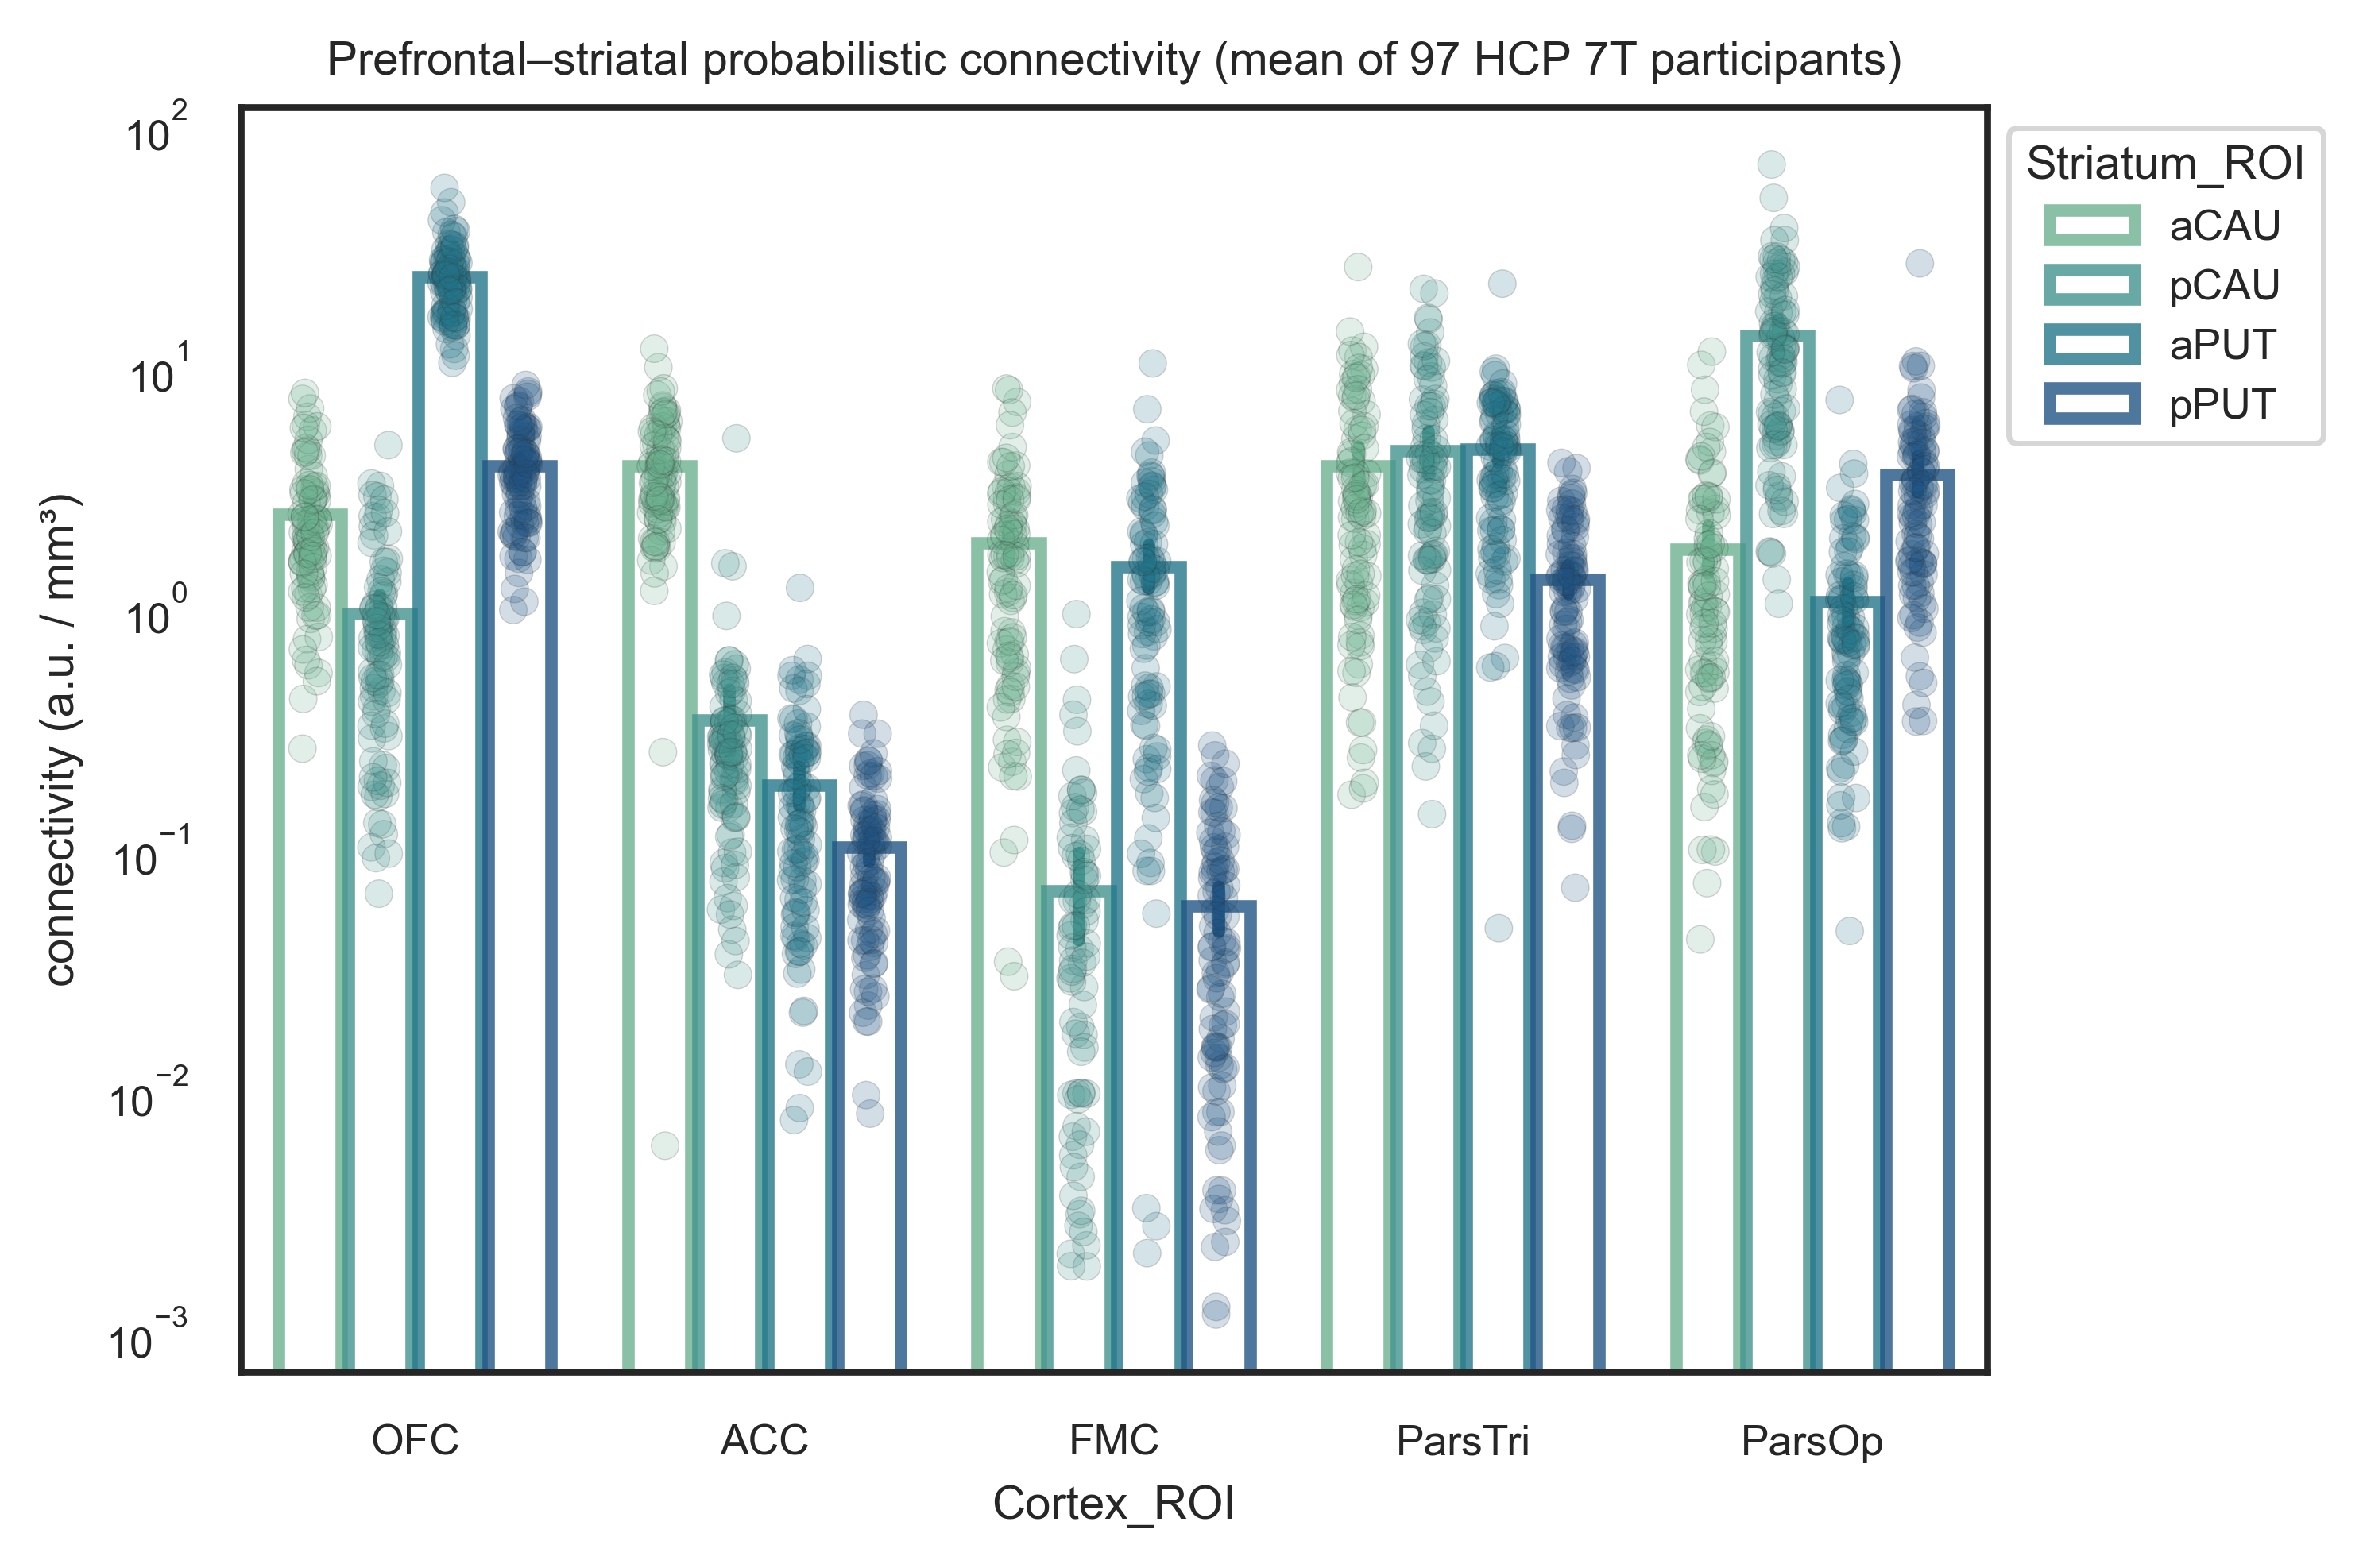

In [210]:
pfc_df = net_df[net_df['Cortex_Category'] == 'Prefrontal']

df_collapsed_pfc = pfc_df.groupby(['participant_id', 'Cortex_ROI', 'Striatum_ROI'],
                                   as_index=False).agg({'Connectivity': 'mean'})

fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=500)

sns.barplot(data=df_collapsed_pfc,
            x='Cortex_ROI', y='Connectivity',
            order=PREFRONTAL_ROIS,
            hue='Striatum_ROI', hue_order=['aCAU', 'pCAU', 'aPUT', 'pPUT'],
            palette='crest',
            alpha=0.8, gap=0.1, fill=False,
            ax=ax)
sns.stripplot(data=df_collapsed_pfc,
              x='Cortex_ROI', y='Connectivity',
              order=PREFRONTAL_ROIS,
              hue='Striatum_ROI', hue_order=['aCAU', 'pCAU', 'aPUT', 'pPUT'],
              palette='crest',
              dodge=True, jitter=True,
              linewidth=0.2, alpha=0.2,
              legend=None,
              ax=ax)

ax.set_xticklabels([_display_label(r) for r in PREFRONTAL_ROIS])
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1))
ax.set_title(f'Prefrontal–striatal probabilistic connectivity (mean of {num_participants} HCP 7T participants)')
plt.yscale('log')
ax.set_ylabel('connectivity (a.u. / mm³)')

fig.savefig(os.path.join(FIGURES_DIR, 'streamline-count_x-prefrontal_hue-striatum.svg'))
fig.tight_layout()


### PFC statistics

In [211]:
pfc_long_df = all_long_df[all_long_df['Cortex_ROI'].isin(PREFRONTAL_ROIS)]


#### All factors

In [212]:
aov = AnovaRM(pfc_long_df,
              aggregate_func='mean',
              depvar='Connectivity',
              subject='participant_id',
              within=['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI', 'hemisphere']).fit()
aov.summary()
export_anova(aov, 'pfc_full', STATS_OUT_DIR)


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Caudate_Putamen,11.85,1.0,96.0,p < .001,,,,"F(1, 96) = 11.85, p < .001"
1,Rostral_Caudal,142.02,1.0,96.0,p < .001,,,,"F(1, 96) = 142.02, p < .001"
2,Cortex_ROI,192.09,4.0,384.0,p < .001,,,,"F(4, 384) = 192.09, p < .001"
3,hemisphere,162.47,1.0,96.0,p < .001,,,,"F(1, 96) = 162.47, p < .001"
4,Caudate_Putamen:Rostral_Caudal,349.20,1.0,96.0,p < .001,,,,"F(1, 96) = 349.20, p < .001"
5,Caudate_Putamen:Cortex_ROI,404.51,4.0,384.0,p < .001,,,,"F(4, 384) = 404.51, p < .001"
6,Rostral_Caudal:Cortex_ROI,362.76,4.0,384.0,p < .001,,,,"F(4, 384) = 362.76, p < .001"
7,Caudate_Putamen:hemisphere,79.16,1.0,96.0,p < .001,,,,"F(1, 96) = 79.16, p < .001"
8,Rostral_Caudal:hemisphere,100.94,1.0,96.0,p < .001,,,,"F(1, 96) = 100.94, p < .001"
9,Cortex_ROI:hemisphere,78.60,4.0,384.0,p < .001,,,,"F(4, 384) = 78.60, p < .001"


#### No hemisphere

In [213]:
aov = AnovaRM(pfc_long_df,
              aggregate_func='mean',
              depvar='Connectivity',
              subject='participant_id',
              within=['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI']).fit()
aov.summary()
export_anova(aov, 'pfc_cau_rostral_roi', STATS_OUT_DIR)


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Caudate_Putamen,11.85,1.0,96.0,p < .001,,,,"F(1, 96) = 11.85, p < .001"
1,Rostral_Caudal,142.02,1.0,96.0,p < .001,,,,"F(1, 96) = 142.02, p < .001"
2,Cortex_ROI,192.09,4.0,384.0,p < .001,,,,"F(4, 384) = 192.09, p < .001"
3,Caudate_Putamen:Rostral_Caudal,349.20,1.0,96.0,p < .001,,,,"F(1, 96) = 349.20, p < .001"
4,Caudate_Putamen:Cortex_ROI,404.51,4.0,384.0,p < .001,,,,"F(4, 384) = 404.51, p < .001"
5,Rostral_Caudal:Cortex_ROI,362.76,4.0,384.0,p < .001,,,,"F(4, 384) = 362.76, p < .001"
6,Caudate_Putamen:Rostral_Caudal:Cortex_ROI,226.07,4.0,384.0,p < .001,,,,"F(4, 384) = 226.07, p < .001"


#### Caudate–Putamen

In [214]:
aov = AnovaRM(pfc_long_df,
              aggregate_func='mean',
              depvar='Connectivity',
              subject='participant_id',
              within=['Caudate_Putamen', 'Cortex_ROI', 'hemisphere']).fit()
aov.summary()
export_anova(aov, 'pfc_cau_roi_hemi', STATS_OUT_DIR)


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Caudate_Putamen,11.85,1.0,96.0,p < .001,,,,"F(1, 96) = 11.85, p < .001"
1,Cortex_ROI,192.09,4.0,384.0,p < .001,,,,"F(4, 384) = 192.09, p < .001"
2,hemisphere,162.47,1.0,96.0,p < .001,,,,"F(1, 96) = 162.47, p < .001"
3,Caudate_Putamen:Cortex_ROI,404.51,4.0,384.0,p < .001,,,,"F(4, 384) = 404.51, p < .001"
4,Caudate_Putamen:hemisphere,79.16,1.0,96.0,p < .001,,,,"F(1, 96) = 79.16, p < .001"
5,Cortex_ROI:hemisphere,78.60,4.0,384.0,p < .001,,,,"F(4, 384) = 78.60, p < .001"
6,Caudate_Putamen:Cortex_ROI:hemisphere,125.03,4.0,384.0,p < .001,,,,"F(4, 384) = 125.03, p < .001"


##### 2-way: Cortex ROI x Caudate/Putamen

In [215]:
# 2-way RM-ANOVA (Greenhouse-Geisser + partial eta^2): the omnibus that the
# pairwise comparisons below follow up. Average over the other factors so
# there is one value per subject x cell.
_d = pfc_long_df.groupby(['participant_id', 'Cortex_ROI', 'Caudate_Putamen'],
                     as_index=False)['Connectivity'].mean()
aov = pg.rm_anova(data=_d, dv='Connectivity',
                  within=['Cortex_ROI', 'Caudate_Putamen'],
                  subject='participant_id', detailed=True, effsize='np2')
display(aov)
export_anova(aov, 'pfc_roi_cau', STATS_OUT_DIR)


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,np2,eps
0,Cortex_ROI,6419.294070,4,384,1604.823517,192.090667,3.000059e-90,4.960105e-52,0.666772,0.562722
1,Caudate_Putamen,111.379558,1,96,111.379558,11.854291,8.539875e-04,8.539875e-04,0.109910,1.000000
2,Cortex_ROI * Caudate_Putamen,8725.090748,4,384,2181.272687,404.506783,3.183977e-136,8.560617e-78,0.808194,0.561642


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Cortex_ROI,192.09,4,384,p < .001,p < .001,0.667,0.563,"F(2.25, 216.09) = 192.09, p < .001 (GG ε=0.56)..."
1,Caudate_Putamen,11.85,1,96,p < .001,p < .001,0.110,1.000,"F(1, 96) = 11.85, p < .001, ηp² = .11"
2,Cortex_ROI * Caudate_Putamen,404.51,4,384,p < .001,p < .001,0.808,0.562,"F(2.25, 215.67) = 404.51, p < .001 (GG ε=0.56)..."


In [216]:
# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=pfc_long_df,
                             dv='Connectivity',
                             within=['Caudate_Putamen', 'Cortex_ROI'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)

print('Available columns:', pairwise.columns)
print('\nPost-hoc Pairwise Comparisons:')
pd.set_option('display.max_rows', None)

pairwise[['Contrast', 'Caudate_Putamen', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_df = pairwise.copy()
for col in ('A', 'B', 'Cortex_ROI'):
    if col in export_df.columns:
        export_df[col] = export_df[col].replace(ROI_DISPLAY_NAMES)
export_posthoc(export_df, 'pfc_cau_roi', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Caudate_Putamen', 'A', 'B', 'Paired', 'Parametric',
       'W_val', 'alternative', 'p_unc', 'p_corr', 'p_adjust', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Caudate_Putamen,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Caudate_Putamen,-,Caudate,Putamen,1284.0,p < .001,n/a,"W = 1284.0, p < .001",W = 1284.0
1,Cortex_ROI,-,ACC,FMC,1099.0,p < .001,p < .001,"W = 1099.0, p < .001","W = 1099.0, q < .001"
2,Cortex_ROI,-,ACC,ParsOp,35.0,p < .001,p < .001,"W = 35.0, p < .001","W = 35.0, q < .001"
3,Cortex_ROI,-,ACC,ParsTri,223.0,p < .001,p < .001,"W = 223.0, p < .001","W = 223.0, q < .001"
4,Cortex_ROI,-,ACC,OFC,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
5,Cortex_ROI,-,FMC,ParsOp,30.0,p < .001,p < .001,"W = 30.0, p < .001","W = 30.0, q < .001"
6,Cortex_ROI,-,FMC,ParsTri,138.0,p < .001,p < .001,"W = 138.0, p < .001","W = 138.0, q < .001"
7,Cortex_ROI,-,FMC,OFC,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
8,Cortex_ROI,-,ParsOp,ParsTri,787.0,p < .001,p < .001,"W = 787.0, p < .001","W = 787.0, q < .001"
9,Cortex_ROI,-,ParsOp,OFC,621.0,p < .001,p < .001,"W = 621.0, p < .001","W = 621.0, q < .001"


In [217]:
# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=pfc_long_df,
                             dv='Connectivity',
                             within=['Cortex_ROI', 'Caudate_Putamen'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)

print('Available columns:', pairwise.columns)
print('\nPost-hoc Pairwise Comparisons:')
pd.set_option('display.max_rows', None)

pairwise[['Contrast', 'Cortex_ROI', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_df = pairwise.copy()
for col in ('A', 'B', 'Cortex_ROI'):
    if col in export_df.columns:
        export_df[col] = export_df[col].replace(ROI_DISPLAY_NAMES)
export_posthoc(export_df, 'pfc_roi_cau', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'W_val',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Cortex_ROI,-,ACC,FMC,1099.0,p < .001,p < .001,"W = 1099.0, p < .001","W = 1099.0, q < .001"
1,Cortex_ROI,-,ACC,ParsOp,35.0,p < .001,p < .001,"W = 35.0, p < .001","W = 35.0, q < .001"
2,Cortex_ROI,-,ACC,ParsTri,223.0,p < .001,p < .001,"W = 223.0, p < .001","W = 223.0, q < .001"
3,Cortex_ROI,-,ACC,OFC,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
4,Cortex_ROI,-,FMC,ParsOp,30.0,p < .001,p < .001,"W = 30.0, p < .001","W = 30.0, q < .001"
5,Cortex_ROI,-,FMC,ParsTri,138.0,p < .001,p < .001,"W = 138.0, p < .001","W = 138.0, q < .001"
6,Cortex_ROI,-,FMC,OFC,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
7,Cortex_ROI,-,ParsOp,ParsTri,787.0,p < .001,p < .001,"W = 787.0, p < .001","W = 787.0, q < .001"
8,Cortex_ROI,-,ParsOp,OFC,621.0,p < .001,p < .001,"W = 621.0, p < .001","W = 621.0, q < .001"
9,Cortex_ROI,-,ParsTri,OFC,187.0,p < .001,p < .001,"W = 187.0, p < .001","W = 187.0, q < .001"


In [218]:
pairwise = pg.pairwise_tests(data=pfc_long_df,
                             dv='Connectivity',
                             within=['hemisphere', 'Cortex_ROI'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'hemisphere', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_posthoc(pairwise, 'pfc_hemi_roi', STATS_OUT_DIR)


,Contrast,hemisphere,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,hemisphere,-,Left,Right,160.0,p < .001,n/a,"W = 160.0, p < .001",W = 160.0
1,Cortex_ROI,-,ACC,FMC,1099.0,p < .001,p < .001,"W = 1099.0, p < .001","W = 1099.0, q < .001"
2,Cortex_ROI,-,ACC,IFGo,35.0,p < .001,p < .001,"W = 35.0, p < .001","W = 35.0, q < .001"
3,Cortex_ROI,-,ACC,IFGt,223.0,p < .001,p < .001,"W = 223.0, p < .001","W = 223.0, q < .001"
4,Cortex_ROI,-,ACC,OFC,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
5,Cortex_ROI,-,FMC,IFGo,30.0,p < .001,p < .001,"W = 30.0, p < .001","W = 30.0, q < .001"
6,Cortex_ROI,-,FMC,IFGt,138.0,p < .001,p < .001,"W = 138.0, p < .001","W = 138.0, q < .001"
7,Cortex_ROI,-,FMC,OFC,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
8,Cortex_ROI,-,IFGo,IFGt,787.0,p < .001,p < .001,"W = 787.0, p < .001","W = 787.0, q < .001"
9,Cortex_ROI,-,IFGo,OFC,621.0,p < .001,p < .001,"W = 621.0, p < .001","W = 621.0, q < .001"


In [219]:
pairwise = pg.pairwise_tests(data=pfc_long_df,
                             dv='Connectivity',
                             within=['Cortex_ROI', 'hemisphere'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'Cortex_ROI', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_posthoc(pairwise, 'pfc_roi_hemi', STATS_OUT_DIR)


,Contrast,Cortex_ROI,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Cortex_ROI,-,ACC,FMC,1099.0,p < .001,p < .001,"W = 1099.0, p < .001","W = 1099.0, q < .001"
1,Cortex_ROI,-,ACC,IFGo,35.0,p < .001,p < .001,"W = 35.0, p < .001","W = 35.0, q < .001"
2,Cortex_ROI,-,ACC,IFGt,223.0,p < .001,p < .001,"W = 223.0, p < .001","W = 223.0, q < .001"
3,Cortex_ROI,-,ACC,OFC,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
4,Cortex_ROI,-,FMC,IFGo,30.0,p < .001,p < .001,"W = 30.0, p < .001","W = 30.0, q < .001"
5,Cortex_ROI,-,FMC,IFGt,138.0,p < .001,p < .001,"W = 138.0, p < .001","W = 138.0, q < .001"
6,Cortex_ROI,-,FMC,OFC,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
7,Cortex_ROI,-,IFGo,IFGt,787.0,p < .001,p < .001,"W = 787.0, p < .001","W = 787.0, q < .001"
8,Cortex_ROI,-,IFGo,OFC,621.0,p < .001,p < .001,"W = 621.0, p < .001","W = 621.0, q < .001"
9,Cortex_ROI,-,IFGt,OFC,187.0,p < .001,p < .001,"W = 187.0, p < .001","W = 187.0, q < .001"


In [220]:
pairwise = pg.pairwise_tests(data=pfc_long_df,
                             dv='Connectivity',
                             within=['Striatum_ROI', 'hemisphere'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'Striatum_ROI', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_posthoc(pairwise, 'pfc_striatum_hemi', STATS_OUT_DIR)


,Contrast,Striatum_ROI,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Striatum_ROI,-,aCAU,aPUT,35.0,p < .001,p < .001,"W = 35.0, p < .001","W = 35.0, q < .001"
1,Striatum_ROI,-,aCAU,pCAU,1255.0,p < .001,p < .001,"W = 1255.0, p < .001","W = 1255.0, q < .001"
2,Striatum_ROI,-,aCAU,pPUT,601.0,p < .001,p < .001,"W = 601.0, p < .001","W = 601.0, q < .001"
3,Striatum_ROI,-,aPUT,pCAU,659.0,p < .001,p < .001,"W = 659.0, p < .001","W = 659.0, q < .001"
4,Striatum_ROI,-,aPUT,pPUT,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
5,Striatum_ROI,-,pCAU,pPUT,446.0,p < .001,p < .001,"W = 446.0, p < .001","W = 446.0, q < .001"
6,hemisphere,-,Left,Right,160.0,p < .001,n/a,"W = 160.0, p < .001",W = 160.0
7,Striatum_ROI * hemisphere,aCAU,Left,Right,797.0,p < .001,p < .001,"W = 797.0, p < .001","W = 797.0, q < .001"
8,Striatum_ROI * hemisphere,aPUT,Left,Right,7.0,p < .001,p < .001,"W = 7.0, p < .001","W = 7.0, q < .001"
9,Striatum_ROI * hemisphere,pCAU,Left,Right,1371.0,p < .001,p < .001,"W = 1371.0, p < .001","W = 1371.0, q < .001"


#### Rostral–caudal

In [221]:
aov = AnovaRM(pfc_long_df,
              aggregate_func='mean',
              depvar='Connectivity',
              subject='participant_id',
              within=['Rostral_Caudal', 'hemisphere', 'Cortex_ROI']).fit()
aov.summary()
export_anova(aov, 'pfc_rostral_hemi_roi', STATS_OUT_DIR)


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Rostral_Caudal,142.02,1.0,96.0,p < .001,,,,"F(1, 96) = 142.02, p < .001"
1,hemisphere,162.47,1.0,96.0,p < .001,,,,"F(1, 96) = 162.47, p < .001"
2,Cortex_ROI,192.09,4.0,384.0,p < .001,,,,"F(4, 384) = 192.09, p < .001"
3,Rostral_Caudal:hemisphere,100.94,1.0,96.0,p < .001,,,,"F(1, 96) = 100.94, p < .001"
4,Rostral_Caudal:Cortex_ROI,362.76,4.0,384.0,p < .001,,,,"F(4, 384) = 362.76, p < .001"
5,hemisphere:Cortex_ROI,78.60,4.0,384.0,p < .001,,,,"F(4, 384) = 78.60, p < .001"
6,Rostral_Caudal:hemisphere:Cortex_ROI,137.41,4.0,384.0,p < .001,,,,"F(4, 384) = 137.41, p < .001"


##### 2-way: Cortex ROI x Rostral/Caudal

In [222]:
# 2-way RM-ANOVA (Greenhouse-Geisser + partial eta^2): the omnibus that the
# pairwise comparisons below follow up. Average over the other factors so
# there is one value per subject x cell.
_d = pfc_long_df.groupby(['participant_id', 'Cortex_ROI', 'Rostral_Caudal'],
                     as_index=False)['Connectivity'].mean()
aov = pg.rm_anova(data=_d, dv='Connectivity',
                  within=['Cortex_ROI', 'Rostral_Caudal'],
                  subject='participant_id', detailed=True, effsize='np2')
display(aov)
export_anova(aov, 'pfc_roi_rostral', STATS_OUT_DIR)


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,np2,eps
0,Cortex_ROI,6419.294070,4,384,1604.823517,192.090667,3.000059e-90,4.960105e-52,0.666772,0.562722
1,Rostral_Caudal,670.763547,1,96,670.763547,142.020213,1.231441e-20,1.231441e-20,0.596673,1.000000
2,Cortex_ROI * Rostral_Caudal,7784.492855,4,384,1946.123214,362.760142,5.699186e-129,1.215375e-62,0.790740,0.473853


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Cortex_ROI,192.09,4,384,p < .001,p < .001,0.667,0.563,"F(2.25, 216.09) = 192.09, p < .001 (GG ε=0.56)..."
1,Rostral_Caudal,142.02,1,96,p < .001,p < .001,0.597,1.000,"F(1, 96) = 142.02, p < .001, ηp² = .60"
2,Cortex_ROI * Rostral_Caudal,362.76,4,384,p < .001,p < .001,0.791,0.474,"F(1.90, 181.96) = 362.76, p < .001 (GG ε=0.47)..."


In [223]:
pairwise = pg.pairwise_tests(data=pfc_long_df,
                             dv='Connectivity',
                             within=['hemisphere', 'Rostral_Caudal'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'hemisphere', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_posthoc(pairwise, 'pfc_hemi_rostral', STATS_OUT_DIR)


,Contrast,hemisphere,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,hemisphere,-,Left,Right,160.0,p < .001,n/a,"W = 160.0, p < .001",W = 160.0
1,Rostral_Caudal,-,Caudal,Rostral,236.0,p < .001,n/a,"W = 236.0, p < .001",W = 236.0
2,hemisphere * Rostral_Caudal,Left,Caudal,Rostral,92.0,p < .001,p < .001,"W = 92.0, p < .001","W = 92.0, q < .001"
3,hemisphere * Rostral_Caudal,Right,Caudal,Rostral,1433.0,p < .001,p < .001,"W = 1433.0, p < .001","W = 1433.0, q < .001"


In [224]:
pairwise = pg.pairwise_tests(data=pfc_long_df,
                             dv='Connectivity',
                             within=['Rostral_Caudal', 'hemisphere'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'Rostral_Caudal', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_posthoc(pairwise, 'pfc_rostral_hemi', STATS_OUT_DIR)


,Contrast,Rostral_Caudal,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Rostral_Caudal,-,Caudal,Rostral,236.0,p < .001,n/a,"W = 236.0, p < .001",W = 236.0
1,hemisphere,-,Left,Right,160.0,p < .001,n/a,"W = 160.0, p < .001",W = 160.0
2,Rostral_Caudal * hemisphere,Caudal,Left,Right,1128.0,p < .001,p < .001,"W = 1128.0, p < .001","W = 1128.0, q < .001"
3,Rostral_Caudal * hemisphere,Rostral,Left,Right,2.0,p < .001,p < .001,"W = 2.0, p < .001","W = 2.0, q < .001"


In [225]:
# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=pfc_long_df,
                             dv='Connectivity',
                             within=['Cortex_ROI', 'Rostral_Caudal'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)

print('Available columns:', pairwise.columns)
print('\nPost-hoc Pairwise Comparisons:')
pd.set_option('display.max_rows', None)

pairwise[['Contrast', 'Cortex_ROI', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_df = pairwise.copy()
for col in ('A', 'B', 'Cortex_ROI'):
    if col in export_df.columns:
        export_df[col] = export_df[col].replace(ROI_DISPLAY_NAMES)
export_posthoc(export_df, 'pfc_roi_rostral', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'W_val',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Cortex_ROI,-,ACC,FMC,1099.0,p < .001,p < .001,"W = 1099.0, p < .001","W = 1099.0, q < .001"
1,Cortex_ROI,-,ACC,ParsOp,35.0,p < .001,p < .001,"W = 35.0, p < .001","W = 35.0, q < .001"
2,Cortex_ROI,-,ACC,ParsTri,223.0,p < .001,p < .001,"W = 223.0, p < .001","W = 223.0, q < .001"
3,Cortex_ROI,-,ACC,OFC,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
4,Cortex_ROI,-,FMC,ParsOp,30.0,p < .001,p < .001,"W = 30.0, p < .001","W = 30.0, q < .001"
5,Cortex_ROI,-,FMC,ParsTri,138.0,p < .001,p < .001,"W = 138.0, p < .001","W = 138.0, q < .001"
6,Cortex_ROI,-,FMC,OFC,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
7,Cortex_ROI,-,ParsOp,ParsTri,787.0,p < .001,p < .001,"W = 787.0, p < .001","W = 787.0, q < .001"
8,Cortex_ROI,-,ParsOp,OFC,621.0,p < .001,p < .001,"W = 621.0, p < .001","W = 621.0, q < .001"
9,Cortex_ROI,-,ParsTri,OFC,187.0,p < .001,p < .001,"W = 187.0, p < .001","W = 187.0, q < .001"


### Visual statistics

In [226]:
vis_long_df = all_long_df[all_long_df['Cortex_ROI'].isin(VISUAL_ROIS)]

#### Group-mean plot

/var/folders/5c/_fg_mvnx2dv1jhkw5xg5fv1h0000gq/T/ipykernel_35227/1085957468.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_display_label(r) for r in VISUAL_ROIS])


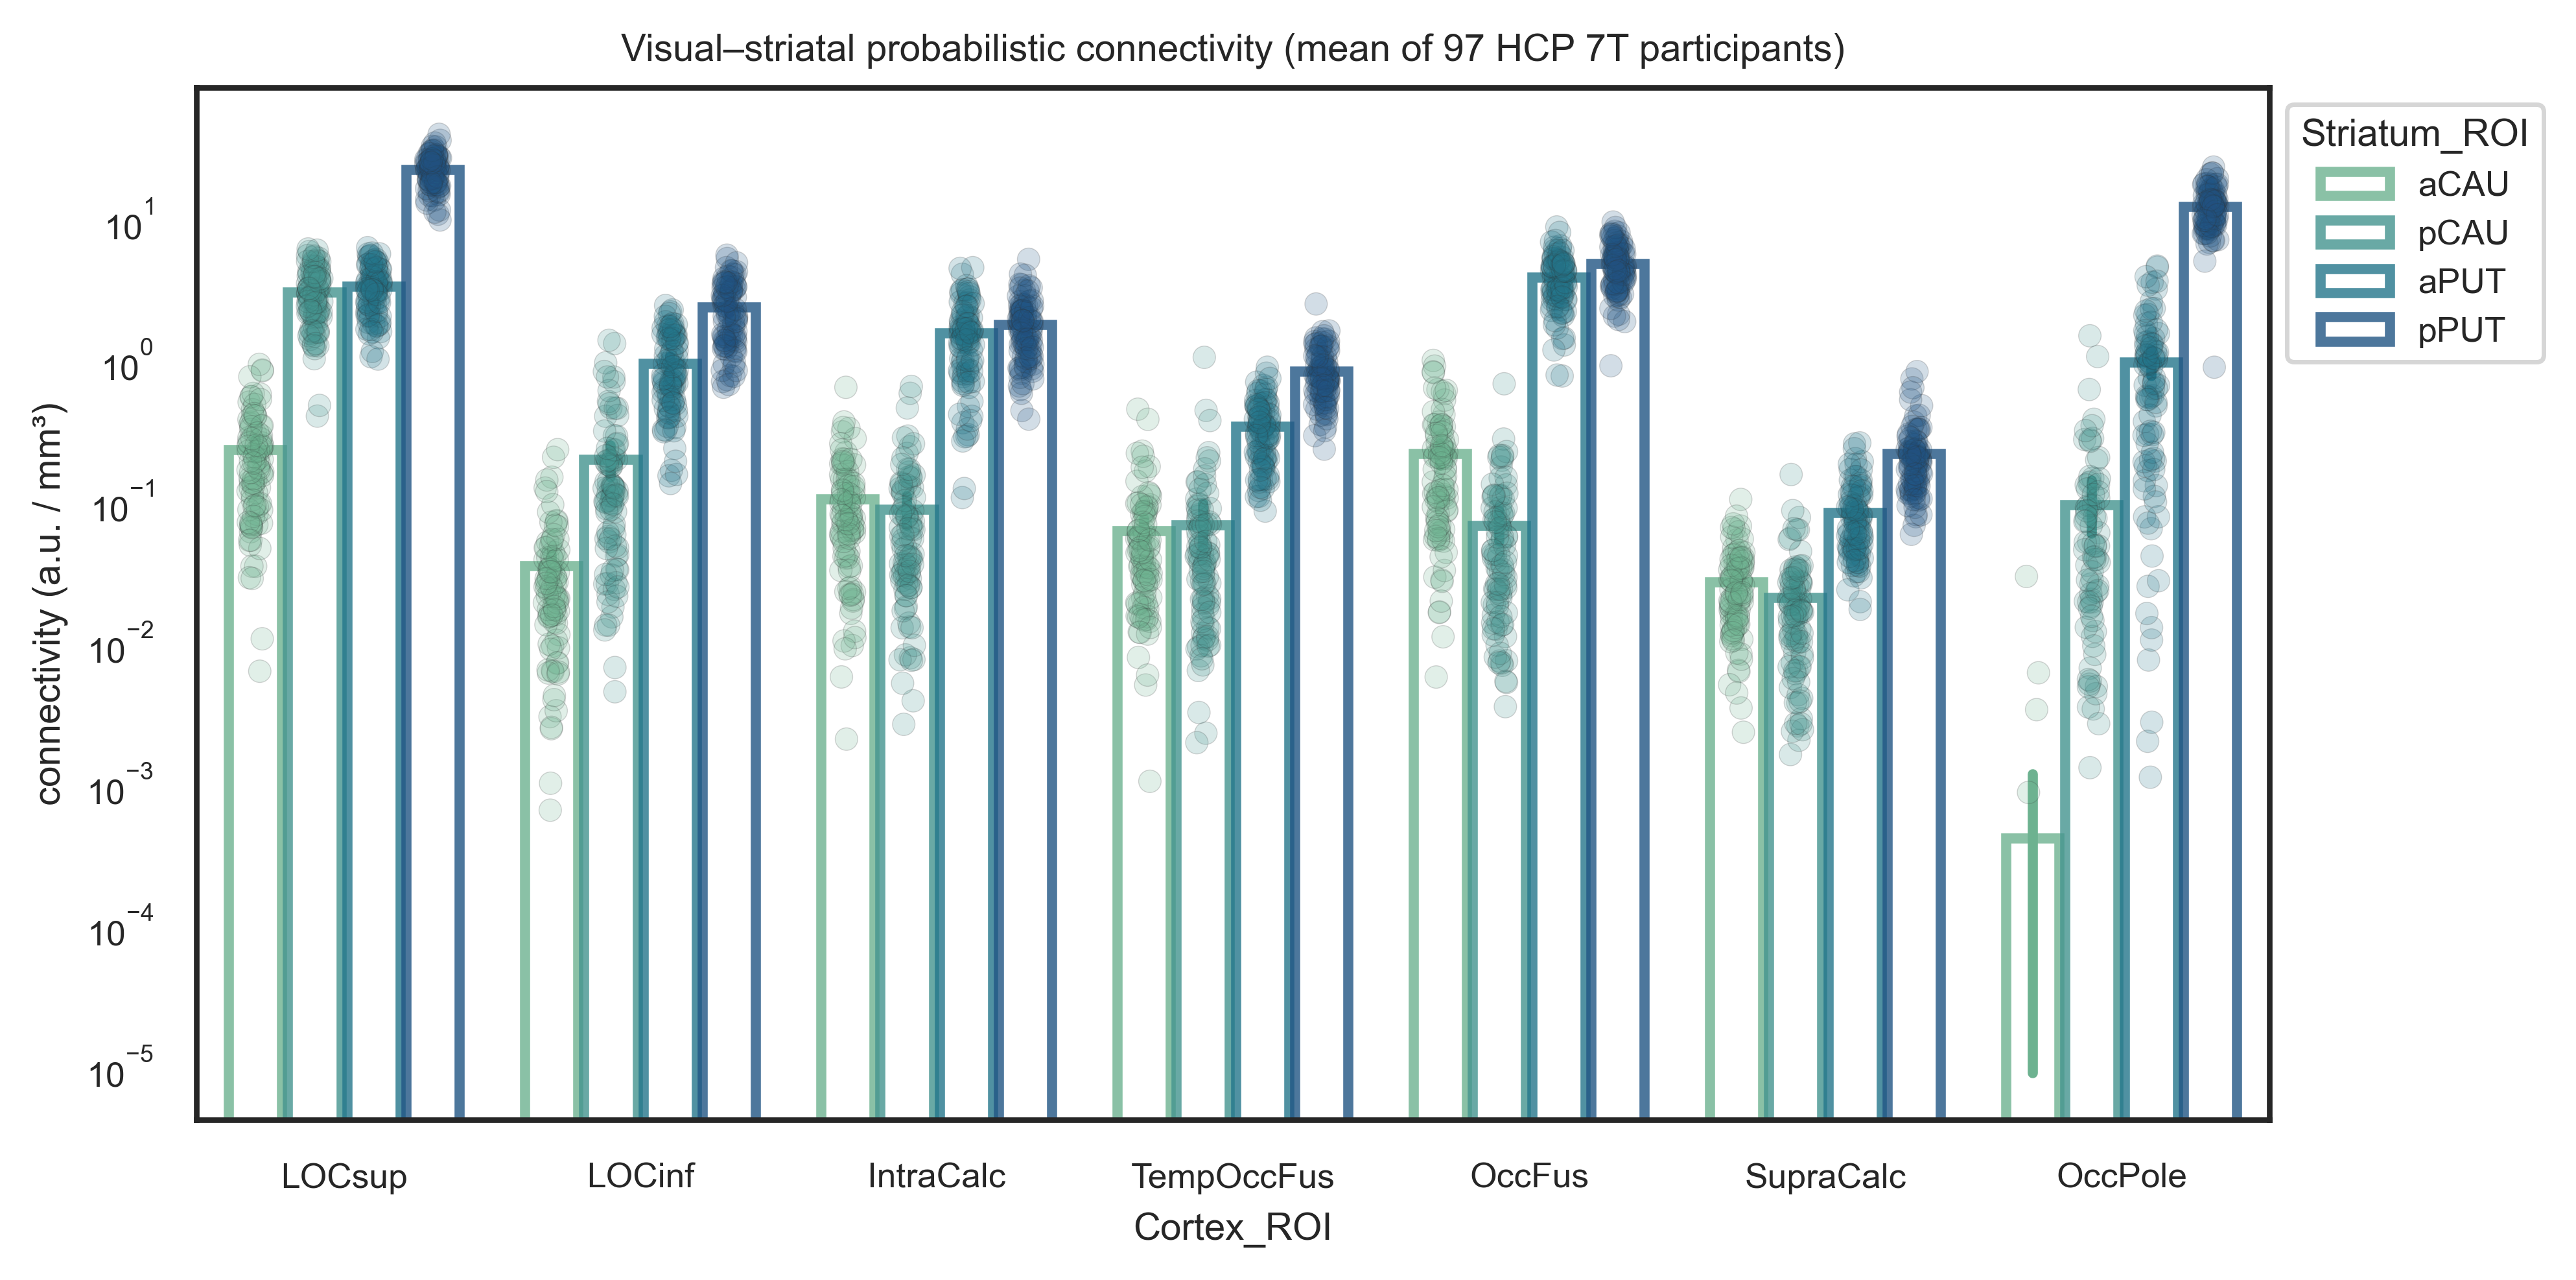

In [227]:
df_collapsed_vis = vis_long_df.groupby(['participant_id', 'Cortex_ROI', 'Striatum_ROI'],
                                        as_index=False).agg({'Connectivity': 'mean'})

fig, ax = plt.subplots(1, 1, figsize=(8, 4), dpi=500)

sns.barplot(data=df_collapsed_vis,
            x='Cortex_ROI', y='Connectivity',
            order=VISUAL_ROIS,
            hue='Striatum_ROI', hue_order=['aCAU', 'pCAU', 'aPUT', 'pPUT'],
            palette='crest',
            alpha=0.8, gap=0.1, fill=False,
            ax=ax)
sns.stripplot(data=df_collapsed_vis,
              x='Cortex_ROI', y='Connectivity',
              order=VISUAL_ROIS,
              hue='Striatum_ROI', hue_order=['aCAU', 'pCAU', 'aPUT', 'pPUT'],
              palette='crest',
              dodge=True, jitter=True,
              linewidth=0.2, alpha=0.2,
              legend=None,
              ax=ax)

ax.set_xticklabels([_display_label(r) for r in VISUAL_ROIS])
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1))
ax.set_title(f'Visual–striatal probabilistic connectivity (mean of {num_participants} HCP 7T participants)')
plt.yscale('log')
ax.set_ylabel('connectivity (a.u. / mm³)')

fig.savefig(os.path.join(FIGURES_DIR, 'streamline-count_x-visual_hue-striatum.svg'))
fig.tight_layout()


#### All factors

In [228]:
aov = AnovaRM(vis_long_df,
              aggregate_func='mean',
              depvar='Connectivity',
              subject='participant_id',
              within=['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI', 'hemisphere']).fit()
aov.summary()
export_anova(aov, 'vis_full', STATS_OUT_DIR)


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Caudate_Putamen,2553.99,1.0,96.0,p < .001,,,,"F(1, 96) = 2553.99, p < .001"
1,Rostral_Caudal,1475.64,1.0,96.0,p < .001,,,,"F(1, 96) = 1475.64, p < .001"
2,Cortex_ROI,979.36,6.0,576.0,p < .001,,,,"F(6, 576) = 979.36, p < .001"
3,hemisphere,26.31,1.0,96.0,p < .001,,,,"F(1, 96) = 26.31, p < .001"
4,Caudate_Putamen:Rostral_Caudal,1225.36,1.0,96.0,p < .001,,,,"F(1, 96) = 1225.36, p < .001"
5,Caudate_Putamen:Cortex_ROI,784.89,6.0,576.0,p < .001,,,,"F(6, 576) = 784.89, p < .001"
6,Rostral_Caudal:Cortex_ROI,893.25,6.0,576.0,p < .001,,,,"F(6, 576) = 893.25, p < .001"
7,Caudate_Putamen:hemisphere,44.97,1.0,96.0,p < .001,,,,"F(1, 96) = 44.97, p < .001"
8,Rostral_Caudal:hemisphere,0.38,1.0,96.0,p = .538,,,,"F(1, 96) = 0.38, p = .538"
9,Cortex_ROI:hemisphere,17.47,6.0,576.0,p < .001,,,,"F(6, 576) = 17.47, p < .001"


#### No hemisphere

In [229]:
aov = AnovaRM(vis_long_df,
              aggregate_func='mean',
              depvar='Connectivity',
              subject='participant_id',
              within=['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI']).fit()
aov.summary()
export_anova(aov, 'vis_cau_rostral_roi', STATS_OUT_DIR)


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Caudate_Putamen,2553.99,1.0,96.0,p < .001,,,,"F(1, 96) = 2553.99, p < .001"
1,Rostral_Caudal,1475.64,1.0,96.0,p < .001,,,,"F(1, 96) = 1475.64, p < .001"
2,Cortex_ROI,979.36,6.0,576.0,p < .001,,,,"F(6, 576) = 979.36, p < .001"
3,Caudate_Putamen:Rostral_Caudal,1225.36,1.0,96.0,p < .001,,,,"F(1, 96) = 1225.36, p < .001"
4,Caudate_Putamen:Cortex_ROI,784.89,6.0,576.0,p < .001,,,,"F(6, 576) = 784.89, p < .001"
5,Rostral_Caudal:Cortex_ROI,893.25,6.0,576.0,p < .001,,,,"F(6, 576) = 893.25, p < .001"
6,Caudate_Putamen:Rostral_Caudal:Cortex_ROI,712.51,6.0,576.0,p < .001,,,,"F(6, 576) = 712.51, p < .001"


#### Caudate–Putamen

In [230]:
aov = AnovaRM(vis_long_df,
              aggregate_func='mean',
              depvar='Connectivity',
              subject='participant_id',
              within=['Caudate_Putamen', 'Cortex_ROI', 'hemisphere']).fit()
aov.summary()
export_anova(aov, 'vis_cau_roi_hemi', STATS_OUT_DIR)


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Caudate_Putamen,2553.99,1.0,96.0,p < .001,,,,"F(1, 96) = 2553.99, p < .001"
1,Cortex_ROI,979.36,6.0,576.0,p < .001,,,,"F(6, 576) = 979.36, p < .001"
2,hemisphere,26.31,1.0,96.0,p < .001,,,,"F(1, 96) = 26.31, p < .001"
3,Caudate_Putamen:Cortex_ROI,784.89,6.0,576.0,p < .001,,,,"F(6, 576) = 784.89, p < .001"
4,Caudate_Putamen:hemisphere,44.97,1.0,96.0,p < .001,,,,"F(1, 96) = 44.97, p < .001"
5,Cortex_ROI:hemisphere,17.47,6.0,576.0,p < .001,,,,"F(6, 576) = 17.47, p < .001"
6,Caudate_Putamen:Cortex_ROI:hemisphere,24.95,6.0,576.0,p < .001,,,,"F(6, 576) = 24.95, p < .001"


##### 2-way: Cortex ROI x Caudate/Putamen

In [231]:
# 2-way RM-ANOVA (Greenhouse-Geisser + partial eta^2): the omnibus that the
# pairwise comparisons below follow up. Average over the other factors so
# there is one value per subject x cell.
_d = vis_long_df.groupby(['participant_id', 'Cortex_ROI', 'Caudate_Putamen'],
                     as_index=False)['Connectivity'].mean()
aov = pg.rm_anova(data=_d, dv='Connectivity',
                  within=['Cortex_ROI', 'Caudate_Putamen'],
                  subject='participant_id', detailed=True, effsize='np2')
display(aov)
export_anova(aov, 'vis_roi_cau', STATS_OUT_DIR)


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,np2,eps
0,Cortex_ROI,7593.600014,6,576,1265.600002,979.363776,2.225855e-298,1.716601e-115,0.910728,0.380813
1,Caudate_Putamen,4717.685410,1,96,4717.685410,2553.991139,5.633866e-71,5.633866e-71,0.963773,1.000000
2,Cortex_ROI * Caudate_Putamen,4825.332221,6,576,804.222037,784.886357,1.903688e-273,9.560449e-118,0.891019,0.424251


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Cortex_ROI,979.36,6,576,p < .001,p < .001,0.911,0.381,"F(2.28, 219.35) = 979.36, p < .001 (GG ε=0.38)..."
1,Caudate_Putamen,2553.99,1,96,p < .001,p < .001,0.964,1.000,"F(1, 96) = 2553.99, p < .001, ηp² = .96"
2,Cortex_ROI * Caudate_Putamen,784.89,6,576,p < .001,p < .001,0.891,0.424,"F(2.55, 244.37) = 784.89, p < .001 (GG ε=0.42)..."


In [232]:
# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=vis_long_df,
                             dv='Connectivity',
                             within=['Caudate_Putamen', 'Cortex_ROI'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)

print('Available columns:', pairwise.columns)
print('\nPost-hoc Pairwise Comparisons:')
pd.set_option('display.max_rows', None)

pairwise[['Contrast', 'Caudate_Putamen', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_df = pairwise.copy()
for col in ('A', 'B', 'Cortex_ROI'):
    if col in export_df.columns:
        export_df[col] = export_df[col].replace(ROI_DISPLAY_NAMES)
export_posthoc(export_df, 'vis_cau_roi', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Caudate_Putamen', 'A', 'B', 'Paired', 'Parametric',
       'W_val', 'alternative', 'p_unc', 'p_corr', 'p_adjust', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Caudate_Putamen,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Caudate_Putamen,-,Caudate,Putamen,0.0,p < .001,n/a,"W = 0.0, p < .001",W = 0.0
1,Cortex_ROI,-,IntraCalc,LOCinf,2266.0,p = .692,p = .692,"W = 2266.0, p = .692","W = 2266.0, q = .692"
2,Cortex_ROI,-,IntraCalc,LOCsup,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
3,Cortex_ROI,-,IntraCalc,OccFus,36.0,p < .001,p < .001,"W = 36.0, p < .001","W = 36.0, q < .001"
4,Cortex_ROI,-,IntraCalc,OccPole,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
5,Cortex_ROI,-,IntraCalc,SupraCalc,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
6,Cortex_ROI,-,IntraCalc,TempOccFus,87.0,p < .001,p < .001,"W = 87.0, p < .001","W = 87.0, q < .001"
7,Cortex_ROI,-,LOCinf,LOCsup,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
8,Cortex_ROI,-,LOCinf,OccFus,7.0,p < .001,p < .001,"W = 7.0, p < .001","W = 7.0, q < .001"
9,Cortex_ROI,-,LOCinf,OccPole,2.0,p < .001,p < .001,"W = 2.0, p < .001","W = 2.0, q < .001"


In [233]:
# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=vis_long_df,
                             dv='Connectivity',
                             within=['Cortex_ROI', 'Caudate_Putamen'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)

print('Available columns:', pairwise.columns)
print('\nPost-hoc Pairwise Comparisons:')
pd.set_option('display.max_rows', None)

pairwise[['Contrast', 'Cortex_ROI', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_df = pairwise.copy()
for col in ('A', 'B', 'Cortex_ROI'):
    if col in export_df.columns:
        export_df[col] = export_df[col].replace(ROI_DISPLAY_NAMES)
export_posthoc(export_df, 'vis_roi_cau', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'W_val',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Cortex_ROI,-,IntraCalc,LOCinf,2266.0,p = .692,p = .692,"W = 2266.0, p = .692","W = 2266.0, q = .692"
1,Cortex_ROI,-,IntraCalc,LOCsup,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
2,Cortex_ROI,-,IntraCalc,OccFus,36.0,p < .001,p < .001,"W = 36.0, p < .001","W = 36.0, q < .001"
3,Cortex_ROI,-,IntraCalc,OccPole,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
4,Cortex_ROI,-,IntraCalc,SupraCalc,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
5,Cortex_ROI,-,IntraCalc,TempOccFus,87.0,p < .001,p < .001,"W = 87.0, p < .001","W = 87.0, q < .001"
6,Cortex_ROI,-,LOCinf,LOCsup,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
7,Cortex_ROI,-,LOCinf,OccFus,7.0,p < .001,p < .001,"W = 7.0, p < .001","W = 7.0, q < .001"
8,Cortex_ROI,-,LOCinf,OccPole,2.0,p < .001,p < .001,"W = 2.0, p < .001","W = 2.0, q < .001"
9,Cortex_ROI,-,LOCinf,SupraCalc,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"


In [234]:
pairwise = pg.pairwise_tests(data=vis_long_df,
                             dv='Connectivity',
                             within=['hemisphere', 'Cortex_ROI'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'hemisphere', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_posthoc(pairwise, 'vis_hemi_roi', STATS_OUT_DIR)


,Contrast,hemisphere,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,hemisphere,-,Left,Right,1086.0,p < .001,n/a,"W = 1086.0, p < .001",W = 1086.0
1,Cortex_ROI,-,IntraCalc,LOCinf,2266.0,p = .692,p = .692,"W = 2266.0, p = .692","W = 2266.0, q = .692"
2,Cortex_ROI,-,IntraCalc,LOCsup,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
3,Cortex_ROI,-,IntraCalc,OccFus,36.0,p < .001,p < .001,"W = 36.0, p < .001","W = 36.0, q < .001"
4,Cortex_ROI,-,IntraCalc,OccPole,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
5,Cortex_ROI,-,IntraCalc,SupraCalc,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
6,Cortex_ROI,-,IntraCalc,TempOccFus,87.0,p < .001,p < .001,"W = 87.0, p < .001","W = 87.0, q < .001"
7,Cortex_ROI,-,LOCinf,LOCsup,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
8,Cortex_ROI,-,LOCinf,OccFus,7.0,p < .001,p < .001,"W = 7.0, p < .001","W = 7.0, q < .001"
9,Cortex_ROI,-,LOCinf,OccPole,2.0,p < .001,p < .001,"W = 2.0, p < .001","W = 2.0, q < .001"


In [235]:
pairwise = pg.pairwise_tests(data=vis_long_df,
                             dv='Connectivity',
                             within=['Cortex_ROI', 'hemisphere'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'Cortex_ROI', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_posthoc(pairwise, 'vis_roi_hemi', STATS_OUT_DIR)


,Contrast,Cortex_ROI,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Cortex_ROI,-,IntraCalc,LOCinf,2266.0,p = .692,p = .692,"W = 2266.0, p = .692","W = 2266.0, q = .692"
1,Cortex_ROI,-,IntraCalc,LOCsup,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
2,Cortex_ROI,-,IntraCalc,OccFus,36.0,p < .001,p < .001,"W = 36.0, p < .001","W = 36.0, q < .001"
3,Cortex_ROI,-,IntraCalc,OccPole,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
4,Cortex_ROI,-,IntraCalc,SupraCalc,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
5,Cortex_ROI,-,IntraCalc,TempOccFus,87.0,p < .001,p < .001,"W = 87.0, p < .001","W = 87.0, q < .001"
6,Cortex_ROI,-,LOCinf,LOCsup,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
7,Cortex_ROI,-,LOCinf,OccFus,7.0,p < .001,p < .001,"W = 7.0, p < .001","W = 7.0, q < .001"
8,Cortex_ROI,-,LOCinf,OccPole,2.0,p < .001,p < .001,"W = 2.0, p < .001","W = 2.0, q < .001"
9,Cortex_ROI,-,LOCinf,SupraCalc,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"


In [236]:
pairwise = pg.pairwise_tests(data=vis_long_df,
                             dv='Connectivity',
                             within=['Striatum_ROI', 'hemisphere'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'Striatum_ROI', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_posthoc(pairwise, 'vis_striatum_hemi', STATS_OUT_DIR)


,Contrast,Striatum_ROI,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Striatum_ROI,-,aCAU,aPUT,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
1,Striatum_ROI,-,aCAU,pCAU,2.0,p < .001,p < .001,"W = 2.0, p < .001","W = 2.0, q < .001"
2,Striatum_ROI,-,aCAU,pPUT,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
3,Striatum_ROI,-,aPUT,pCAU,35.0,p < .001,p < .001,"W = 35.0, p < .001","W = 35.0, q < .001"
4,Striatum_ROI,-,aPUT,pPUT,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
5,Striatum_ROI,-,pCAU,pPUT,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
6,hemisphere,-,Left,Right,1086.0,p < .001,n/a,"W = 1086.0, p < .001",W = 1086.0
7,Striatum_ROI * hemisphere,aCAU,Left,Right,1611.0,p = .006,p = .006,"W = 1611.0, p = .006","W = 1611.0, q = .006"
8,Striatum_ROI * hemisphere,aPUT,Left,Right,632.0,p < .001,p < .001,"W = 632.0, p < .001","W = 632.0, q < .001"
9,Striatum_ROI * hemisphere,pCAU,Left,Right,1559.0,p = .003,p = .004,"W = 1559.0, p = .003","W = 1559.0, q = .004"


#### Rostral–caudal

In [237]:
aov = AnovaRM(vis_long_df,
              aggregate_func='mean',
              depvar='Connectivity',
              subject='participant_id',
              within=['Rostral_Caudal', 'hemisphere', 'Cortex_ROI']).fit()
aov.summary()
export_anova(aov, 'vis_rostral_hemi_roi', STATS_OUT_DIR)


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Rostral_Caudal,1475.64,1.0,96.0,p < .001,,,,"F(1, 96) = 1475.64, p < .001"
1,hemisphere,26.31,1.0,96.0,p < .001,,,,"F(1, 96) = 26.31, p < .001"
2,Cortex_ROI,979.36,6.0,576.0,p < .001,,,,"F(6, 576) = 979.36, p < .001"
3,Rostral_Caudal:hemisphere,0.38,1.0,96.0,p = .538,,,,"F(1, 96) = 0.38, p = .538"
4,Rostral_Caudal:Cortex_ROI,893.25,6.0,576.0,p < .001,,,,"F(6, 576) = 893.25, p < .001"
5,hemisphere:Cortex_ROI,17.47,6.0,576.0,p < .001,,,,"F(6, 576) = 17.47, p < .001"
6,Rostral_Caudal:hemisphere:Cortex_ROI,12.50,6.0,576.0,p < .001,,,,"F(6, 576) = 12.50, p < .001"


##### 2-way: Cortex ROI x Rostral/Caudal

In [238]:
# 2-way RM-ANOVA (Greenhouse-Geisser + partial eta^2): the omnibus that the
# pairwise comparisons below follow up. Average over the other factors so
# there is one value per subject x cell.
_d = vis_long_df.groupby(['participant_id', 'Cortex_ROI', 'Rostral_Caudal'],
                     as_index=False)['Connectivity'].mean()
aov = pg.rm_anova(data=_d, dv='Connectivity',
                  within=['Cortex_ROI', 'Rostral_Caudal'],
                  subject='participant_id', detailed=True, effsize='np2')
display(aov)
export_anova(aov, 'vis_roi_rostral', STATS_OUT_DIR)


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,np2,eps
0,Cortex_ROI,7593.600014,6,576,1265.600002,979.363776,2.225855e-298,1.716601e-115,0.910728,0.380813
1,Rostral_Caudal,2372.214872,1,96,2372.214872,1475.639841,4.437575e-60,4.437575e-60,0.938917,1.000000
2,Cortex_ROI * Rostral_Caudal,5242.623526,6,576,873.770588,893.249735,6.024574e-288,4.836242e-97,0.902957,0.330052


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Cortex_ROI,979.36,6,576,p < .001,p < .001,0.911,0.381,"F(2.28, 219.35) = 979.36, p < .001 (GG ε=0.38)..."
1,Rostral_Caudal,1475.64,1,96,p < .001,p < .001,0.939,1.000,"F(1, 96) = 1475.64, p < .001, ηp² = .94"
2,Cortex_ROI * Rostral_Caudal,893.25,6,576,p < .001,p < .001,0.903,0.330,"F(1.98, 190.11) = 893.25, p < .001 (GG ε=0.33)..."


In [239]:
pairwise = pg.pairwise_tests(data=vis_long_df,
                             dv='Connectivity',
                             within=['hemisphere', 'Rostral_Caudal'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'hemisphere', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_posthoc(pairwise, 'vis_hemi_rostral', STATS_OUT_DIR)


,Contrast,hemisphere,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,hemisphere,-,Left,Right,1086.0,p < .001,n/a,"W = 1086.0, p < .001",W = 1086.0
1,Rostral_Caudal,-,Caudal,Rostral,0.0,p < .001,n/a,"W = 0.0, p < .001",W = 0.0
2,hemisphere * Rostral_Caudal,Left,Caudal,Rostral,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
3,hemisphere * Rostral_Caudal,Right,Caudal,Rostral,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"


In [240]:
pairwise = pg.pairwise_tests(data=vis_long_df,
                             dv='Connectivity',
                             within=['Rostral_Caudal', 'hemisphere'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'Rostral_Caudal', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_posthoc(pairwise, 'vis_rostral_hemi', STATS_OUT_DIR)


,Contrast,Rostral_Caudal,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Rostral_Caudal,-,Caudal,Rostral,0.0,p < .001,n/a,"W = 0.0, p < .001",W = 0.0
1,hemisphere,-,Left,Right,1086.0,p < .001,n/a,"W = 1086.0, p < .001",W = 1086.0
2,Rostral_Caudal * hemisphere,Caudal,Left,Right,1554.0,p = .003,p = .003,"W = 1554.0, p = .003","W = 1554.0, q = .003"
3,Rostral_Caudal * hemisphere,Rostral,Left,Right,697.0,p < .001,p < .001,"W = 697.0, p < .001","W = 697.0, q < .001"


In [241]:
# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=vis_long_df,
                             dv='Connectivity',
                             within=['Cortex_ROI', 'Rostral_Caudal'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)

print('Available columns:', pairwise.columns)
print('\nPost-hoc Pairwise Comparisons:')
pd.set_option('display.max_rows', None)

pairwise[['Contrast', 'Cortex_ROI', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_df = pairwise.copy()
for col in ('A', 'B', 'Cortex_ROI'):
    if col in export_df.columns:
        export_df[col] = export_df[col].replace(ROI_DISPLAY_NAMES)
export_posthoc(export_df, 'vis_roi_rostral', STATS_OUT_DIR)


Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'W_val',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Cortex_ROI,-,IntraCalc,LOCinf,2266.0,p = .692,p = .692,"W = 2266.0, p = .692","W = 2266.0, q = .692"
1,Cortex_ROI,-,IntraCalc,LOCsup,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
2,Cortex_ROI,-,IntraCalc,OccFus,36.0,p < .001,p < .001,"W = 36.0, p < .001","W = 36.0, q < .001"
3,Cortex_ROI,-,IntraCalc,OccPole,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
4,Cortex_ROI,-,IntraCalc,SupraCalc,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
5,Cortex_ROI,-,IntraCalc,TempOccFus,87.0,p < .001,p < .001,"W = 87.0, p < .001","W = 87.0, q < .001"
6,Cortex_ROI,-,LOCinf,LOCsup,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
7,Cortex_ROI,-,LOCinf,OccFus,7.0,p < .001,p < .001,"W = 7.0, p < .001","W = 7.0, q < .001"
8,Cortex_ROI,-,LOCinf,OccPole,2.0,p < .001,p < .001,"W = 2.0, p < .001","W = 2.0, q < .001"
9,Cortex_ROI,-,LOCinf,SupraCalc,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"


## Sensory processing hierarchy (primary vs. secondary)

Hypothesis: primary sensory cortex shows relatively more posterior + putamen
striatal connectivity than secondary/higher-order sensory cortex, within each
modality. ROIs are ranked into ordered hierarchy levels rather than split into
a single primary/secondary binary, for more statistical power and a more
falsifiable trend claim.

- **Auditory** (core-belt-parabelt, Kaas & Hackett 2000): HG = Primary (core);
  PP, PT = Belt; STGa, STGp = Parabelt.
- **Visual** (V1 in the calcarine sulcus, outward through the hierarchy):
  IntraCalc, SupraCalc, OccPole = Primary (all three tile the calcarine
  sulcus/occipital pole in the Harvard-Oxford atlas -- none alone is a
  complete V1 proxy the way Heschl's Gyrus is for A1, and Supracalcarine
  is not meaningfully more "downstream" than Intracalcarine, so they're
  grouped rather than artificially split); LOCsup, LOCinf = Extrastriate
  (lateral occipital); OccFus, TempOccFus = Ventral (fusiform, higher-order
  ventral stream). Note: Harvard-Oxford's Cuneal Cortex and Lingual Gyrus
  also border the calcarine sulcus and are natural "Primary" candidates but
  aren't in this atlas's 46 cortical ROIs -- a gap worth addressing in a
  future atlas rebuild, not fixable from this notebook alone.

These orderings are anatomically motivated, not a validated distance metric --
adjust the dicts below if you'd place any ROI differently. Auditory and
visual are tested separately (different anatomical bases per modality; not
combined into one factor) -- convergence between the two is itself evidence
for the hypothesis.

In [274]:
AUD_HIERARCHY = {'HG': 'Primary', 'PP': 'Belt', 'PT': 'Belt',
                 'STGa': 'Parabelt', 'STGp': 'Parabelt'}
VIS_HIERARCHY = {'IntraCalc': 'Primary', 'SupraCalc': 'Primary', 'OccPole': 'Primary',
                 'LOCsup': 'Extrastriate', 'LOCinf': 'Extrastriate',
                 'OccFus': 'Ventral', 'TempOccFus': 'Ventral'}


### Auditory hierarchy

In [275]:
aud_hier_df = aud_long_df.copy()
aud_hier_df['Hierarchy'] = aud_hier_df['Cortex_ROI'].map(AUD_HIERARCHY)


#### Hierarchy x Caudate/Putamen

In [276]:
aov = AnovaRM(aud_hier_df,
              aggregate_func='mean',
              depvar='Connectivity',
              subject='participant_id',
              within=['Hierarchy', 'Caudate_Putamen', 'Rostral_Caudal']).fit()
aov.summary()
export_anova(aov, 'aud_hier_cau_rostral', STATS_OUT_DIR)


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Hierarchy,689.10,2.0,192.0,p < .001,,,,"F(2, 192) = 689.10, p < .001"
1,Caudate_Putamen,1143.00,1.0,96.0,p < .001,,,,"F(1, 96) = 1143.00, p < .001"
2,Rostral_Caudal,1009.15,1.0,96.0,p < .001,,,,"F(1, 96) = 1009.15, p < .001"
3,Hierarchy:Caudate_Putamen,628.23,2.0,192.0,p < .001,,,,"F(2, 192) = 628.23, p < .001"
4,Hierarchy:Rostral_Caudal,573.35,2.0,192.0,p < .001,,,,"F(2, 192) = 573.35, p < .001"
5,Caudate_Putamen:Rostral_Caudal,966.23,1.0,96.0,p < .001,,,,"F(1, 96) = 966.23, p < .001"
6,Hierarchy:Caudate_Putamen:Rostral_Caudal,590.02,2.0,192.0,p < .001,,,,"F(2, 192) = 590.02, p < .001"


In [277]:
# 2-way RM-ANOVA (Greenhouse-Geisser + partial eta^2): the omnibus that the
# pairwise comparisons below follow up. Average over the other factors so
# there is one value per subject x cell.
_d = aud_hier_df.groupby(['participant_id', 'Hierarchy', 'Caudate_Putamen'],
                     as_index=False)['Connectivity'].mean()
aov = pg.rm_anova(data=_d, dv='Connectivity',
                  within=['Hierarchy', 'Caudate_Putamen'],
                  subject='participant_id', detailed=True, effsize='np2')
display(aov)
export_anova(aov, 'aud_hier_cau', STATS_OUT_DIR)


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,np2,eps
0,Hierarchy,1410.038841,2,192,705.019421,689.101439,2.427527e-88,5.220424e-77,0.877723,0.867373
1,Caudate_Putamen,3396.007227,1,96,3396.007227,1142.995706,4.059601e-55,4.059601e-55,0.922518,1.000000
2,Hierarchy * Caudate_Putamen,1270.641302,2,192,635.320651,628.225437,5.625434e-85,1.414482e-73,0.867445,0.861118


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Hierarchy,689.10,2,192,p < .001,p < .001,0.878,0.867,"F(1.73, 166.54) = 689.10, p < .001 (GG ε=0.87)..."
1,Caudate_Putamen,1143.00,1,96,p < .001,p < .001,0.923,1.000,"F(1, 96) = 1143.00, p < .001, ηp² = .92"
2,Hierarchy * Caudate_Putamen,628.23,2,192,p < .001,p < .001,0.867,0.861,"F(1.72, 165.33) = 628.23, p < .001 (GG ε=0.86)..."


In [278]:
pairwise = pg.pairwise_tests(data=aud_hier_df,
                             dv='Connectivity',
                             within=['Caudate_Putamen', 'Hierarchy'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'Caudate_Putamen', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_posthoc(pairwise, 'aud_cau_hier', STATS_OUT_DIR)


,Contrast,Caudate_Putamen,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Caudate_Putamen,-,Caudate,Putamen,0.0,p < .001,n/a,"W = 0.0, p < .001",W = 0.0
1,Hierarchy,-,Belt,Parabelt,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
2,Hierarchy,-,Belt,Primary,1705.0,p = .016,p = .016,"W = 1705.0, p = .016","W = 1705.0, q = .016"
3,Hierarchy,-,Parabelt,Primary,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
4,Caudate_Putamen * Hierarchy,Caudate,Belt,Parabelt,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
5,Caudate_Putamen * Hierarchy,Caudate,Belt,Primary,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
6,Caudate_Putamen * Hierarchy,Caudate,Parabelt,Primary,909.0,p < .001,p < .001,"W = 909.0, p < .001","W = 909.0, q < .001"
7,Caudate_Putamen * Hierarchy,Putamen,Belt,Parabelt,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
8,Caudate_Putamen * Hierarchy,Putamen,Belt,Primary,1213.0,p < .001,p < .001,"W = 1213.0, p < .001","W = 1213.0, q < .001"
9,Caudate_Putamen * Hierarchy,Putamen,Parabelt,Primary,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"


In [279]:
pairwise = pg.pairwise_tests(data=aud_hier_df,
                             dv='Connectivity',
                             within=['Hierarchy', 'Caudate_Putamen'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'Hierarchy', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_posthoc(pairwise, 'aud_hier_cau', STATS_OUT_DIR)


,Contrast,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Hierarchy,Belt,Parabelt,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
1,Hierarchy,Belt,Primary,1705.0,p = .016,p = .016,"W = 1705.0, p = .016","W = 1705.0, q = .016"
2,Hierarchy,Parabelt,Primary,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
3,Caudate_Putamen,Caudate,Putamen,0.0,p < .001,n/a,"W = 0.0, p < .001",W = 0.0
4,Hierarchy * Caudate_Putamen,Caudate,Putamen,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
5,Hierarchy * Caudate_Putamen,Caudate,Putamen,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
6,Hierarchy * Caudate_Putamen,Caudate,Putamen,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"


#### Hierarchy x Rostral/Caudal

In [280]:
# 2-way RM-ANOVA (Greenhouse-Geisser + partial eta^2): the omnibus that the
# pairwise comparisons below follow up. Average over the other factors so
# there is one value per subject x cell.
_d = aud_hier_df.groupby(['participant_id', 'Hierarchy', 'Rostral_Caudal'],
                     as_index=False)['Connectivity'].mean()
aov = pg.rm_anova(data=_d, dv='Connectivity',
                  within=['Hierarchy', 'Rostral_Caudal'],
                  subject='participant_id', detailed=True, effsize='np2')
display(aov)
export_anova(aov, 'aud_hier_rostral', STATS_OUT_DIR)


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,np2,eps
0,Hierarchy,1410.038841,2,192,705.019421,689.101439,2.427527e-88,5.220424e-77,0.877723,0.867373
1,Rostral_Caudal,2313.050034,1,96,2313.050034,1009.152449,9.856884e-53,9.856884e-53,0.913134,1.000000
2,Hierarchy * Rostral_Caudal,1038.094135,2,192,519.047067,573.347713,1.085093e-81,2.119109e-71,0.856577,0.869418


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Hierarchy,689.10,2,192,p < .001,p < .001,0.878,0.867,"F(1.73, 166.54) = 689.10, p < .001 (GG ε=0.87)..."
1,Rostral_Caudal,1009.15,1,96,p < .001,p < .001,0.913,1.000,"F(1, 96) = 1009.15, p < .001, ηp² = .91"
2,Hierarchy * Rostral_Caudal,573.35,2,192,p < .001,p < .001,0.857,0.869,"F(1.74, 166.93) = 573.35, p < .001 (GG ε=0.87)..."


In [281]:
pairwise = pg.pairwise_tests(data=aud_hier_df,
                             dv='Connectivity',
                             within=['Hierarchy', 'Rostral_Caudal'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'Hierarchy', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_posthoc(pairwise, 'aud_hier_rostral', STATS_OUT_DIR)


,Contrast,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Hierarchy,Belt,Parabelt,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
1,Hierarchy,Belt,Primary,1705.0,p = .016,p = .016,"W = 1705.0, p = .016","W = 1705.0, q = .016"
2,Hierarchy,Parabelt,Primary,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
3,Rostral_Caudal,Caudal,Rostral,0.0,p < .001,n/a,"W = 0.0, p < .001",W = 0.0
4,Hierarchy * Rostral_Caudal,Caudal,Rostral,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
5,Hierarchy * Rostral_Caudal,Caudal,Rostral,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
6,Hierarchy * Rostral_Caudal,Caudal,Rostral,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"


In [282]:
pairwise = pg.pairwise_tests(data=aud_hier_df,
                             dv='Connectivity',
                             within=['Rostral_Caudal', 'Hierarchy'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'Rostral_Caudal', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_posthoc(pairwise, 'aud_rostral_hier', STATS_OUT_DIR)


,Contrast,Rostral_Caudal,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Rostral_Caudal,-,Caudal,Rostral,0.0,p < .001,n/a,"W = 0.0, p < .001",W = 0.0
1,Hierarchy,-,Belt,Parabelt,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
2,Hierarchy,-,Belt,Primary,1705.0,p = .016,p = .016,"W = 1705.0, p = .016","W = 1705.0, q = .016"
3,Hierarchy,-,Parabelt,Primary,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
4,Rostral_Caudal * Hierarchy,Caudal,Belt,Parabelt,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
5,Rostral_Caudal * Hierarchy,Caudal,Belt,Primary,607.0,p < .001,p < .001,"W = 607.0, p < .001","W = 607.0, q < .001"
6,Rostral_Caudal * Hierarchy,Caudal,Parabelt,Primary,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
7,Rostral_Caudal * Hierarchy,Rostral,Belt,Parabelt,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
8,Rostral_Caudal * Hierarchy,Rostral,Belt,Primary,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
9,Rostral_Caudal * Hierarchy,Rostral,Parabelt,Primary,274.0,p < .001,p < .001,"W = 274.0, p < .001","W = 274.0, q < .001"


### Visual hierarchy

In [283]:
vis_hier_df = vis_long_df.copy()
vis_hier_df['Hierarchy'] = vis_hier_df['Cortex_ROI'].map(VIS_HIERARCHY)


#### Hierarchy x Caudate/Putamen

In [284]:
aov = AnovaRM(vis_hier_df,
              aggregate_func='mean',
              depvar='Connectivity',
              subject='participant_id',
              within=['Hierarchy', 'Caudate_Putamen', 'Rostral_Caudal']).fit()
aov.summary()
export_anova(aov, 'vis_hier_cau_rostral', STATS_OUT_DIR)


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Hierarchy,725.66,2.0,192.0,p < .001,,,,"F(2, 192) = 725.66, p < .001"
1,Caudate_Putamen,2493.75,1.0,96.0,p < .001,,,,"F(1, 96) = 2493.75, p < .001"
2,Rostral_Caudal,1378.28,1.0,96.0,p < .001,,,,"F(1, 96) = 1378.28, p < .001"
3,Hierarchy:Caudate_Putamen,475.81,2.0,192.0,p < .001,,,,"F(2, 192) = 475.81, p < .001"
4,Hierarchy:Rostral_Caudal,822.88,2.0,192.0,p < .001,,,,"F(2, 192) = 822.88, p < .001"
5,Caudate_Putamen:Rostral_Caudal,1136.21,1.0,96.0,p < .001,,,,"F(1, 96) = 1136.21, p < .001"
6,Hierarchy:Caudate_Putamen:Rostral_Caudal,563.89,2.0,192.0,p < .001,,,,"F(2, 192) = 563.89, p < .001"


In [285]:
# 2-way RM-ANOVA (Greenhouse-Geisser + partial eta^2): the omnibus that the
# pairwise comparisons below follow up. Average over the other factors so
# there is one value per subject x cell.
_d = vis_hier_df.groupby(['participant_id', 'Hierarchy', 'Caudate_Putamen'],
                     as_index=False)['Connectivity'].mean()
aov = pg.rm_anova(data=_d, dv='Connectivity',
                  within=['Hierarchy', 'Caudate_Putamen'],
                  subject='participant_id', detailed=True, effsize='np2')
display(aov)
export_anova(aov, 'vis_hier_cau', STATS_OUT_DIR)


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,np2,eps
0,Hierarchy,974.148460,2,192,487.074230,725.661916,3.072523e-90,6.663755e-63,0.883164,0.687085
1,Caudate_Putamen,2193.964651,1,96,2193.964651,2493.753236,1.699504e-70,1.699504e-70,0.962931,1.000000
2,Hierarchy * Caudate_Putamen,487.177902,2,192,243.588951,475.814910,3.994963e-75,2.074723e-55,0.832114,0.727185


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Hierarchy,725.66,2,192,p < .001,p < .001,0.883,0.687,"F(1.37, 131.92) = 725.66, p < .001 (GG ε=0.69)..."
1,Caudate_Putamen,2493.75,1,96,p < .001,p < .001,0.963,1.000,"F(1, 96) = 2493.75, p < .001, ηp² = .96"
2,Hierarchy * Caudate_Putamen,475.81,2,192,p < .001,p < .001,0.832,0.727,"F(1.45, 139.62) = 475.81, p < .001 (GG ε=0.73)..."


In [286]:
pairwise = pg.pairwise_tests(data=vis_hier_df,
                             dv='Connectivity',
                             within=['Caudate_Putamen', 'Hierarchy'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'Caudate_Putamen', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_posthoc(pairwise, 'vis_cau_hier', STATS_OUT_DIR)


,Contrast,Caudate_Putamen,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Caudate_Putamen,-,Caudate,Putamen,0.0,p < .001,n/a,"W = 0.0, p < .001",W = 0.0
1,Hierarchy,-,Extrastriate,Primary,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
2,Hierarchy,-,Extrastriate,Ventral,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
3,Hierarchy,-,Primary,Ventral,1630.0,p = .007,p = .007,"W = 1630.0, p = .007","W = 1630.0, q = .007"
4,Caudate_Putamen * Hierarchy,Caudate,Extrastriate,Primary,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
5,Caudate_Putamen * Hierarchy,Caudate,Extrastriate,Ventral,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
6,Caudate_Putamen * Hierarchy,Caudate,Primary,Ventral,464.0,p < .001,p < .001,"W = 464.0, p < .001","W = 464.0, q < .001"
7,Caudate_Putamen * Hierarchy,Putamen,Extrastriate,Primary,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
8,Caudate_Putamen * Hierarchy,Putamen,Extrastriate,Ventral,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
9,Caudate_Putamen * Hierarchy,Putamen,Primary,Ventral,1491.0,p = .001,p = .001,"W = 1491.0, p = .001","W = 1491.0, q = .001"


In [287]:
pairwise = pg.pairwise_tests(data=vis_hier_df,
                             dv='Connectivity',
                             within=['Hierarchy', 'Caudate_Putamen'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'Hierarchy', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_posthoc(pairwise, 'vis_hier_cau', STATS_OUT_DIR)


,Contrast,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Hierarchy,Extrastriate,Primary,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
1,Hierarchy,Extrastriate,Ventral,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
2,Hierarchy,Primary,Ventral,1630.0,p = .007,p = .007,"W = 1630.0, p = .007","W = 1630.0, q = .007"
3,Caudate_Putamen,Caudate,Putamen,0.0,p < .001,n/a,"W = 0.0, p < .001",W = 0.0
4,Hierarchy * Caudate_Putamen,Caudate,Putamen,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
5,Hierarchy * Caudate_Putamen,Caudate,Putamen,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
6,Hierarchy * Caudate_Putamen,Caudate,Putamen,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"


#### Hierarchy x Rostral/Caudal

In [288]:
# 2-way RM-ANOVA (Greenhouse-Geisser + partial eta^2): the omnibus that the
# pairwise comparisons below follow up. Average over the other factors so
# there is one value per subject x cell.
_d = vis_hier_df.groupby(['participant_id', 'Hierarchy', 'Rostral_Caudal'],
                     as_index=False)['Connectivity'].mean()
aov = pg.rm_anova(data=_d, dv='Connectivity',
                  within=['Hierarchy', 'Rostral_Caudal'],
                  subject='participant_id', detailed=True, effsize='np2')
display(aov)
export_anova(aov, 'vis_hier_rostral', STATS_OUT_DIR)


,Source,SS,ddof1,ddof2,MS,F,p_unc,p_GG_corr,np2,eps
0,Hierarchy,974.148460,2,192,487.074230,725.661916,3.072523e-90,6.663755e-63,0.883164,0.687085
1,Rostral_Caudal,1103.429355,1,96,1103.429355,1378.277763,9.576321e-59,9.576321e-59,0.934883,1.000000
2,Hierarchy * Rostral_Caudal,804.066172,2,192,402.033086,822.880768,6.685884e-95,6.641083e-65,0.895525,0.674008


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Hierarchy,725.66,2,192,p < .001,p < .001,0.883,0.687,"F(1.37, 131.92) = 725.66, p < .001 (GG ε=0.69)..."
1,Rostral_Caudal,1378.28,1,96,p < .001,p < .001,0.935,1.000,"F(1, 96) = 1378.28, p < .001, ηp² = .93"
2,Hierarchy * Rostral_Caudal,822.88,2,192,p < .001,p < .001,0.896,0.674,"F(1.35, 129.41) = 822.88, p < .001 (GG ε=0.67)..."


In [289]:
pairwise = pg.pairwise_tests(data=vis_hier_df,
                             dv='Connectivity',
                             within=['Hierarchy', 'Rostral_Caudal'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'Hierarchy', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_posthoc(pairwise, 'vis_hier_rostral', STATS_OUT_DIR)


,Contrast,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Hierarchy,Extrastriate,Primary,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
1,Hierarchy,Extrastriate,Ventral,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
2,Hierarchy,Primary,Ventral,1630.0,p = .007,p = .007,"W = 1630.0, p = .007","W = 1630.0, q = .007"
3,Rostral_Caudal,Caudal,Rostral,0.0,p < .001,n/a,"W = 0.0, p < .001",W = 0.0
4,Hierarchy * Rostral_Caudal,Caudal,Rostral,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
5,Hierarchy * Rostral_Caudal,Caudal,Rostral,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
6,Hierarchy * Rostral_Caudal,Caudal,Rostral,785.0,p < .001,p < .001,"W = 785.0, p < .001","W = 785.0, q < .001"


In [290]:
pairwise = pg.pairwise_tests(data=vis_hier_df,
                             dv='Connectivity',
                             within=['Rostral_Caudal', 'Hierarchy'],
                             subject='participant_id',
                             padjust='fdr', parametric=False)
pairwise[['Contrast', 'Rostral_Caudal', 'A', 'B', 'W_val', 'p_unc', 'p_corr', 'hedges']]
export_posthoc(pairwise, 'vis_rostral_hier', STATS_OUT_DIR)


,Contrast,Rostral_Caudal,A,B,W,p,p_fdr,stat_str,stat_str_fdr
0,Rostral_Caudal,-,Caudal,Rostral,0.0,p < .001,n/a,"W = 0.0, p < .001",W = 0.0
1,Hierarchy,-,Extrastriate,Primary,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
2,Hierarchy,-,Extrastriate,Ventral,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
3,Hierarchy,-,Primary,Ventral,1630.0,p = .007,p = .007,"W = 1630.0, p = .007","W = 1630.0, q = .007"
4,Rostral_Caudal * Hierarchy,Caudal,Extrastriate,Primary,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
5,Rostral_Caudal * Hierarchy,Caudal,Extrastriate,Ventral,0.0,p < .001,p < .001,"W = 0.0, p < .001","W = 0.0, q < .001"
6,Rostral_Caudal * Hierarchy,Caudal,Primary,Ventral,171.0,p < .001,p < .001,"W = 171.0, p < .001","W = 171.0, q < .001"
7,Rostral_Caudal * Hierarchy,Rostral,Extrastriate,Primary,17.0,p < .001,p < .001,"W = 17.0, p < .001","W = 17.0, q < .001"
8,Rostral_Caudal * Hierarchy,Rostral,Extrastriate,Ventral,2246.0,p = .640,p = .640,"W = 2246.0, p = .640","W = 2246.0, q = .640"
9,Rostral_Caudal * Hierarchy,Rostral,Primary,Ventral,22.0,p < .001,p < .001,"W = 22.0, p < .001","W = 22.0, q < .001"


#### Direction check: Hierarchy x Caudate/Putamen x Rostral/Caudal

In [291]:
for prefix, df in [('Auditory', aud_hier_df), ('Visual', vis_hier_df)]:
    print(f'--- {prefix} ---')
    means = (df.groupby(['Hierarchy', 'Caudate_Putamen', 'Rostral_Caudal'])['Connectivity']
             .agg(['mean', 'median']))
    display(means)
    for level in df['Hierarchy'].unique():
        sub = means.loc[level, 'mean']
        top = sub.idxmax()
        print(f'  {level:14s} peaks in {top[1]} {top[0]}  (mean={sub.max():.3g})')


--- Auditory ---


mean     median
Hierarchy Caudate_Putamen Rostral_Caudal                      
Belt      Caudate         Caudal           0.613531   0.317074
                          Rostral          0.241320   0.151055
          Putamen         Caudal          11.080800   9.764464
                          Rostral          2.401679   1.892970
Parabelt  Caudate         Caudal           0.072115   0.022396
                          Rostral          0.029454   0.012647
          Putamen         Caudal           1.215311   0.702229
                          Rostral          0.298184   0.120818
Primary   Caudate         Caudal           0.113281   0.057336
                          Rostral          0.042695   0.027732
          Putamen         Caudal          14.472291  13.914244
                          Rostral          0.631183   0.512412

  Primary        peaks in Caudal Putamen  (mean=14.5)
  Belt           peaks in Caudal Putamen  (mean=11.1)
  Parabelt       peaks in Caudal Putamen  (mean=1.22)
--- Visual ---


mean    median
Hierarchy    Caudate_Putamen Rostral_Caudal                     
Extrastriate Caudate         Caudal           1.642538  0.886975
                             Rostral          0.135740  0.056316
             Putamen         Caudal          12.536942  9.559774
                             Rostral          2.162362  1.805410
Primary      Caudate         Caudal           0.068727  0.023850
                             Rostral          0.044442  0.012513
             Putamen         Caudal           4.820143  1.579534
                             Rostral          0.883556  0.383198
Ventral      Caudate         Caudal           0.068740  0.035303
                             Rostral          0.141582  0.069384
             Putamen         Caudal           2.875666  1.662851
                             Rostral          2.121955  0.937152

  Extrastriate   peaks in Caudal Putamen  (mean=12.5)
  Primary        peaks in Caudal Putamen  (mean=4.82)
  Ventral        peaks in Caudal Putamen  (mean=2.88)


## Sensitivity analysis — log-transformed connectivity

Self-contained repeat of the omnibus ANOVAs on `log(C + c)`, with
`c = ½ · min(non-zero C)` so exact-zero edges map to a finite floor. Builds its
own `*_log_df` frames and touches no existing variable. Outputs get a `_log`
suffix and sit alongside the untransformed `anova_*.tsv`.

Whether to adopt this over the untransformed analysis depends on (a) the
exact-zero fraction (see the *Plot distributions* section) and (b) the residual
normality check below.

In [260]:
# log-transformed copies of the analysis frames (nothing existing is mutated)
_pos = all_long_df.loc[all_long_df['Connectivity'] > 0, 'Connectivity']
LOG_OFFSET = 0.5 * float(_pos.min())
_zero_frac = float((all_long_df['Connectivity'] == 0).mean())
print(f'log offset c = {LOG_OFFSET:.4g}   ({_zero_frac:.1%} of edges are exactly zero)')

def _to_log(df):
    d = df.dropna(subset=['Connectivity']).copy()
    d['Connectivity'] = np.log(d['Connectivity'].clip(lower=0) + LOG_OFFSET)
    return d

all_log_df = _to_log(all_long_df)
aud_log_df = all_log_df[all_log_df['Cortex_ROI'].isin(AUDITORY_ROIS)]
pfc_log_df = all_log_df[all_log_df['Cortex_ROI'].isin(PREFRONTAL_ROIS)]


log offset c = 0.0003509   (3.6% of edges are exactly zero)


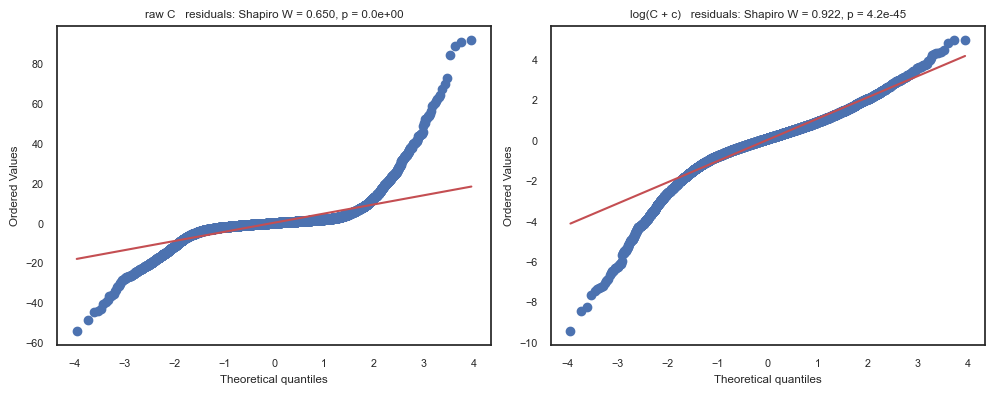

In [261]:
# RM-ANOVA assumes normal residuals after removing subject and condition means.
import scipy.stats as sps
_factors = ['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI', 'hemisphere']

def _rm_resid(df):
    y = df['Connectivity'].to_numpy(float)
    y = y - df.groupby('participant_id')['Connectivity'].transform('mean').to_numpy()
    cell = df[_factors].astype(str).agg('-'.join, axis=1).to_numpy()
    return y - pd.Series(y).groupby(cell).transform('mean').to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (frame, tag) in zip(axes,
                            [(all_long_df.dropna(subset=['Connectivity']), 'raw C'),
                             (all_log_df, 'log(C + c)')]):
    r = _rm_resid(frame)
    r = r[np.isfinite(r)]
    sps.probplot(r, plot=ax)
    _r = r if len(r) <= 5000 else np.random.default_rng(0).choice(r, 5000, replace=False)
    W, p = sps.shapiro(_r)
    ax.set_title(f'{tag}   residuals: Shapiro W = {W:.3f}, p = {p:.1e}')
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'residual_qq_raw_vs_log.svg'))


In [262]:
# omnibus ANOVAs on the log scale.  >2 within-factors -> AnovaRM; 2 -> rm_anova.
def _omnibus_log(df, within, label):
    if len(within) > 2:
        aov = AnovaRM(df, aggregate_func='mean', depvar='Connectivity',
                      subject='participant_id', within=within).fit()
        return export_anova(aov, label, STATS_OUT_DIR)
    d = df.groupby(['participant_id'] + within, as_index=False)['Connectivity'].mean()
    aov = pg.rm_anova(data=d, dv='Connectivity', within=within,
                      subject='participant_id', detailed=True, effsize='np2')
    return export_anova(aov, label, STATS_OUT_DIR)

_specs = [
    (aud_log_df, ['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI', 'hemisphere'], 'aud_full_log'),
    (aud_log_df, ['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI'],               'aud_cau_rostral_roi_log'),
    (aud_log_df, ['Cortex_ROI', 'Caudate_Putamen'],                                 'aud_roi_cau_log'),
    (aud_log_df, ['Cortex_ROI', 'Rostral_Caudal'],                                  'aud_roi_rostral_log'),
    (pfc_log_df, ['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI', 'hemisphere'], 'pfc_full_log'),
    (pfc_log_df, ['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI'],               'pfc_cau_rostral_roi_log'),
    (pfc_log_df, ['Cortex_ROI', 'Caudate_Putamen'],                                 'pfc_roi_cau_log'),
    (pfc_log_df, ['Cortex_ROI', 'Rostral_Caudal'],                                  'pfc_roi_rostral_log'),
]
for _df, _within, _lbl in _specs:
    print(f'\n=== {_lbl} ===')
    display(_omnibus_log(_df, _within, _lbl))



=== aud_full_log ===


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Caudate_Putamen,1912.53,1.0,96.0,p < .001,,,,"F(1, 96) = 1912.53, p < .001"
1,Rostral_Caudal,652.33,1.0,96.0,p < .001,,,,"F(1, 96) = 652.33, p < .001"
2,Cortex_ROI,628.41,4.0,384.0,p < .001,,,,"F(4, 384) = 628.41, p < .001"
3,hemisphere,47.04,1.0,96.0,p < .001,,,,"F(1, 96) = 47.04, p < .001"
4,Caudate_Putamen:Rostral_Caudal,261.49,1.0,96.0,p < .001,,,,"F(1, 96) = 261.49, p < .001"
5,Caudate_Putamen:Cortex_ROI,53.68,4.0,384.0,p < .001,,,,"F(4, 384) = 53.68, p < .001"
6,Rostral_Caudal:Cortex_ROI,55.92,4.0,384.0,p < .001,,,,"F(4, 384) = 55.92, p < .001"
7,Caudate_Putamen:hemisphere,4.50,1.0,96.0,p = .036,,,,"F(1, 96) = 4.50, p = .036"
8,Rostral_Caudal:hemisphere,14.72,1.0,96.0,p < .001,,,,"F(1, 96) = 14.72, p < .001"
9,Cortex_ROI:hemisphere,88.54,4.0,384.0,p < .001,,,,"F(4, 384) = 88.54, p < .001"



=== aud_cau_rostral_roi_log ===


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Caudate_Putamen,1912.53,1.0,96.0,p < .001,,,,"F(1, 96) = 1912.53, p < .001"
1,Rostral_Caudal,652.33,1.0,96.0,p < .001,,,,"F(1, 96) = 652.33, p < .001"
2,Cortex_ROI,628.41,4.0,384.0,p < .001,,,,"F(4, 384) = 628.41, p < .001"
3,Caudate_Putamen:Rostral_Caudal,261.49,1.0,96.0,p < .001,,,,"F(1, 96) = 261.49, p < .001"
4,Caudate_Putamen:Cortex_ROI,53.68,4.0,384.0,p < .001,,,,"F(4, 384) = 53.68, p < .001"
5,Rostral_Caudal:Cortex_ROI,55.92,4.0,384.0,p < .001,,,,"F(4, 384) = 55.92, p < .001"
6,Caudate_Putamen:Rostral_Caudal:Cortex_ROI,120.12,4.0,384.0,p < .001,,,,"F(4, 384) = 120.12, p < .001"



=== aud_roi_cau_log ===


...

,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Caudate_Putamen,21.76,1.0,96.0,p < .001,,,,"F(1, 96) = 21.76, p < .001"
1,Rostral_Caudal,810.03,1.0,96.0,p < .001,,,,"F(1, 96) = 810.03, p < .001"
2,Cortex_ROI,418.66,4.0,384.0,p < .001,,,,"F(4, 384) = 418.66, p < .001"
3,Caudate_Putamen:Rostral_Caudal,1.23,1.0,96.0,p = .270,,,,"F(1, 96) = 1.23, p = .270"
4,Caudate_Putamen:Cortex_ROI,379.64,4.0,384.0,p < .001,,,,"F(4, 384) = 379.64, p < .001"
5,Rostral_Caudal:Cortex_ROI,762.06,4.0,384.0,p < .001,,,,"F(4, 384) = 762.06, p < .001"
6,Caudate_Putamen:Rostral_Caudal:Cortex_ROI,162.81,4.0,384.0,p < .001,,,,"F(4, 384) = 162.81, p < .001"



=== pfc_roi_cau_log ===


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Cortex_ROI,418.66,4,384,p < .001,p < .001,0.813,0.514,"F(2.06, 197.55) = 418.66, p < .001 (GG ε=0.51)..."
1,Caudate_Putamen,21.76,1,96,p < .001,p < .001,0.185,1.000,"F(1, 96) = 21.76, p < .001, ηp² = .18"
2,Cortex_ROI * Caudate_Putamen,379.64,4,384,p < .001,p < .001,0.798,0.714,"F(2.85, 274.05) = 379.64, p < .001 (GG ε=0.71)..."



=== pfc_roi_rostral_log ===


,source,F,df_num,df_den,p,p_gg,np2,eps,stat_str
0,Cortex_ROI,418.66,4,384,p < .001,p < .001,0.813,0.514,"F(2.06, 197.55) = 418.66, p < .001 (GG ε=0.51)..."
1,Rostral_Caudal,810.03,1,96,p < .001,p < .001,0.894,1.000,"F(1, 96) = 810.03, p < .001, ηp² = .89"
2,Cortex_ROI * Rostral_Caudal,762.06,4,384,p < .001,p < .001,0.888,0.592,"F(2.37, 227.46) = 762.06, p < .001 (GG ε=0.59)..."


## Anatomical Connectivity Figure (Yeterian & Pandya 1998 Style)

Schematic figure showing auditory corticostriatal connectivity on a lateral brain view and coronal striatal cross-sections.


In [263]:
import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import PathPatch, FancyArrowPatch
from matplotlib.path import Path
import matplotlib.patches as mpatches
import nibabel as nib
from skimage import measure
import seaborn as sns

In [264]:
# Per-ROI mask files (from atlas_construction.ipynb) + an MNI brain mask.
atlas_dir = os.path.join('/Users/dsj3886/data_local/derivatives/',
                         'atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal/')
file_prefix = 'atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal'

BRAIN_MASK_PATH = os.path.join('/Users/dsj3886/data_local/reference/',
                               'mni_icbm152_nlin_asym_09c_nifti/mni_icbm152_nlin_asym_09c/',
                               'mni_icbm152_t1_tal_nlin_asym_09c_mask.nii')

AUDITORY_MASK_PATHS = {
    "HG":   os.path.join(atlas_dir, f'{file_prefix}_L-HG.nii.gz'),
    "PP":   os.path.join(atlas_dir, f'{file_prefix}_L-PP.nii.gz'),
    "PT":   os.path.join(atlas_dir, f'{file_prefix}_L-PT.nii.gz'),
    "STGa": os.path.join(atlas_dir, f'{file_prefix}_L-STGa.nii.gz'),
    "STGp": os.path.join(atlas_dir, f'{file_prefix}_L-STGp.nii.gz'),
}

PREFRONTAL_MASK_PATHS = {
    "OFC":   os.path.join(atlas_dir, f'{file_prefix}_L-OFC.nii.gz'),
    "ACC":   os.path.join(atlas_dir, f'{file_prefix}_L-ACC.nii.gz'),
    "FMC":   os.path.join(atlas_dir, f'{file_prefix}_L-FMC.nii.gz'),
    "MFG":   os.path.join(atlas_dir, f'{file_prefix}_L-MFG.nii.gz'),
    "IFGt":  os.path.join(atlas_dir, f'{file_prefix}_L-IFGt.nii.gz'),
    "IFGo":  os.path.join(atlas_dir, f'{file_prefix}_L-IFGo.nii.gz'),
    "PreCG": os.path.join(atlas_dir, f'{file_prefix}_L-PreCG.nii.gz'),
}

STRIATAL_MASK_PATHS = {
    "aPUT": os.path.join(atlas_dir, f'{file_prefix}_aPUT-lh.nii.gz'),
    "pPUT": os.path.join(atlas_dir, f'{file_prefix}_pPUT-lh.nii.gz'),
    "aCAU": os.path.join(atlas_dir, f'{file_prefix}_aCAU-lh.nii.gz'),
    "pCAU": os.path.join(atlas_dir, f'{file_prefix}_pCAU-lh.nii.gz'),
}


In [265]:
def get_roi_contour(mask_path, axis=1, slice_idx=None):
    """
    Load a binary NIfTI mask and return the largest 2D contour from a slice.

    axis=0 -> sagittal slice
    axis=1 -> coronal slice
    slice_idx: if None, use the slice with the largest cross-sectional area.
    """
    data = nib.load(mask_path).get_fdata()
    if slice_idx is None:
        areas = [np.take(data, i, axis=axis).sum() for i in range(data.shape[axis])]
        slice_idx = int(np.argmax(areas))
    slice_2d = np.take(data, slice_idx, axis=axis)
    contours = measure.find_contours(slice_2d, level=0.5)
    return max(contours, key=len)


def get_best_slice_idx(mask_path, axis):
    """Return the slice index with the largest mask area along the given axis."""
    data = nib.load(mask_path).get_fdata()
    areas = [np.take(data, i, axis=axis).sum() for i in range(data.shape[axis])]
    return int(np.argmax(areas))


In [266]:

CORTEX_ROI      = 'HG'   # highlighted in the brain panel

all_conn = (
    all_long_df[all_long_df['Cortex_ROI'].isin(CORTEX_ROIS)]
    .groupby(['Cortex_ROI', 'Striatum_ROI'])['Connectivity']
    .mean()
    .reset_index()
    .rename(columns={'Connectivity': 'conn_mean'})
)
print(all_conn)


    Cortex_ROI Striatum_ROI  conn_mean
0          ACC         aCAU   3.915414
1          ACC         aPUT   0.187005
2          ACC         pCAU   0.347791
3          ACC         pPUT   0.103459
4          FMC         aCAU   1.880181
5          FMC         aPUT   1.499395
6          FMC         pCAU   0.068034
7          FMC         pPUT   0.058906
8           HG         aCAU   0.042695
9           HG         aPUT   0.631183
10          HG         pCAU   0.113281
11          HG         pPUT  14.472291
12        IFGo         aCAU   1.777613
13        IFGo         aPUT   1.072659
14        IFGo         pCAU  13.601685
15        IFGo         pPUT   3.627177
16        IFGt         aCAU   3.929368
17        IFGt         aPUT   4.594265
18        IFGt         pCAU   4.520315
19        IFGt         pPUT   1.334575
20   IntraCalc         aCAU   0.105736
21   IntraCalc         aPUT   1.584616
22   IntraCalc         pCAU   0.089310
23   IntraCalc         pPUT   1.814245
24      LOCinf         aC

In [267]:
from matplotlib.colors import Normalize as MplNorm, LogNorm, to_rgb
from matplotlib.cm import ScalarMappable

CMAP = plt.cm.YlOrRd

AUDITORY_PALETTE = {
    'HG':   CMAP(0.85),
    'PP':   '#5aafe0',
    'PT':   '#78c679',
    'STGa': '#9970ab',
    'STGp': '#d9a63a',
}

PREFRONTAL_PALETTE = {
    'OFC':   '#e8a838',
    'ACC':   '#d46b6b',
    'FMC':   '#8e5fbf',
    'MFG':   '#4d9de0',
    'IFGt':  '#3bb273',
    'IFGo':  '#e84855',
    'PreCG': '#7f8c8d',
}

# Paint order: last = highest priority (drawn on top).
# Auditory (temporal plane) are given priority over prefrontal.
PAINT_ORDER = ['PreCG', 'IFGo', 'IFGt', 'MFG', 'FMC', 'ACC', 'OFC',
               'STGp', 'STGa', 'PT', 'PP', 'HG']

# Z-shear applied before Y-Z projection.
# Positive value: each voxel at X=x is shifted +x*SHEAR_FACTOR in Z.
# This tilts the projection to look from slightly below, separating the
# superior temporal plane (HG/PP/PT, deeper/more medial) from the lateral
# surface (STGa/STGp, more lateral).
SHEAR_FACTOR = 0.3


def _sheared_footprint(mask_3d, shear_factor, out_nz):
    """Y-Z footprint with Z-shear. Returns bool array (ny, out_nz)."""
    nx, ny, nz = mask_3d.shape
    result = np.zeros((ny, out_nz), dtype=bool)
    for x in range(nx):
        z_shift = int(round(x * shear_factor))
        sl = mask_3d[x] > 0          # (ny, nz)
        src_end = min(nz, out_nz - z_shift)
        dst_start = z_shift
        if src_end > 0 and dst_start < out_nz:
            result[:, dst_start:dst_start + src_end] |= sl[:, :src_end]
    return result


def _make_surface_rgba(brain_mask_path, roi_mask_paths, palette):
    """
    Sheared Y-Z footprint per ROI painted in PAINT_ORDER.
    Returns (rgba (nz_out,ny,4), brain_proj (ny,nz_out), roi_label (ny,nz_out), roi_list).
    """
    brain_data = nib.load(brain_mask_path).get_fdata() > 0
    nx, ny, nz = brain_data.shape
    nz_out = nz + int(nx * SHEAR_FACTOR) + 2   # extra Z room after shearing

    brain_proj = _sheared_footprint(brain_data, SHEAR_FACTOR, nz_out)

    footprints = {
        roi: _sheared_footprint(nib.load(path).get_fdata(), SHEAR_FACTOR, nz_out)
        for roi, path in roi_mask_paths.items()
    }

    rgba = np.zeros((nz_out, ny, 4), dtype=float)
    in_brain = brain_proj.T
    rgba[in_brain, :3] = 0.85
    rgba[in_brain,  3] = 1.0

    roi_list  = list(roi_mask_paths.keys())
    roi_label = np.zeros((ny, nz_out), dtype=int)

    for roi in PAINT_ORDER:
        if roi not in footprints:
            continue
        fp   = footprints[roi]
        mask = fp.T
        rgba[mask, :3] = to_rgb(palette.get(roi, '#888888'))
        rgba[mask,  3] = 1.0
        roi_label[fp] = roi_list.index(roi) + 1

    rgba[~in_brain, 3] = 0.0
    return rgba, brain_proj, roi_label, roi_list, footprints


def draw_brain_panel(ax, brain_mask_path, cortex_mask_paths, striatal_mask_paths):
    combined_palette = {**AUDITORY_PALETTE, **PREFRONTAL_PALETTE}
    rgba, brain_proj, roi_label, roi_list, footprints = _make_surface_rgba(
        brain_mask_path, cortex_mask_paths, combined_palette)

    ny, nz_out = brain_proj.shape
    ax.imshow(rgba, origin='lower', extent=[0, ny, 0, nz_out],
              aspect='equal', interpolation='nearest')

    # Brain silhouette
    brain_contour = max(measure.find_contours(brain_proj.astype(float), level=0.5), key=len)
    ax.plot(brain_contour[:, 0], brain_contour[:, 1], color='black', linewidth=1.5, zorder=4)

    # ROI boundary contours
    for roi, fp in footprints.items():
        contours = measure.find_contours(fp.astype(float), level=0.5)
        for c in contours:
            ax.plot(c[:, 0], c[:, 1], color='black', linewidth=0.6, zorder=5)

    # Labels at painted centroid
    for idx, roi in enumerate(roi_list, start=1):
        ys, zs = np.where(roi_label == idx)
        if len(ys) == 0:
            continue
        is_active = (roi == CORTEX_ROI)
        ax.text(ys.mean(), zs.mean(), _display_label(roi),
                ha='center', va='center', fontsize=7, zorder=6,
                fontweight='bold' if is_active else 'normal',
                color='white' if is_active else 'black')

    # Crop to brain bounding box
    ys, zs = np.where(brain_proj)
    margin = 4
    ax.set_xlim(ys.min() - margin, ys.max() + margin)
    ax.set_ylim(zs.min() - margin, zs.max() + margin)
    ax.set_aspect('equal')
    ax.invert_xaxis()

    ax.axis('off')


def draw_striatal_structure(ax, roi_ant, roi_post, hg_conn_df, striatal_mask_paths, norm, title=None):
    data_ant  = nib.load(striatal_mask_paths[roi_ant]).get_fdata()
    data_post = nib.load(striatal_mask_paths[roi_post]).get_fdata()
    slice_idx = int(np.argmax((data_ant + data_post).sum(axis=(1, 2))))

    for roi, data in [(roi_ant, data_ant), (roi_post, data_post)]:
        row      = hg_conn_df[hg_conn_df["Striatum_ROI"] == roi]
        conn_val = float(row["conn_mean"].values[0]) if not row.empty else 0
        contours = measure.find_contours(data[slice_idx, :, :], level=0.5)
        if not contours:
            continue
        contour = max(contours, key=len)
        verts = np.column_stack([contour[:, 0], contour[:, 1]])
        codes  = [Path.MOVETO] + [Path.LINETO] * (len(verts) - 2) + [Path.CLOSEPOLY]
        ax.add_patch(PathPatch(Path(verts, codes),
                               facecolor=CMAP(norm(conn_val)),
                               edgecolor='black', linewidth=1.5))
        label = 'ant' if roi == roi_ant else 'post'
        ax.text(np.mean(contour[:, 0]), np.mean(contour[:, 1]), label,
                ha='center', va='center', fontsize=6, color='black', alpha=0.7)

    if title:
        ax.set_title(title, fontsize=10)
    ax.set_aspect('equal')
    ax.autoscale()
    # Tighten limits to the data so no internal whitespace inflates the gap
    margin = 3
    ax.set_xlim(ax.get_xlim()[0] - margin, ax.get_xlim()[1] + margin)
    ax.set_ylim(ax.get_ylim()[0] - margin, ax.get_ylim()[1] + margin)
    ax.invert_xaxis()
    ax.axis('off')


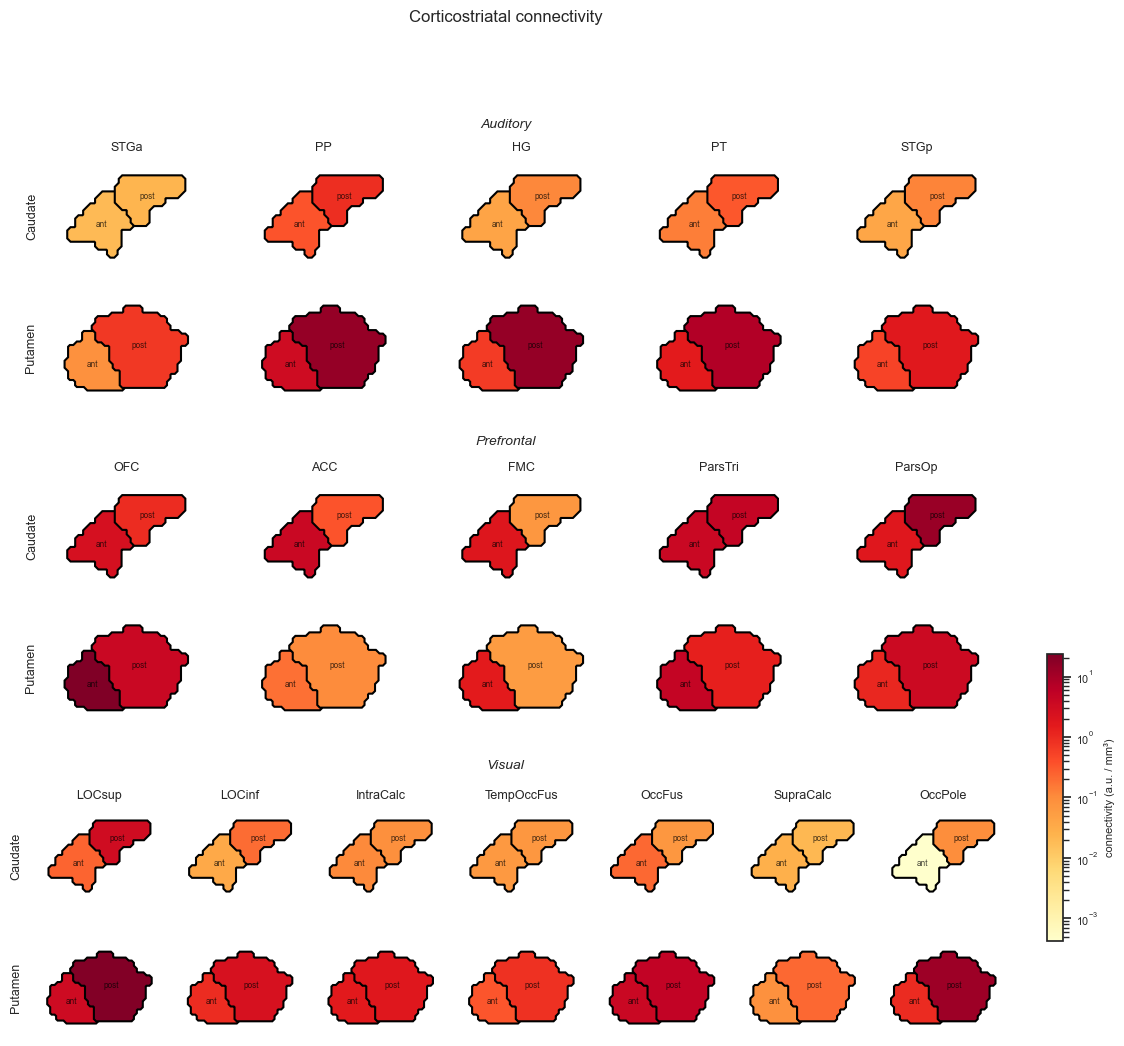

In [268]:
# -- Build figure: auditory + prefrontal + visual striatal panels ------------
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable

vmax     = float(all_conn['conn_mean'].max())
vmin_log = float(all_conn.loc[all_conn['conn_mean'] > 0, 'conn_mean'].min())
norm     = LogNorm(vmin=vmin_log, vmax=vmax)

col_w = 1.8
fig_w = col_w * max(len(AUDITORY_ROIS), len(PREFRONTAL_ROIS), len(VISUAL_ROIS))
fig   = plt.figure(figsize=(fig_w, 11.5))

# Outer grid: auditory (cau+put) | prefrontal (cau+put) | visual (cau+put)
gs_outer = gridspec.GridSpec(3, 1, height_ratios=[1.8, 1.8, 1.8], hspace=0.3)

# ── Auditory section ─────────────────────────────────────────────────────────
gs_aud = gridspec.GridSpecFromSubplotSpec(
    2, len(AUDITORY_ROIS), subplot_spec=gs_outer[0], wspace=0.06, hspace=0.15)

ax_cau_aud_first = ax_put_aud_first = None
aud_cau_axes = []
for col, roi in enumerate(AUDITORY_ROIS):
    conn_df = all_conn[all_conn['Cortex_ROI'] == roi]
    ax_cau = fig.add_subplot(gs_aud[0, col])
    ax_put = fig.add_subplot(gs_aud[1, col])
    if col == 0:
        ax_cau_aud_first = ax_cau
        ax_put_aud_first = ax_put
    draw_striatal_structure(ax_cau, 'aCAU', 'pCAU', conn_df, STRIATAL_MASK_PATHS, norm)
    draw_striatal_structure(ax_put, 'aPUT', 'pPUT', conn_df, STRIATAL_MASK_PATHS, norm)
    ax_cau.set_title(roi, fontsize=9)
    aud_cau_axes.append(ax_cau)

ax_cau_aud_first.annotate('Caudate', xy=(0, 0.5), xycoords='axes fraction',
                           xytext=(-8, 0), textcoords='offset points',
                           ha='right', va='center', fontsize=9, rotation=90)
ax_put_aud_first.annotate('Putamen', xy=(0, 0.5), xycoords='axes fraction',
                           xytext=(-8, 0), textcoords='offset points',
                           ha='right', va='center', fontsize=9, rotation=90)

# ── Prefrontal section ───────────────────────────────────────────────────────
gs_pfc = gridspec.GridSpecFromSubplotSpec(
    2, len(PREFRONTAL_ROIS), subplot_spec=gs_outer[1], wspace=0.06, hspace=0.15)

ax_cau_pfc_first = ax_put_pfc_first = None
for col, roi in enumerate(PREFRONTAL_ROIS):
    conn_df = all_conn[all_conn['Cortex_ROI'] == roi]
    ax_cau = fig.add_subplot(gs_pfc[0, col])
    ax_put = fig.add_subplot(gs_pfc[1, col])
    if col == 0:
        ax_cau_pfc_first = ax_cau
        ax_put_pfc_first = ax_put
    draw_striatal_structure(ax_cau, 'aCAU', 'pCAU', conn_df, STRIATAL_MASK_PATHS, norm)
    draw_striatal_structure(ax_put, 'aPUT', 'pPUT', conn_df, STRIATAL_MASK_PATHS, norm)
    ax_cau.set_title(_display_label(roi), fontsize=9)

ax_cau_pfc_first.annotate('Caudate', xy=(0, 0.5), xycoords='axes fraction',
                            xytext=(-8, 0), textcoords='offset points',
                            ha='right', va='center', fontsize=9, rotation=90)
ax_put_pfc_first.annotate('Putamen', xy=(0, 0.5), xycoords='axes fraction',
                            xytext=(-8, 0), textcoords='offset points',
                            ha='right', va='center', fontsize=9, rotation=90)

# ── Visual section ───────────────────────────────────────────────────────────
gs_vis = gridspec.GridSpecFromSubplotSpec(
    2, len(VISUAL_ROIS), subplot_spec=gs_outer[2], wspace=0.06, hspace=0.15)

ax_cau_vis_first = ax_put_vis_first = None
for col, roi in enumerate(VISUAL_ROIS):
    conn_df = all_conn[all_conn['Cortex_ROI'] == roi]
    ax_cau = fig.add_subplot(gs_vis[0, col])
    ax_put = fig.add_subplot(gs_vis[1, col])
    if col == 0:
        ax_cau_vis_first = ax_cau
        ax_put_vis_first = ax_put
    draw_striatal_structure(ax_cau, 'aCAU', 'pCAU', conn_df, STRIATAL_MASK_PATHS, norm)
    draw_striatal_structure(ax_put, 'aPUT', 'pPUT', conn_df, STRIATAL_MASK_PATHS, norm)
    ax_cau.set_title(_display_label(roi), fontsize=9)

ax_cau_vis_first.annotate('Caudate', xy=(0, 0.5), xycoords='axes fraction',
                            xytext=(-8, 0), textcoords='offset points',
                            ha='right', va='center', fontsize=9, rotation=90)
ax_put_vis_first.annotate('Putamen', xy=(0, 0.5), xycoords='axes fraction',
                            xytext=(-8, 0), textcoords='offset points',
                            ha='right', va='center', fontsize=9, rotation=90)

# ── Section labels ────────────────────────────────────────────────────────────
fig.canvas.draw()
# Section label sits above the row of column titles (e.g. HG for auditory),
# not just above the bare axes -- measure the titles' actual rendered top
# (they vary with fontsize/dpi) rather than guessing a fixed fig-fraction pad,
# which previously undershot and let 'Auditory' overlap whichever ROI landed
# in the middle column.
renderer = fig.canvas.get_renderer()
aud_title_top = max(
    ax.title.get_window_extent(renderer).transformed(fig.transFigure.inverted()).y1
    for ax in aud_cau_axes
)
aud_label_y = aud_title_top + 0.01
pfc_label_y = (ax_cau_pfc_first.get_position().y1 + ax_put_aud_first.get_position().y0) / 2
vis_label_y = (ax_cau_vis_first.get_position().y1 + ax_put_pfc_first.get_position().y0) / 2
fig.text(0.5, aud_label_y, 'Auditory',   ha='center', va='bottom', fontsize=10, style='italic')
fig.text(0.5, pfc_label_y, 'Prefrontal', ha='center', va='center', fontsize=10, style='italic')
fig.text(0.5, vis_label_y, 'Visual',     ha='center', va='center', fontsize=10, style='italic')

# ── Shared colorbar ──────────────────────────────────────────────────────────
sm = ScalarMappable(cmap=CMAP, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.93, 0.2, 0.012, 0.25])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('connectivity (a.u. / mm³)', fontsize=8)

fig.suptitle('Corticostriatal connectivity', fontsize=12, y=1.01)

fig.savefig(os.path.join(FIGURES_DIR, 'corticostriatal_connectivity_schematic.pdf'), bbox_inches='tight', dpi=300)
fig.savefig(os.path.join(FIGURES_DIR, 'corticostriatal_connectivity_schematic.png'), bbox_inches='tight', dpi=300)
fig.savefig(os.path.join(FIGURES_DIR, 'corticostriatal_connectivity_schematic.svg'), bbox_inches='tight', dpi=300)
plt.show()


### Surface ROI visualisation (Destrieux approximation)

Renders the auditory / prefrontal ROIs on an fsaverage surface for figure panels. Uses approximate Destrieux labels, independent of the connectivity analysis.

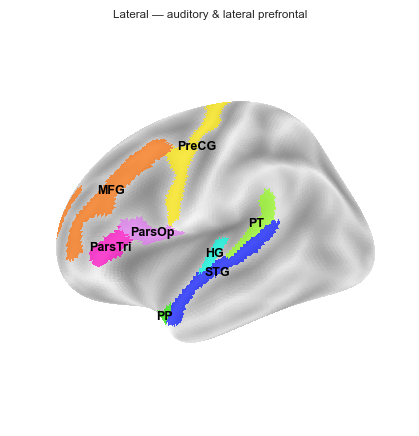

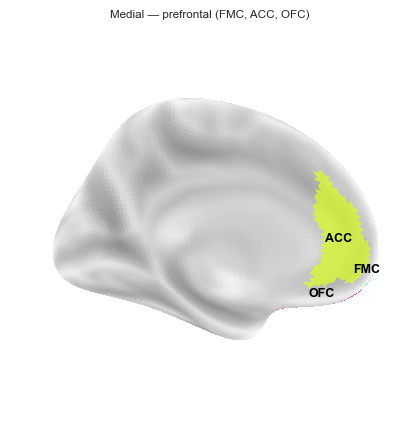

In [269]:
from nilearn import datasets, plotting, surface
import numpy as np

destrieux = datasets.fetch_atlas_surf_destrieux()
fsaverage = datasets.fetch_surf_fsaverage('fsaverage5')

labels = [l.decode() if isinstance(l, bytes) else l for l in destrieux['labels']]
parc   = destrieux['map_left']
coords, _ = surface.load_surf_mesh(fsaverage['infl_left'])

# ROI → Destrieux label
auditory_destrieux = {
    'STG':  'G_temp_sup-Lateral',
    'HG':   'G_temp_sup-G_T_transv',
    'PP':   'G_temp_sup-Plan_polar',
    'PT':   'G_temp_sup-Plan_tempo',
}
lateral_pfc_destrieux = {
    'PreCG': 'G_precentral',
    'MFG':   'G_front_middle',
    'IFGt':  'G_front_inf-Triangul',
    'IFGo':  'G_front_inf-Opercular',
}
medial_pfc_destrieux = {
    'FMC': 'G_and_S_frontomargin',
    'ACC': 'G_and_S_cingul-Ant',
    'OFC': 'G_orbital',
}


def make_roi_map(roi_dict):
    roi_map = np.zeros(len(parc))
    for roi_id, label in enumerate(roi_dict.values(), start=1):
        idx = labels.index(label)
        roi_map[parc == idx] = roi_id
    return roi_map


def add_labels(ax, roi_map, roi_dict):
    for roi_id, name in enumerate(roi_dict.keys(), start=1):
        verts = np.where(roi_map == roi_id)[0]
        if len(verts) == 0:
            continue
        cx, cy, cz = coords[verts].mean(axis=0)
        ax.text(cx, cy, cz, _display_label(name), fontsize=9, fontweight='bold',
                ha='center', va='center', color='black',
                bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.))


# ── Lateral view: auditory + lateral prefrontal ───────────────────────────────
lateral_rois    = {**auditory_destrieux, **lateral_pfc_destrieux}
roi_map_lateral = make_roi_map(lateral_rois)

fig_lat = plotting.plot_surf_roi(
    fsaverage['infl_left'],
    roi_map=roi_map_lateral,
    bg_map=fsaverage['sulc_left'],
    bg_on_data=True,
    darkness=0.5,
    view='lateral',
    title='Lateral — auditory & lateral prefrontal',
)
add_labels(fig_lat.axes[0], roi_map_lateral, lateral_rois)

# ── Medial view: medial/orbital prefrontal ────────────────────────────────────
roi_map_medial = make_roi_map(medial_pfc_destrieux)

fig_med = plotting.plot_surf_roi(
    fsaverage['infl_left'],
    roi_map=roi_map_medial,
    bg_map=fsaverage['sulc_left'],
    bg_on_data=True,
    darkness=0.5,
    view='medial',
    title='Medial — prefrontal (FMC, ACC, OFC)',
)
add_labels(fig_med.axes[0], roi_map_medial, medial_pfc_destrieux)


In [270]:
import os 
atlas_fpath = os.path.join('/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal/',
                           'atlas-custom_subcort-tianS2_cort-aud-vis-prefrontal_atlas_space-MNI152NLin6Asym.nii.gz')

In [271]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from nilearn.plotting import view_img_on_surf
import nibabel as nib

# Keep subcortical (1-8), auditory (9-18), selected prefrontal, and visual
# (41-54, kept in full -- unlike prefrontal there's no curated subset).
# Zero out only the excluded (non-kept) prefrontal-adjacent ROIs (19-40).
pfc_to_keep = {'L-' + r for r in PREFRONTAL_ROIS} | {'R-' + r for r in PREFRONTAL_ROIS}

atlas_img  = nib.load(atlas_fpath)
atlas_data = atlas_img.get_fdata().copy()
for label_idx, label_name in enumerate(region_list, start=1):
    if (19 <= label_idx <= 40 and label_name not in pfc_to_keep) or label_name.startswith('R-'):
        atlas_data[atlas_data == label_idx] = 0

# Remap surviving labels to a dense 1..k range -- raw label indices (up to 37)
# leave ~9 unused gaps from zeroed-out regions, so the hue wheel below was
# being split into more slices than there are visible regions, packing real
# colors closer together than necessary.
present = sorted(int(v) for v in np.unique(atlas_data) if v > 0)
remap = {old: new for new, old in enumerate(present, start=1)}
remapped = np.zeros_like(atlas_data)
for old_idx, new_idx in remap.items():
    remapped[atlas_data == old_idx] = new_idx
atlas_data = remapped

masked_img = nib.Nifti1Image(atlas_data.astype(np.float32), atlas_img.affine, atlas_img.header)
n_labels = len(present)

# Evenly-spaced hues (HUSL) at fixed saturation/lightness -- guarantees a
# minimum hue separation between all n_labels colors (no near-duplicate
# "browns") and stays off white/black by construction (unlike randomly
# sampling from tab20/tab20b/tab20c, which include pale and near-duplicate
# earth-tone entries). husl assigns hues in index order, so labels that are
# close together in the LUT (e.g. HG-PP-PT-STGa-STGp = 9-13, or ACC/OFC =
# 35/37) get near-adjacent hues and read as one blob even though they're
# spatially adjacent, distinct regions -- shuffle the hue assignment (fixed
# seed) so index-neighbors don't get color-neighbors.
# Hue-shuffling alone can't raise the *minimum* pairwise hue distance -- with
# n_labels evenly-spaced hues, some pair is always exactly one hue-step apart
# no matter how they're assigned (all slots are used). Alternate lightness by
# hue-slot position so whichever two labels land on adjacent hues (unavoidable)
# still differ visibly in brightness, independent of shuffle luck.
_hues_dark  = sns.husl_palette(n_labels, l=0.45)
_hues_light = sns.husl_palette(n_labels, l=0.72)
_hues = [(_hues_dark if i % 2 == 0 else _hues_light)[i] for i in range(n_labels)]
_perm = np.random.default_rng(0).permutation(n_labels)
cmap_rois = ListedColormap([_hues[i] for i in _perm])

view = view_img_on_surf(
    stat_map_img=masked_img,
    surf_mesh="fsaverage",
    threshold=0.5,
    cmap=cmap_rois,
    vmin=1,
    vmax=n_labels,
    vol_to_surf_kwargs={
        "n_samples": 1,
        "radius": 3,
        "interpolation": "nearest",
    },
    symmetric_cmap=False,
    colorbar=False,
)

#view  # interactive; save manually, then clear this output (keeps the notebook small)


In [272]:
# Static, savable re-render of the interactive view above, sampling the SAME
# volumetric atlas. Uses inner_mesh (white matter surface) rather than a
# radius-ball, so each vertex's sample stays within the local cortical ribbon
# instead of jumping across sulcal folds into an unrelated gyrus (visible
# earlier as speckled/interdigitated regions, worst medially). n_samples=1
# keeps it a single nearest-voxel lookup per vertex -- averaging across depth
# samples would be meaningless for discrete integer labels.
texture = surface.vol_to_surf(
    masked_img, fsaverage['pial_left'],
    inner_mesh=fsaverage['white_left'],
    interpolation='nearest',
    n_samples=1,
)

_views = ['lateral', 'medial', 'dorsal', 'ventral', 'anterior', 'posterior']
for _view in _views:
    _fig = plotting.plot_surf_roi(
        fsaverage['infl_left'], roi_map=texture, hemi='left', view=_view,
        bg_map=fsaverage['sulc_left'], bg_on_data=True, darkness=0.5,
        cmap=cmap_rois, vmin=1, vmax=n_labels,
        title=f'Atlas ROIs -- {_view}',
    )
    _fig.savefig(os.path.join(FIGURES_DIR, f'atlas_surface_{_view}.png'), dpi=300, bbox_inches='tight')
    plt.close(_fig)

print(f'saved {len(_views)} static views to {FIGURES_DIR}/atlas_surface_*.png')


saved 6 static views to figures/gpexcl_visual/atlas_surface_*.png


In [273]:
import numpy as np
vals, counts = np.unique(texture, return_counts=True)
for v, n in zip(vals, counts):
    if v > 0:
        print(f'label {int(v):3d}  {region_list[int(v)-1]:8s}  {n} vertices  color={cmap_rois(int(v)/n_labels)}')


label   9  L-HG      55 vertices  color=(0.7232445017204864, 0.14999882996889147, 0.6318497798172309, 1.0)
label  10  L-PP      90 vertices  color=(0.9138171383190781, 0.6256002711629646, 0.22235869374705125, 1.0)
label  11  L-PT      140 vertices  color=(0.9440431755046993, 0.5285204789844931, 0.9663732024289832, 1.0)
label  12  L-STGa    33 vertices  color=(0.25713410683562743, 0.4632002640005161, 0.11884351488525202, 1.0)
label  13  L-STGp    70 vertices  color=(0.7925648500206579, 0.1288722247835051, 0.31179736442471523, 1.0)
label  14  R-HG      84 vertices  color=(0.6451511683448472, 0.1682080344890105, 0.8158050448512733, 1.0)
label  15  R-PP      89 vertices  color=(0.13024480682276351, 0.46087837955901906, 0.41762446999823205, 1.0)
label  16  R-PT      47 vertices  color=(0.2033620903719069, 0.3561845689961419, 0.924647862382664, 1.0)
label  17  R-STGa    228 vertices  color=(0.2411587305295489, 0.7543496856334013, 0.7464369457465808, 1.0)
label  18  R-STGp    249 vertices  co